In [ ]:
# Uninstall the ccogitarelink package
#! pip uninstall cogitarelink -y

In [ ]:
## Install fresh from the GitHub Package
#! pip install --no-cache-dir -U git+https://github.com/la3d/cogitarelink.git

In [ ]:
#| default_exp memory
#| export
import json
from pyld import jsonld
import httpx
from rdflib import Graph, Dataset, URIRef, Literal, Namespace
from rdflib.namespace import RDF, RDFS, OWL
from datetime import datetime
from enum import Enum
from typing import List, Literal, Optional, Dict, Any
from pydantic import BaseModel, Field
from fastcore.basics import patch
from dataclasses import dataclass, field
from claudette import Chat, toolloop, models
import time
import copy
from pathlib import Path
import types
import pickle
from contextlib import contextmanager

In [ ]:
from cogitarelink.memory import *
from cogitarelink.retriever import *
# from cogitarelink.memorytools import *
# from cogitarelink.vocabtools import *
from cogitarelink.utils import *
from cogitarelink.vocabtools import *

## Load Cogitarelink source code

In [ ]:
memory_py = load_module_source("memory")

Loaded memory from /app/data/.local/lib/python3.11/site-packages/cogitarelink/memory.py (47084 characters)


In [ ]:
retriever_py = load_module_source("retriever")

Loaded retriever from /app/data/.local/lib/python3.11/site-packages/cogitarelink/retriever.py (53647 characters)


In [ ]:
vocabtools_py = load_module_source("vocabtools")

Loaded vocabtools from /app/data/.local/lib/python3.11/site-packages/cogitarelink/vocabtools.py (47029 characters)


**AI Prompt**

Hi solveit! I am Chuck, and I am working with you today! I'm an experienced Python coder, experienced with semantic web technologies like OWL,RDF and SPARQL, and I enjoy learning new things. When writing code for me, please follow fast.ai coding style: avoid comments; place single line if/loop/etc constructs on the same line; use concise variable names where appropriate. Follow the style you will see in my messages, as we work on this dialogue together. I am the author of the cogitarelink package and that allows LLM agents use JSON-LD 1.1 as a semantic memory system and to retrieve Linked Open Data and organize that LOD in LLM context windows.

**AI Response**

Hi Chuck! Great to meet you. I'm excited to work with you on cogitarelink. I see you've loaded the core modules from your package, which uses JSON-LD 1.1 for semantic memory and LOD retrieval.

What aspect of cogitarelink would you like to explore or improve today? I notice you're using Pydantic models, RDFlib, and pyld for working with JSON-LD. I'm curious about how you're structuring the memory system or if there's a specific feature you'd like to focus on.

Would you like to walk through a particular component of the system, test a feature, or perhaps develop something new?

## Design Principles

### Core Philosophy

The `SemanticMemory` module is designed to provide a semantically rich, self-organizing knowledge store that leverages the full power of JSON-LD 1.1 for intelligent data representation and LLM integration. It follows these key principles:

### Knowledge as a Connected Graph

- **Everything is a Graph**: All knowledge is stored in a connected graph structure, making relationships first-class citizens
- **Named Graphs for Provenance**: Information sources are tracked through named graphs, enabling trust and attribution
- **Cross-Graph Navigation**: Knowledge can be traversed across graph boundaries while maintaining context

### Vocabulary-Aware Processing

- **Automatic Vocabulary Detection**: The system recognizes and adapts to different vocabularies automatically
- **Vocabulary Harmonization**: Conflicting vocabularies are handled gracefully through intelligent strategies
- **Context Preservation**: Original context information is preserved to maintain semantic precision

### LLM Context Integration

- **Context Window Optimization**: Knowledge is formatted to maximize information density in LLM context windows
- **Tool-Based Navigation**: LLMs can use tools to navigate, query, and manipulate the semantic graph
- **Progressive Loading**: Complex knowledge structures can be loaded incrementally as needed
- **Adaptive Serialization**: JSON-LD is serialized based on LLM needs and context window constraints

### Containers for Intelligent Organization

- **Strategic Information Grouping**: JSON-LD 1.1 containers enable natural organization of related entities
- **Multi-dimensional Access**: Data can be accessed by ID, type, language, or custom indices
- **Efficient Pattern Matching**: Container structures facilitate efficient matching of complex patterns

### LLM-Optimized Knowledge Representation

- **Semantic Compression**: Complex structures are compressed while preserving semantic meaning
- **Vocabulary-Aware Formatting**: Data is presented using the most appropriate vocabulary for the task
- **Relationship Highlighting**: Critical relationships are made explicit for LLM reasoning
- **Context-Sensitive Views**: Different views of the same knowledge can be generated based on task needs

### Agent-LLM Collaboration

- **Follow-Your-Nose Navigation**: LLMs can explore the knowledge graph step by step via tool calls
- **In-Context Reasoning**: Semantic structures enable in-context reasoning about complex relationships
- **Tool-Augmented Retrieval**: LLMs can use tools to retrieve and manipulate semantic data
- **Memory Persistence**: Knowledge can flow between context windows through semantic memory

By adhering to these principles, the `SemanticMemory` module serves as an intelligent bridge between raw data and LLM reasoning, enabling efficient knowledge transfer to and from LLM context windows while preserving semantic richness and enabling sophisticated knowledge navigation through tool use.

## Refactoring
## Core Structure Changes

1. **Indices Structure**:
   - Original: Uses basic indices (`by_id`, `by_type`, `by_label`, `by_keyword`)
   - New: Adds `by_graph`, `by_vocabulary`, and `containers` indices
   - Impact: Methods referencing these indices directly need to be updated

2. **Context Registry**:
   - Original: Simple context tracking
   - New: Enhanced with vocabulary detection and preloading
   - Impact: Context-related methods need updates

### Modified Methods That Need Refactoring

1. **`_process_entity`**:
   - Needs to track vocabulary and graph information
   - Should be updated to integrate with new index structure

2. **`_process_graph`**:
   - Should handle named graph detection
   - Needs to pass graph information to processing entities

3. **`_update_indices`**:
   - Needs to include vocabulary and graph information
   - Should maintain compatibility with new index structure

4. **`search`** and **`query_by_type`**:
   - Should support searching across specific graphs
   - Need to leverage vocabulary information for better results

### Potentially Incompatible Functions

1. **`get_connected_entities`**:
   - Doesn't handle cross-graph relationships
   - Might not account for vocabulary-specific relationship patterns

2. **`prepare_for_llm`**:
   - Doesn't leverage vocabulary information for formatting
   - Doesn't include graph information in output

3. **`retrieve_in_context`**:
   - Might have issues with entities in different graphs
   - Could need updates to handle vocabulary-specific context

4. **`_index_labels_and_descriptions`**:
   - Doesn't account for vocabulary-specific label/description properties
   - Might need enhancement to work with named graphs

### Minimal Required Updates

At minimum, you'll need to:

1. Update `__init__` to include the new indices
2. Modify `add` to support vocabulary detection and named graphs
3. Update `_process_entity` and `_process_graph` to work with the new structure
4. Ensure query methods (`query_by_id`, `search`, etc.) are compatible with the new indices
5. Add new methods for vocabulary and graph management

In [ ]:
import dspy # Add dspy import

# Configure DSPy LM for this notebook's context
try:
    # Use the same model as in 01_retriever.ipynb
    lm = dspy.LM('anthropic/claude-3-5-sonnet-20241022')
    dspy.configure(lm=lm)
    print("DSPy configured successfully.")
except Exception as e:
    print(f"Error configuring DSPy: {e}")
    # Optionally raise the error or handle it if configuration is critical
    # raise e

DSPy configured successfully.


**AI Prompt**

Ok we are working on refactoring $`memory_py` which uses the $`vocabtools_py` for vocabulary management. Have a look through the code so you understand what we are working on.

**AI Response**

I've reviewed the code for both `memory_py` and `vocabtools_py`. Here's what I understand about the system:

The `SemanticMemory` class is designed to store and manage semantic data using JSON-LD, with several key components:

1. **Core Storage**:
   - Uses RDFlib's `Dataset` for storing triples with named graphs
   - Maintains multiple indices for efficient retrieval by ID, type, label, keyword, graph, and vocabulary
   - Preserves original data alongside expanded/processed versions

2. **Vocabulary Management**:
   - Integrates with `vocabtools_py` for vocabulary detection and handling
   - Can preload vocabularies to avoid HTTP requests during processing
   - Tracks which vocabularies are used by which entities

3. **Processing Pipeline**:
   - Normalizes entities (e.g., converting `id` to `@id`)
   - Registers contexts and processes scoped contexts
   - Expands JSON-LD data and updates indices
   - Handles graph partitioning for complex documents

4. **Query Capabilities**:
   - Retrieves entities by ID, type, or text search
   - Supports traversing connected entities
   - Can retrieve entities in their original context

5. **LLM Integration**:
   - Methods to format entities for LLM consumption
   - Extracts explicit relationships for easier comprehension
   - Compact entities using appropriate vocabularies

6. **Container Support**:
   - Creates and manages JSON-LD 1.1 containers
   - Supports organizing data by ID, type, language, etc.

Would you like me to focus on a specific aspect of this system for refactoring, or would you like a general assessment of areas that need improvement?

**AI Prompt**

What is the refactoring plan based on the notes in your context, and can you survey the code to see what state we're at?

**AI Response**

Based on the notes in the context, the refactoring plan focuses on several key areas:

1. **Ensuring Consistent Design**:
   - Standardize parameter naming across methods
   - Eliminate redundant functionality
   - Resolve conflicting implementations

2. **Updating Core Processing Methods**:
   - Enhance entity and graph processing for named graph support
   - Improve indexing to track vocabulary and graph information
   - Ensure relationship traversal works across graph boundaries

3. **Improving Compatibility**:
   - Make search and query methods graph-aware
   - Update relationship navigation for cross-graph functionality
   - Enhance LLM integration with vocabulary awareness

4. **Refining Container Support**:
   - Handle edge cases in container implementation
   - Ensure containers work with named graphs
   - Optimize for LLM consumption

5. **Testing and Validation**:
   - Create test cases for critical functionality
   - Maintain backward compatibility
   - Verify handling of JSON-LD 1.1 features

Looking at the current state of the code, I notice:

- The basic infrastructure is in place with indices for ID, type, label, keyword, graph, and vocabulary
- Some vocabulary-aware methods exist but aren't fully integrated
- Named graph support is partially implemented but needs enhancement
- There are some incomplete methods (like `compact_with_preferred_vocab` which appears truncated)
- Several methods need updating to leverage the new indices and features

Would you like me to focus on a specific area of the refactoring plan first?

**AI Prompt**

Ok. I think this is the order of operations:

1. Improving the context registration with better scoped context support
2. Enhancing graph partitioning for complex structures
3. Refining relationship traversal with more robust depth handling
4. Extending search functionality across named graphs

**AI Response**

That's a solid plan of attack. Let's start with the first item:

### 1. Improving Context Registration with Better Scoped Context Support

Looking at the current implementation, I see the `_register_context` method handles basic context registration and tracks scoped contexts. However, it could be enhanced in several ways:

- It currently extracts scoped contexts but doesn't fully handle JSON-LD 1.1 features like `@propagate` and `@import`
- The vocabulary detection could be more robust when registering contexts
- There's no mechanism to handle protected terms (`@protected`)

For the enhancement, we should consider:
- Integrating more closely with the vocabulary detection from `vocabtools_py`
- Adding support for importing contexts with `@import`
- Handling propagation control with `@propagate`
- Managing protected terms appropriately

Would you like me to propose specific code changes for this area first?

**AI Prompt**

Yeah, I like this idea. Let's propose some specific code changes, and then explore how this might work through this dialogue.

**AI Response**

Let's enhance the `_register_context` method to better support JSON-LD 1.1 scoped contexts. Here's my proposed approach:

```python
@patch
def _register_context(self:SemanticMemory, context, parent_context_id=None):
    """Register context and extract scoped contexts with enhanced JSON-LD 1.1 support
    
    Args:
        context: The context to register (string, list, or object)
        parent_context_id: ID of parent context if this is a scoped context
        
    Returns:
        Context ID for the registered context
    """
    import json, hashlib
    
    # Handle imported contexts first (JSON-LD 1.1 feature)
    if isinstance(context, dict) and "@import" in context:
        imported_ctx = self._process_imported_context(context)
        if imported_ctx:
            context = imported_ctx
    
    # Generate stable ID for context
    if isinstance(context, str): ctx_id = context
    elif isinstance(context, list): ctx_id = "ctx:" + "_".join(self._register_context(c) for c in context)
    elif isinstance(context, dict):
        ctx_str = json.dumps(context, sort_keys=True)
        ctx_id = "ctx:" + hashlib.md5(ctx_str.encode()).hexdigest()
    else: return None
    
    # Skip if already registered
    if ctx_id in self.context_registry: return ctx_id
    
    # Detect vocabularies used in this context
    vocabs = detect_vocabularies_in_context(context)
    
    # Register new context with enhanced properties
    self.context_registry[ctx_id] = {
        "context": context,
        "scoped_contexts": {},
        "used_by": set(),
        "parent_context": parent_context_id,
        "propagates": self._context_propagates(context),
        "vocabularies": vocabs,
        "protected_terms": self._extract_protected_terms(context)
    }
    
    # Extract scoped contexts if present
    if isinstance(context, dict):
        for term, defn in context.items():
            if isinstance(defn, dict) and "@context" in defn:
                # Register the scoped context
                scoped_id = self._register_context(defn["@context"], ctx_id)
                if scoped_id: 
                    self.context_registry[ctx_id]["scoped_contexts"][term] = scoped_id
    
    return ctx_id
```

Now we'll need two helper methods:

1. First, for processing imported contexts:

```python
@patch
def _process_imported_context(self:SemanticMemory, context):
    """Process an imported context (using @import in JSON-LD 1.1)"""
    import_url = context.get("@import")
    if not import_url: 
        return context
    
    try:
        # Load the remote context
        from pyld import jsonld
        loader = jsonld.get_document_loader()
        remote_doc = loader(import_url)
        if not remote_doc or "document" not in remote_doc:
            return context
            
        imported_context = remote_doc["document"]
        
        # Create a new merged context
        result = copy.deepcopy(imported_context)
        # Remove @import to avoid recursion
        context_copy = {k: v for k, v in context.items() if k != "@import"}
        
        # Merge the wrapping context (priority over imported context)
        if isinstance(result, dict):
            result.update(context_copy)
            
        return result
    except Exception as e:
        print(f"Error processing imported context: {e}")
        return context
```

2. Second, for determining if a context propagates:

```python
@patch
def _context_propagates(self:SemanticMemory, context):
    """Determine if a context propagates (JSON-LD 1.1 feature)"""
    # Default is True unless explicitly set to false
    if isinstance(context, dict) and "@propagate" in context:
        return context["@propagate"] is not False
    return True
```

Would you like to explore how these changes would enhance the system? We can discuss:

1. How vocabulary detection integrates with context registration
2. The process of handling imported contexts
3. How propagation control affects context inheritance
4. Approaches for protected term handling

**AI Prompt**

How does this integrate with _normalize_entity_?

**AI Response**

Good question! The enhanced context registration should integrate with `_normalize_entity` to ensure consistent handling of JSON-LD 1.1 features throughout the processing pipeline.

Currently, `_normalize_entity` handles basic normalization like converting `id` to `@id` and `type` to `@type`, but it doesn't address JSON-LD 1.1 specific features like scoped contexts, propagation control, or imported contexts.

Here's how we could integrate the enhanced context registration with `_normalize_entity`:

1. `_normalize_entity` is typically called before context registration in the processing pipeline
2. It should preserve context-related properties like `@import` and `@propagate` during normalization
3. It could pre-process certain context features to make registration easier

We could modify `_normalize_entity` to be aware of these JSON-LD 1.1 features:

```python
@patch
def _normalize_entity(self:SemanticMemory, data):
    """Normalize entity properties for consistent processing with JSON-LD 1.1 support"""
    if not isinstance(data, dict): return data
    
    result = data.copy()
    
    # Normalize id → @id
    if "id" in result:
        if "@id" not in result: result["@id"] = result["id"]
        del result["id"]
    
    # Normalize type → @type
    if "type" in result:
        if "@type" not in result: result["@type"] = result["type"]
        del result["type"]
    
    # Handle JSON-LD 1.1 context features
    if "@context" in result:
        # Pre-process any @import directives if needed
        if isinstance(result["@context"], dict) and "@import" in result["@context"]:
            # Mark for processing during context registration
            # (actual processing happens in _register_context)
            pass
            
        # Ensure @version is set for JSON-LD 1.1 features
        if isinstance(result["@context"], dict) and "@version" not in result["@context"]:
            if self._has_jsonld11_features(result["@context"]):
                result["@context"] = {"@version": 1.1, **result["@context"]}
    
    # Recursively normalize nested objects
    for k, v in list(result.items()):
        if k.startswith("@"): continue
        if isinstance(v, dict): result[k] = self._normalize_entity(v)
        elif isinstance(v, list): result[k] = [self._normalize_entity(i) if isinstance(i, dict) else i for i in v]
    
    return result
```

We'd also need a helper to detect JSON-LD 1.1 features:

```python
@patch
def _has_jsonld11_features(self:SemanticMemory, context):
    """Check if a context uses JSON-LD 1.1 features"""
    if not isinstance(context, dict): return False
    
    # List of JSON-LD 1.1 specific keywords
    jsonld11_keywords = {"@propagate", "@import", "@protected", "@nest"}
    
    # Check for direct keywords
    if any(k in context for k in jsonld11_keywords):
        return True
    
    # Check for scoped contexts
    for _, value in context.items():
        if isinstance(value, dict) and "@context" in value:
            return True
            
    # Check for container specifications
    for _, value in context.items():
        if isinstance(value, dict) and "@container" in value:
            container = value["@container"]
            # Check for JSON-LD 1.1 container types or container arrays
            if (isinstance(container, list) or 
                container in {"@id", "@type", "@graph"}):
                return True
    
    return False
```

This integration ensures that:
1. The entity is properly normalized before context processing
2. JSON-LD 1.1 features are preserved and appropriately handled
3. Nested contexts are correctly processed throughout the structure

Would you like me to elaborate on any specific aspect of this integration?

# JSON-LD 1.1 Context Enhancement Plan

Here's a summary of what we're implementing:

1. **Automatic JSON-LD 1.1 Upgrade**
   - Add `_upgrade_to_jsonld11` method to convert any 1.0 documents to 1.1
   - Apply this early in the processing pipeline

2. **Enhanced Context Registration**
   - Improve `_register_context` with better scoped context support
   - Add support for `@import`, `@propagate`, and `@protected`
   - Track vocabulary usage within contexts

3. **Improved Entity Normalization**
   - Update `_normalize_entity` to be aware of JSON-LD 1.1 features
   - Preserve and properly handle advanced context features
   - Add detection of JSON-LD 1.1 specific structures

## Step-by-Step Testing Plan:

1. **Basic Upgrade Test**
   - Start with a simple JSON-LD 1.0 document
   - Apply `_upgrade_to_jsonld11` and verify correct version settings

2. **Context Feature Tests**
   - Test importing contexts with `@import`
   - Verify propagation control with `@propagate`
   - Test scoped contexts with various nesting levels

3. **Vocabulary Integration Test**
   - Test with mixed vocabularies (schema.org, DC, FOAF, etc.)
   - Verify correct vocabulary detection and tracking
   - Test compaction with detected vocabularies

4. **Processing Pipeline Integration**
   - Test with a complete entity containing multiple JSON-LD 1.1 features
   - Verify all features are correctly processed end-to-end
   - Check indices for correct vocabulary and context tracking

5. **Advanced Feature Tests**
   - Test named graphs with JSON-LD 1.1 features
   - Verify container handling with upgraded contexts
   - Test search and querying across upgraded structures

**AI Prompt**

Okay, I think we have a plan here. Let's go ahead and do the upgrade to JSON-LD and let's test it. How does that integrate with our add function?

**AI Response**

Perfect! Let's implement the JSON-LD 1.1 upgrade and see how it integrates with the `add` function.

The `add` function would be the primary entry point for adding entities to the semantic memory, so it needs to incorporate our upgrade process. Here's how the integration would look:

```python
@patch
def add(self:SemanticMemory, data, graph_id=None):
    """Add entity to semantic memory with JSON-LD 1.1 upgrade
    
    Args:
        data: JSON-LD entity or graph to add
        graph_id: Optional ID for named graph to store entity in
        
    Returns:
        Processed entity or list of entities
    """
    # First, upgrade to JSON-LD 1.1
    upgraded_data = self._upgrade_to_jsonld11(data)
    
    # Check if we need to partition the data into a graph
    if self._needs_graph_partition(upgraded_data):
        upgraded_data = self._create_graph_partition(upgraded_data)
    
    # Process graph structure if present
    if isinstance(upgraded_data, dict) and "@graph" in upgraded_data:
        results = self._process_graph(upgraded_data)
        
        # Add to named graph if specified
        if graph_id and results:
            for entity in results:
                self._add_to_named_graph(entity, graph_id)
        
        return results
    
    # Process single entity
    result = self._process_entity(upgraded_data)
    
    # Add to named graph if specified
    if graph_id and result:
        self._add_to_named_graph(result, graph_id)
    
    return result
```

To test this integration, we could create a simple test case:

```python
def test_json_ld_upgrade():
    # Create a memory instance
    memory = SemanticMemory()
    
    # Create a basic JSON-LD 1.0 entity
    test_entity = {
        "@context": "http://schema.org/",
        "@type": "Person",
        "name": "John Doe",
        "jobTitle": "Software Developer"
    }
    
    # Add to memory
    result = memory.add(test_entity)
    
    # Verify it was upgraded to 1.1
    original = memory.original_data.get(result.get("@id"))
    assert "@version" in original["@context"] or (
        isinstance(original["@context"], list) and 
        any("@version" in ctx for ctx in original["@context"] if isinstance(ctx, dict))
    ), "Entity was not upgraded to JSON-LD 1.1"
    
    # Test querying
    entity = memory.query_by_id(result["@id"])
    assert entity is not None, "Entity not found after upgrade"
    
    return "Test passed!"
```

Would you like me to:
1. Expand on the integration with other processing methods?
2. Develop more detailed test cases?
3. Explore how this affects specific JSON-LD 1.1 features like containers or named graphs?

## JSON-LD 1.1 context enhancements.

In [ ]:
@patch
def _register_context(self:SemanticMemory, context, parent_context_id=None):
    """Register context and extract scoped contexts with enhanced JSON-LD 1.1 support
    
    Args:
        context: The context to register (string, list, or object)
        parent_context_id: ID of parent context if this is a scoped context
        
    Returns:
        Context ID for the registered context
    """
    import json, hashlib
    
    # Handle imported contexts first (JSON-LD 1.1 feature)
    if isinstance(context, dict) and "@import" in context:
        imported_ctx = self._process_imported_context(context)
        if imported_ctx:
            context = imported_ctx
    
    # Generate stable ID for context
    if isinstance(context, str): ctx_id = context
    elif isinstance(context, list): ctx_id = "ctx:" + "_".join(self._register_context(c) for c in context)
    elif isinstance(context, dict):
        ctx_str = json.dumps(context, sort_keys=True)
        ctx_id = "ctx:" + hashlib.md5(ctx_str.encode()).hexdigest()
    else: return None
    
    # Skip if already registered
    if ctx_id in self.context_registry: return ctx_id
    
    # Detect vocabularies used in this context
    vocabs = detect_vocabularies_in_context(context)
    
    # Register new context with enhanced properties
    self.context_registry[ctx_id] = {
        "context": context,
        "scoped_contexts": {},
        "used_by": set(),
        "parent_context": parent_context_id,
        "propagates": self._context_propagates(context),
        "vocabularies": vocabs,
        "protected_terms": self._extract_protected_terms(context)
    }
    
    # Extract scoped contexts if present
    if isinstance(context, dict):
        for term, defn in context.items():
            if isinstance(defn, dict) and "@context" in defn:
                # Register the scoped context
                scoped_id = self._register_context(defn["@context"], ctx_id)
                if scoped_id: 
                    self.context_registry[ctx_id]["scoped_contexts"][term] = scoped_id
    
    return ctx_id

In [ ]:
@patch
def _process_imported_context(self:SemanticMemory, context):
    """Process an imported context (using @import in JSON-LD 1.1)"""
    import_url = context.get("@import")
    if not import_url: 
        return context
    
    try:
        # Load the remote context
        from pyld import jsonld
        loader = jsonld.get_document_loader()
        remote_doc = loader(import_url)
        if not remote_doc or "document" not in remote_doc:
            return context
            
        imported_context = remote_doc["document"]
        
        # Create a new merged context
        result = copy.deepcopy(imported_context)
        # Remove @import to avoid recursion
        context_copy = {k: v for k, v in context.items() if k != "@import"}
        
        # Merge the wrapping context (priority over imported context)
        if isinstance(result, dict):
            result.update(context_copy)
            
        return result
    except Exception as e:
        print(f"Error processing imported context: {e}")
        return context

In [ ]:
@patch
def _context_propagates(self:SemanticMemory, context):
    """Determine if a context propagates (JSON-LD 1.1 feature)"""
    # Default is True unless explicitly set to false
    if isinstance(context, dict) and "@propagate" in context:
        return context["@propagate"] is not False
    return True

## New Add Functions to deal with JSON-LD 1.1

In [ ]:
@patch
def _extract_protected_terms(self:SemanticMemory, context):
    """Extract protected terms from a JSON-LD 1.1 context
    
    Args:
        context: The context to extract protected terms from
        
    Returns:
        Set of protected term names
    """
    protected_terms = set()
    
    # Handle different context types
    if not isinstance(context, dict):
        return protected_terms
    
    # Check if entire context is protected
    context_protected = context.get("@protected", False)
    
    # Check each term definition
    for term, definition in context.items():
        # Skip keywords
        if term.startswith("@"):
            continue
            
        # Check if term is explicitly protected
        if isinstance(definition, dict) and "@protected" in definition:
            if definition["@protected"]:
                protected_terms.add(term)
        # Check if term is implicitly protected by context-wide setting
        elif context_protected:
            # Terms are protected by default if context has @protected: true
            # unless they explicitly set @protected: false
            is_protected = True
            if isinstance(definition, dict) and "@protected" in definition:
                is_protected = definition["@protected"]
                
            if is_protected:
                protected_terms.add(term)
    
    return protected_terms

In [ ]:
@patch
def _normalize_entity(self:SemanticMemory, data):
    """Normalize entity properties for consistent processing with JSON-LD 1.1 support"""
    if not isinstance(data, dict): return data
    
    result = data.copy()
    
    # Normalize id → @id
    if "id" in result:
        if "@id" not in result: result["@id"] = result["id"]
        del result["id"]
    
    # Normalize type → @type
    if "type" in result:
        if "@type" not in result: result["@type"] = result["type"]
        del result["type"]
    
    # Handle JSON-LD 1.1 context features
    if "@context" in result:
        # Pre-process any @import directives if needed
        if isinstance(result["@context"], dict) and "@import" in result["@context"]:
            # Mark for processing during context registration
            # (actual processing happens in _register_context)
            pass
            
        # Ensure @version is set for JSON-LD 1.1 features
        if isinstance(result["@context"], dict) and "@version" not in result["@context"]:
            if self._has_jsonld11_features(result["@context"]):
                result["@context"] = {"@version": 1.1, **result["@context"]}
    
    # Recursively normalize nested objects
    for k, v in list(result.items()):
        if k.startswith("@"): continue
        if isinstance(v, dict): result[k] = self._normalize_entity(v)
        elif isinstance(v, list): result[k] = [self._normalize_entity(i) if isinstance(i, dict) else i for i in v]
    
    return result

In [ ]:
@patch
def _upgrade_to_jsonld11(self:SemanticMemory, data):
    """Upgrade JSON-LD 1.0 document to JSON-LD 1.1"""
    if not isinstance(data, dict):
        return data
    
    result = copy.deepcopy(data)
    
    # Check if we need to add @version to the context
    if "@context" in result:
        context = result["@context"]
        
        # Handle string contexts
        if isinstance(context, str):
            # Wrap string context in an object with version
            result["@context"] = {
                "@version": 1.1,
                "@vocab": context
            }
        
        # Handle object contexts
        elif isinstance(context, dict) and "@version" not in context:
            # Add version to existing context object
            result["@context"] = {"@version": 1.1, **context}
        
        # Handle context arrays
        elif isinstance(context, list):
            # Check if @version is already in any context object
            has_version = any(isinstance(ctx, dict) and "@version" in ctx 
                             for ctx in context)
            
            if not has_version:
                # Add a context object with version at the beginning
                result["@context"] = [{"@version": 1.1}, *context]
    
    # Recursively upgrade nested objects
    for k, v in list(result.items()):
        if k.startswith("@"): continue
        if isinstance(v, dict): 
            result[k] = self._upgrade_to_jsonld11(v)
        elif isinstance(v, list): 
            result[k] = [self._upgrade_to_jsonld11(i) if isinstance(i, dict) else i for i in v]
    
    return result

Fixes and updates

In [ ]:
@patch
def preload_vocabulary(self:SemanticMemory, vocab_name):
    "Preload a vocabulary to avoid HTTP requests during processing"
    try:
        context = load_context_for_vocabulary(vocab_name)
        self.contexts[vocab_name] = context
        self.preloaded_vocabs.add(vocab_name)
        
        # Track vocabulary in indices if not already present
        if "by_vocabulary" not in self.indices:
            self.indices["by_vocabulary"] = {}
        if vocab_name not in self.indices["by_vocabulary"]:
            self.indices["by_vocabulary"][vocab_name] = set()
            
        return True
    except Exception as e:
        print(f"Error preloading vocabulary {vocab_name}: {e}")
        return False

## Add function updates
When a semantic agent uses the `add` function, it's typically:
1. Storing knowledge for later retrieval
2. Building up a knowledge graph incrementally
3. Potentially needing to reference what was just added

The semantic memory object should indeed provide:
- A clear index structure for looking up entities
- Metadata about what's stored in the system
- Efficient access patterns for different query types

In this context, the return value of `add` serves two primary purposes:
1. Confirmation that entities were successfully added
2. References to those entities for potential immediate use

Looking at it this way, the `add` function should return something that enables the agent to:
1. Understand what was added (entity types, ids, etc.)
2. Easily reference what was just added in subsequent operations
3. Have a clear understanding of the structure regardless of whether one or multiple entities were added

A consistent return type (always a list) provides the simplest mental model, but we could also make it more informative by returning a structured response like:

```python
{
    "added": [entity_ids],
    "count": len(entity_ids),
    "types": {entity_id: entity_type},
    "graphs": {entity_id: graph_id}
}
```

This would give the agent rich metadata about what was added while maintaining consistency.

In [ ]:
@patch
def add(self:SemanticMemory, data, graph_id=None):
    """Add entity to semantic memory with JSON-LD 1.1 upgrade
    
    Args:
        data: JSON-LD entity or graph to add
        graph_id: Optional ID for named graph to store entity in
        
    Returns:
        Dict with metadata about added entities and transformations
    """
    # Track transformations applied
    transformations = []
    
    # First, upgrade to JSON-LD 1.1
    original_data = copy.deepcopy(data)
    upgraded_data = self._upgrade_to_jsonld11(data)
    if upgraded_data != original_data:
        transformations.append("json-ld-1.1-upgrade")
    
    # Store upgraded (but not yet expanded) data for each entity
    upgraded_entities = {}
    
    # Check if we need to partition the data into a graph
    if self._needs_graph_partition(upgraded_data):
        upgraded_data = self._create_graph_partition(upgraded_data)
        transformations.append("graph-partition")
    
    # Initialize result structure
    result = {
        "added": [],
        "count": 0,
        "transformations": transformations,
        "types": {},
        "graphs": {},
        "vocabularies": set(),
        "original_data": {}  # Will store upgraded but pre-expansion data
    }
    
    # Process graph structure if present
    if isinstance(upgraded_data, dict) and "@graph" in upgraded_data:
        # Save upgraded entities before expansion
        if "@graph" in upgraded_data and isinstance(upgraded_data["@graph"], list):
            for entity in upgraded_data["@graph"]:
                if isinstance(entity, dict) and "@id" in entity:
                    # Store the upgraded but unexpanded entity
                    entity_copy = copy.deepcopy(entity)
                    # Ensure context is included from parent if needed
                    if "@context" not in entity_copy and "@context" in upgraded_data:
                        entity_copy["@context"] = copy.deepcopy(upgraded_data["@context"])
                    upgraded_entities[entity["@id"]] = entity_copy
        
        # Now process for expansion and indexing
        entities = self._process_graph(upgraded_data)
        
        # Ensure entities is a list of dictionaries, not a list of lists
        if isinstance(entities, list) and entities and isinstance(entities[0], list):
            entities = [item for sublist in entities for item in sublist]
        
        # Add to named graph if specified
        if graph_id and entities:
            for entity in entities:
                if isinstance(entity, dict) and "@id" in entity:
                    self._add_to_named_graph(entity, graph_id)
                    result["graphs"][entity["@id"]] = graph_id
        
        # Update result with processed entities
        for entity in entities:
            if isinstance(entity, dict) and "@id" in entity:
                entity_id = entity["@id"]
                result["added"].append(entity_id)
                # Track entity types
                if "@type" in entity:
                    types = entity["@type"] if isinstance(entity["@type"], list) else [entity["@type"]]
                    result["types"][entity_id] = types
                # Store original upgraded data for reference
                result["original_data"][entity_id] = upgraded_entities.get(
                    entity_id, self.original_data.get(entity_id, entity)
                )
                
        result["count"] = len(result["added"])
    else:
        # Store the upgraded but unexpanded entity
        if isinstance(upgraded_data, dict) and "@id" in upgraded_data:
            upgraded_entities[upgraded_data["@id"]] = copy.deepcopy(upgraded_data)
        
        # Process single entity
        entity = self._process_entity(upgraded_data)
        
        # Handle case where entity might be a list
        entities = entity if isinstance(entity, list) else [entity]
        
        # Add to named graph if specified
        if graph_id:
            for e in entities:
                if isinstance(e, dict) and "@id" in e:
                    self._add_to_named_graph(e, graph_id)
                    result["graphs"][e["@id"]] = graph_id
        
        # Update result with processed entities
        for e in entities:
            if isinstance(e, dict) and "@id" in e:
                entity_id = e["@id"]
                result["added"].append(entity_id)
                # Track entity types
                if "@type" in e:
                    types = e["@type"] if isinstance(e["@type"], list) else [e["@type"]]
                    result["types"][entity_id] = types
                # Store original upgraded data for reference
                result["original_data"][entity_id] = upgraded_entities.get(
                    entity_id, self.original_data.get(entity_id, e)
                )
                
        result["count"] = len(result["added"])
    
    # Detect vocabularies used
    for entity_id in result["added"]:
        entity_data = result["original_data"].get(entity_id, {})
        if "@context" in entity_data:
            vocabs = detect_vocabularies_in_context(entity_data["@context"])
            result["vocabularies"].update(vocabs)
    
    # Convert vocabulary set to list for JSON serialization
    result["vocabularies"] = list(result["vocabularies"])
    
    return result

In [ ]:
def test_json_ld_upgrade():
    # Create a memory instance
    memory = SemanticMemory()
    
    # Create a basic JSON-LD 1.0 entity
    test_entity = {
        "@context": "http://schema.org/",
        "@type": "Person",
        "name": "John Doe",
        "jobTitle": "Software Developer"
    }
    
    # Add to memory
    result = memory.add(test_entity)
    
    # Verify result structure
    assert isinstance(result, dict), "Result should be a dictionary"
    assert "added" in result, "Result should contain 'added' list"
    assert "count" in result, "Result should contain 'count' field"
    assert "transformations" in result, "Result should contain 'transformations' list"
    assert "vocabularies" in result, "Result should contain 'vocabularies' list"
    
    # Verify entity was added
    assert result["count"] > 0, "No entities were added"
    assert len(result["added"]) > 0, "No entity IDs in result"
    
    # Get the first entity ID
    entity_id = result["added"][0]
    
    # Verify transformation was applied
    assert "json-ld-1.1-upgrade" in result["transformations"], "JSON-LD 1.1 upgrade not applied"
    
    # Verify vocabulary detection
    assert "schema" in result["vocabularies"], "Schema.org vocabulary not detected"
    
    # Verify type tracking
    assert entity_id in result["types"], "Entity type not tracked"
    assert "Person" in result["types"][entity_id] or "http://schema.org/Person" in result["types"][entity_id], \
        "Person type not detected"
    
    # Verify original data is available
    assert entity_id in result["original_data"], "Original data not stored in result"
    original = result["original_data"][entity_id]
    
    # Verify it was upgraded to 1.1
    context = original.get("@context", {})
    has_version = (
        (isinstance(context, dict) and "@version" in context) or
        (isinstance(context, list) and any("@version" in ctx for ctx in context if isinstance(ctx, dict)))
    )
    assert has_version, "Entity was not upgraded to JSON-LD 1.1"
    
    # Test querying the entity
    entity = memory.query_by_id(entity_id)
    assert entity is not None, "Entity not found after upgrade"
    
    return "Test passed!"

In [ ]:
test_json_ld_upgrade()

'Test passed!'

In [ ]:
def test_graph_partitioning():
    # Create a memory instance
    memory = SemanticMemory()
    
    # Create an entity with multiple contexts that should trigger partitioning
    test_entity = {
        "@context": [
            "http://schema.org/",
            "http://purl.org/dc/terms/"
        ],
        "@type": "Person",
        "name": "John Doe",
        "title": "Software Engineer"  # Using dc:title
    }
    
    # Add to memory
    result = memory.add(test_entity)
    
    # Verify graph partitioning was applied
    assert "graph-partition" in result["transformations"], "Graph partitioning not applied"
    
    # Verify multiple vocabularies were detected
    assert "schema" in result["vocabularies"], "Schema.org vocabulary not detected"
    assert "dc" in result["vocabularies"], "Dublin Core vocabulary not detected"
    
    return "Test passed!"

In [ ]:
test_graph_partitioning()

---------------------------------------------------------------------------
AssertionError                            Traceback (most recent call last)
Cell In[1], line 1
----> 1 test_graph_partitioning()

Cell In[1], line 23, in test_graph_partitioning()
     20 assert "graph-partition" in result["transformations"], "Graph partitioning not applied"
     22 # Verify multiple vocabularies were detected
---> 23 assert "schema" in result["vocabularies"], "Schema.org vocabulary not detected"
     24 assert "dc" in result["vocabularies"], "Dublin Core vocabulary not detected"
     26 return "Test passed!"

AssertionError: Schema.org vocabulary not detected


AssertionError: Schema.org vocabulary not detected

**AI Prompt**

Okay, so it looks like we have an issue with our graph partitioning code and the test.

**AI Response**

You're right. The test for graph partitioning is failing because the vocabularies aren't being properly detected when we have multiple contexts. Let's analyze what's happening:

1. The test is failing at `assert "schema" in result["vocabularies"]` - Schema.org vocabulary is not being detected
2. This suggests that our vocabulary detection for partitioned graphs isn't working correctly
3. The test passes the first assertion about graph partitioning happening, but fails on vocabulary detection

This could be happening for a few reasons:

1. The vocabulary detection might not be working with the context list format
2. The vocabulary detection might not be being called during graph partitioning
3. The detected vocabularies might not be getting added to the result structure

Let's fix this by updating our graph partitioning code to properly track vocabularies. Here's what we need to modify:

```python
@patch
def _create_graph_partition(self:SemanticMemory, data):
    """Convert document into graph with separate entities for each context"""
    import copy, uuid
    
    # Initialize graph structure
    graph = {"@graph": []}
    contexts = data.get("@context", [])
    if not isinstance(contexts, list): contexts = [contexts]
    
    # Detect vocabularies in all contexts
    vocabs = []
    for ctx in contexts:
        ctx_vocabs = detect_vocabularies_in_context(ctx)
        vocabs.extend(ctx_vocabs)
    
    # Create normalized root entity
    root = self._normalize_entity(copy.deepcopy(data))
    root_id = root.get("@id") or f"urn:uuid:{uuid.uuid4()}"
    root["@id"] = root_id
    
    # Assign first context to root entity
    if contexts and len(contexts) > 0:
        root["@context"] = contexts[0]
    
    # Keep track of processed entities
    processed_ids = set()
    
    # Process an entity and its nested objects
    def process_entity(entity, ctx_index=0):
        if not isinstance(entity, dict): return entity
        
        # Ensure ID
        entity_id = entity.get("@id")
        if not entity_id:
            entity_id = f"urn:uuid:{uuid.uuid4()}"
            entity["@id"] = entity_id
            
        # Skip if already processed
        if entity_id in processed_ids: return {"@id": entity_id}
        processed_ids.add(entity_id)
        
        # Assign context (alternate contexts for nested entities)
        if len(contexts) > 0:
            entity["@context"] = contexts[ctx_index % len(contexts)]
        
        # Create a copy for the graph
        graph_entity = copy.deepcopy(entity)
        
        # Process nested properties
        for prop, value in list(entity.items()):
            if prop.startswith("@"): continue
            
            # Process dict value
            if isinstance(value, dict) and len(value) > 1:
                nested = process_entity(value, ctx_index + 1)
                graph_entity[prop] = {"@id": nested["@id"]}
            
            # Process list of values
            elif isinstance(value, list):
                for i, item in enumerate(value):
                    if isinstance(item, dict) and len(item) > 1:
                        nested = process_entity(item, ctx_index + 1)
                        if isinstance(graph_entity[prop], list):
                            graph_entity[prop][i] = {"@id": nested["@id"]}
        
        # Add to graph
        graph["@graph"].append(graph_entity)
        return {"@id": entity_id}
    
    # Start processing from root
    process_entity(root)
    
    # Add detected vocabularies to the graph structure as metadata
    # This ensures they're available during processing
    if vocabs:
        graph["@vocabularies"] = list(set(vocabs))
    
    return graph
```

Then we need to update the `add` method to capture these vocabularies:

```python
# Inside the add method, when processing a graph:
# After processing the graph but before returning:

# Check for explicitly tracked vocabularies
if isinstance(upgraded_data, dict) and "@vocabularies" in upgraded_data:
    result["vocabularies"].extend(upgraded_data["@vocabularies"])
    # Remove duplicates
    result["vocabularies"] = list(set(result["vocabularies"]))
```

This change will ensure that vocabularies detected during graph partitioning are properly tracked and included in the result. The key addition is storing the detected vocabularies in the graph structure itself so they can be accessed later.

Would you like me to suggest any other modifications to fix this issue?

**AI Prompt**

How do we trace the flow of vocabulary additions through the system to better understand what is happening when debugging?

**AI Response**

To trace the flow of vocabulary additions through the system, we can implement a few debugging strategies:

1. **Add debug logging**: Insert print statements at key points in the vocabulary detection and processing path.

2. **Create a vocabulary tracking method**: Implement a dedicated method that tracks vocabulary changes.

3. **Add diagnostic information to the result object**: Enhance the result structure with detailed information about where vocabularies were detected.

Here's how we could implement the first approach with strategic print statements:

```python
@patch
def _debug_vocab_tracking(self:SemanticMemory, stage, vocabs, entity_id=None, context=None):
    """Debug helper for tracking vocabulary detection flow"""
    vocab_str = ", ".join(vocabs) if vocabs else "none"
    context_type = type(context).__name__ if context is not None else "N/A"
    entity_info = f" for entity {entity_id}" if entity_id else ""
    
    print(f"[VOCAB DEBUG] {stage}{entity_info}: {vocab_str} (context type: {context_type})")
    
    # If context is available, print more details
    if context is not None:
        if isinstance(context, str):
            print(f"  - String context: {context}")
        elif isinstance(context, dict):
            print(f"  - Dict context keys: {list(context.keys())}")
            if "@vocab" in context:
                print(f"  - @vocab: {context['@vocab']}")
        elif isinstance(context, list):
            print(f"  - List context with {len(context)} items")
            for i, ctx in enumerate(context):
                ctx_type = type(ctx).__name__
                print(f"    {i}: {ctx_type}")
                if isinstance(ctx, str):
                    print(f"       {ctx}")
```

Then we can insert calls to this method at key points:

1. In `detect_vocabularies_in_context`:
```python
vocabs = detect_vocabularies_in_context(context)
self._debug_vocab_tracking("After detect_vocabularies_in_context", vocabs, context=context)
```

2. In `_create_graph_partition`:
```python
# After detecting vocabularies in all contexts
self._debug_vocab_tracking("Graph partition vocabs", vocabs)
```

3. In `_register_context`:
```python
# After detecting vocabularies
self._debug_vocab_tracking("Context registration", vocabs, context=context)
```

4. In `add` method:
```python
# When processing vocabulary information
self._debug_vocab_tracking("Final vocabularies in result", result["vocabularies"])
```

This will give us a detailed trace of vocabulary detection through the system, showing:
- What vocabularies are detected from each context
- How they flow through the graph partitioning process
- How they're registered with contexts
- What makes it into the final result

For a more structured approach, we could create a vocabulary tracking object that records each vocabulary detection event with timestamps and context information. This would be helpful for complex debugging scenarios.

Would you like me to elaborate on any of these approaches or suggest additional debugging strategies?

**AI Prompt**

Yeah, I'm sort of wondering if we want a vocabulary tracker. Let's not write any code but deeply think through what would need to change and what that would mean for complexity. Let's do a thorough analysis based on the semantic memory that's in your context and the functions we've just written.

**AI Response**

# Deep Analysis of Vocabulary Tracking in SemanticMemory

Looking at the current implementation and our new functions, let me analyze what a vocabulary tracker would mean for the system's complexity and architecture.

## Current Vocabulary Handling Flow

Examining the code, vocabularies currently flow through:

1. **Detection**: Using `detect_vocabularies_in_context` from contexts
2. **Registration**: In `_register_context` with vocabulary metadata
3. **Entity Processing**: During `_process_entity` and `_process_graph`
4. **Indexing**: Through `_track_vocabulary_usage` into `indices["by_vocabulary"]`
5. **Querying**: Via `query_by_vocabulary` and related methods
6. **Output**: In the metadata returned from `add`

## Key Architecture Considerations

### 1. Crossing Multiple Abstraction Layers

Vocabulary information passes through several distinct components:
- Context processing
- Entity normalization
- JSON-LD expansion
- Indexing
- Graph processing

This creates multiple places where vocabulary tracking could break down.

### 2. State Transformation

Vocabularies are represented differently across these layers:
- As URIs in context objects
- As vocabulary names after detection
- As indexed sets in the indices
- As metadata in result structures

### 3. Integration Points

Each method has its own vocabulary handling concerns:
- `_register_context`: Associates vocabularies with contexts
- `_process_entity`: Extracts vocabularies during expansion
- `add`: Collects vocabulary information for results
- `prepare_for_llm`: Uses vocabulary information for formatting

## Complexity Analysis of Vocabulary Tracking

Adding robust vocabulary tracking would involve:

### 1. Additional State Management

- Need to track vocabulary information across method boundaries
- Need consistent representation of vocabulary state
- Need to track transformations to vocabulary information

### 2. Cross-Cutting Concern

- Vocabulary tracking would touch many methods
- Hard to localize the tracking logic
- Would create dependencies between components

### 3. Performance Implications

- Additional tracking data would increase memory usage
- Tracking logic would add overhead to core operations
- Storing detailed tracking information could be expensive

### 4. Maintenance Burden

- Any change to vocabulary handling would need to update tracking
- Tracking logic could obscure the main functionality
- More code paths to test and maintain

## Alternative Approaches

1. **Minimal Diagnostic Approach**: Add focused debugging at known trouble spots rather than comprehensive tracking

2. **Functional Testing Approach**: Create test cases that verify vocabulary flow at boundaries rather than tracking internally

3. **Explicit Vocabulary Context**: Make vocabulary handling more explicit in the API rather than tracking it implicitly

4. **Event-Based System**: Use a lightweight event system for vocabulary changes that can be turned on/off

5. **Simplified Model**: Redesign how vocabularies are handled to make tracking unnecessary

## Recommendation

Based on this analysis, adding a full vocabulary tracker would significantly increase complexity. A more targeted approach focused on specific trouble spots would maintain the system's clarity while solving immediate issues.

Would you like me to elaborate on any of these aspects, or suggest a specific targeted approach?

**AI Prompt**

OK, so let's think this through from the point of view of RDF datasets, which are graph-based, and also consider importing of Turtle and non-JSON-LD structured data.

**AI Response**

# RDF Datasets and Non-JSON-LD Data Integration

Looking at this through the lens of RDF datasets and non-JSON-LD data integration, we need to consider some additional dimensions:

## RDF Dataset Perspective

RDF datasets fundamentally organize information as:
- Named graphs containing triples
- Each graph has its own context and provenance
- Cross-graph relationships are explicit

This maps to our SemanticMemory structure, but introduces new considerations:

### Graph-Based Organization

1. **Graph-First Processing**: In pure RDF systems, the graph is the primary unit of organization, not the entity
2. **Context Per Graph**: Each named graph might use different vocabularies
3. **Quad-Based Storage**: RDF datasets use quads (subject, predicate, object, graph) as the atomic unit

### Vocabulary Handling in RDF

1. **Namespace Declarations**: RDF formats like Turtle use explicit prefix declarations
2. **Vocabulary Mixing**: Different parts of a graph can use different vocabularies without scoped contexts
3. **Implicit Semantics**: Some vocabularies (like RDF, RDFS, OWL) have implicit semantics that affect interpretation

## Non-JSON-LD Import Considerations

When importing from formats like Turtle, N-Triples, or RDF/XML:

### Format Conversion Challenges

1. **Context Creation**: We'd need to synthesize JSON-LD contexts from prefix declarations
2. **Default Vocabulary**: Need to determine a default vocabulary for compaction
3. **Blank Node Handling**: Different approaches to blank nodes across formats

### Vocabulary Detection Differences

1. **Explicit vs. Implicit**: JSON-LD uses explicit contexts, while other formats use prefixes
2. **URI Patterns**: May need to infer vocabularies from URI patterns, not just declarations
3. **Mixed Vocabulary Inference**: Need to determine dominant vocabularies for context creation

## Architectural Implications

Considering these aspects, our architecture would need:

### 1. Format-Agnostic Core

- Abstract vocabulary handling from specific format details
- Normalize vocabulary information regardless of source format
- Maintain graph structure throughout processing

### 2. Graph-Centric Processing

- Process and track vocabularies at the graph level first
- Associate vocabularies with specific graphs
- Handle cross-graph vocabulary differences explicitly

### 3. Vocabulary Resolution Strategy

- Define clear rules for resolving vocabulary conflicts
- Prioritize vocabularies based on usage patterns
- Handle vocabulary mixing within a single graph

### 4. Import/Export Pipeline

- Convert between formats while preserving vocabulary information
- Generate appropriate contexts during format conversion
- Maintain vocabulary associations during transformations

## Practical Implementation Approach

Given these considerations, we might:

1. **Enhance Graph Structure**: Make the named graph the primary organizational unit for vocabulary tracking

2. **Add Graph-Level Vocabulary Association**: Track which vocabularies are used in which graphs

3. **Implement Format-Specific Adapters**: Create adapters for Turtle, N-Triples, etc. that handle vocabulary extraction

4. **Create Vocabulary Resolution Rules**: Define clear rules for resolving vocabulary conflicts

This approach would maintain the entity-centric model for API usability while enhancing the underlying graph-based structure for vocabulary handling.

Would you like me to delve deeper into any specific aspect of this approach?

**AI Prompt**

Okay, so I think this is a good time to re-architect this, given that we're dealing with the JSON-LD 1.1 context enhancements. This would seem to be the point where we'd want to do this refactoring and transformation to support these things. I like your ideas. So how would we actually go about doing this?

**AI Response**

# Re-architecture Plan for SemanticMemory

Let's outline a practical approach to re-architect SemanticMemory to better support JSON-LD 1.1 features, graph-based processing, and multi-format support.

## Phase 1: Core Structure Redesign

### Step 1: Enhance Dataset Representation
- Modify the `__init__` method to emphasize the dataset as the primary storage
- Add explicit tracking of graph-vocabulary associations
- Create a more robust graph management interface

### Step 2: Separate Processing Pipelines
- Create distinct pipelines for different input formats
- Implement a common internal representation that all pipelines convert to
- Ensure vocabulary information is preserved across pipelines

### Step 3: Implement Graph-First Processing
- Modify entity processing to always happen within a graph context
- Update indices to be graph-aware
- Add methods for cross-graph operations

## Phase 2: JSON-LD 1.1 Enhancement

### Step 1: Upgrade Context Handling
- Implement full support for scoped contexts
- Add handling for `@import` and `@propagate`
- Create robust context resolution mechanisms

### Step 2: Enhance Container Support
- Update container handling to work with named graphs
- Implement all JSON-LD 1.1 container types
- Add support for nested containers

### Step 3: Improve Vocabulary Management
- Create a more robust vocabulary detection system
- Implement vocabulary conflict resolution strategies
- Add vocabulary-aware compaction and expansion

## Phase 3: Multi-Format Support

### Step 1: Create Format Adapters
- Implement adapters for Turtle, N-Triples, RDF/XML, etc.
- Create context synthesis for non-JSON-LD formats
- Ensure round-trip conversion preserves semantics

### Step 2: Enhance Query Capabilities
- Add SPARQL-like query capabilities
- Implement cross-graph querying
- Add vocabulary-aware querying

### Step 3: Optimize for Large Datasets
- Implement streaming processing for large inputs
- Add indexing strategies for efficient retrieval
- Create memory-efficient storage options

## Implementation Strategy

To execute this re-architecture without breaking existing functionality:

1. **Create Parallel Implementation**: Build new components alongside existing ones
2. **Implement Migration Path**: Create methods to convert between old and new structures
3. **Add Compatibility Layer**: Ensure old API continues to work with new implementation
4. **Incremental Rollout**: Replace components one at a time, testing thoroughly
5. **Documentation Update**: Document new architecture and migration path

## Practical First Steps

To get started immediately:

1. **Create GraphManager Class**: Separate graph management from entity processing
```python
class GraphManager:
    def __init__(self, dataset):
        self.dataset = dataset
        self.graph_metadata = {}  # Store graph-level metadata
        
    def get_or_create_graph(self, graph_id):
        """Get existing graph or create a new one"""
        
    def add_entity_to_graph(self, entity, graph_id):
        """Add an entity to a specific graph"""
        
    def get_graph_vocabularies(self, graph_id):
        """Get vocabularies used in a specific graph"""
```

2. **Create ContextProcessor Class**: Handle all context-related operations
```python
class ContextProcessor:
    def __init__(self):
        self.context_registry = {}
        
    def process_context(self, context, parent_context=None):
        """Process a context with full JSON-LD 1.1 support"""
        
    def resolve_scoped_contexts(self, context, term):
        """Resolve scoped contexts for a specific term"""
        
    def handle_context_import(self, context):
        """Handle @import directive"""
```

3. **Update SemanticMemory to Use New Components**:
```python
class SemanticMemory:
    def __init__(self, cache_dir=None, preload_vocabs=None):
        self.dataset = Dataset()
        self.graph_manager = GraphManager(self.dataset)
        self.context_processor = ContextProcessor()
        # ...rest of initialization...
```

Would you like me to elaborate on any specific part of this plan or provide more concrete implementation details for any of these steps?

**AI Prompt**

Look through the semantic memory code. There's partitioning and a whole bunch of functionality there that I do not want to lose. What does the new architecture mean for the existing methodology and preventing collisions, and in particular, being able to return entire graph objects as JSON for LLMs?

**AI Response**

You're absolutely right to be concerned about preserving the valuable functionality in the existing code. Let's examine how the proposed architecture would maintain and enhance the current capabilities:

## Preserving Key Functionality

### Graph Partitioning
The current `_create_graph_partition` method handles complex documents with multiple contexts by creating explicit graph structures. In the new architecture:

- This functionality would be enhanced, not replaced
- It would move to the GraphManager component but with the same core approach
- The partition logic would be extended to handle more complex JSON-LD 1.1 features

### Collision Prevention
The existing methodology for preventing collisions (managing multiple vocabularies together) is crucial:

- Current collision prevention would be maintained through context processing
- The ContextProcessor would incorporate existing collision strategies
- We'd add more robust resolution methods but preserve backward compatibility

### LLM Integration

The methods for preparing data for LLMs (like `prepare_for_llm`, `search_for_llm`) are essential:

- These would be preserved but enhanced to leverage the graph-centric structure
- The LLM-friendly output formats would remain but with richer vocabulary awareness
- The relationship extraction would become more powerful with cross-graph capabilities

## Benefits for LLM-Ready JSON Output

The new architecture would actually enhance the ability to return graph objects as JSON for LLMs:

1. **More Coherent Graph Serialization**: By tracking vocabulary usage at the graph level, we can produce more consistent serializations

2. **Better Context Preservation**: Improved context handling means better preservation of original semantics when serializing

3. **Enhanced Relationship Extraction**: Graph-first processing allows more sophisticated relationship extraction across graphs

4. **Smarter Vocabulary Selection**: Better vocabulary tracking means we can choose the most appropriate vocabulary for LLM understanding

5. **More Efficient Context Window Usage**: With improved vocabulary management, we can produce more compact representations

## Impact on Existing Methods

Let's look at specific methods and how they'd change:

### Container Methods
Methods like `as_container`, `as_language_container`, etc. would:
- Be preserved with the same interfaces
- Gain graph-awareness internally
- Handle multi-vocabulary scenarios better

### Search and Query
The search and query methods would:
- Maintain existing interfaces
- Gain graph-specific querying capabilities
- Better leverage vocabulary information

### Processing Pipeline
The entity processing pipeline would:
- Preserve the same high-level flow
- Gain more robust context handling
- Better track vocabularies throughout processing

## Transition Strategy

To ensure we don't lose functionality while improving the architecture:

1. First enhance the existing methods with better JSON-LD 1.1 support
2. Then gradually migrate functionality to the new components
3. Maintain compatibility layers where needed
4. Add tests to verify that existing functionality works as expected

Would you like me to focus on any specific aspect of preserving functionality while enhancing the architecture?

**AI Prompt**

To do this using a fastai approach in particular, I want to be able to do debugging through the system so that we can understand what's happening when different test cases come in. So I want to be able to turn on debugging.

**AI Response**

A fastai-style debugging approach would be perfect for this system. In the fastai library, debugging is built into the architecture through strategic hooks, configurable verbosity, and visual feedback. Here's how we could implement this for SemanticMemory:

## Fastai-Style Debugging for SemanticMemory

### 1. Configurable Debug Levels

Add a debug parameter to the SemanticMemory class that controls verbosity:

```python
class SemanticMemory:
    def __init__(self, cache_dir=None, preload_vocabs=None, debug=False, debug_level=0):
        self.debug = debug
        self.debug_level = debug_level
        # Rest of initialization...
```

This allows for simple debug toggling (debug=True) or more granular control (debug_level=2).

### 2. Debug Hooks at Key Points

Add strategic debug hooks throughout the processing pipeline:

```python
@patch
def _debug(self:SemanticMemory, msg, level=1, data=None, show_data=False):
    """Print debug information if debugging is enabled and level is sufficient"""
    if not self.debug or level > self.debug_level:
        return
    
    # Print basic message
    print(f"[DEBUG:{level}] {msg}")
    
    # Show data if requested and available
    if show_data and data is not None:
        if isinstance(data, dict):
            print(f"  Data ({type(data).__name__}) with keys: {list(data.keys())}")
            if level > 1 and len(data) < 10:  # Show details for higher debug levels
                for k, v in data.items():
                    v_repr = str(v)[:50] + "..." if len(str(v)) > 50 else v
                    print(f"    {k}: {v_repr}")
        elif isinstance(data, list):
            print(f"  Data: List with {len(data)} items")
            if level > 1 and len(data) < 5:  # Show details for higher debug levels
                for i, item in enumerate(data):
                    print(f"    {i}: {type(item).__name__}")
        else:
            print(f"  Data ({type(data).__name__}): {data}")
```

### 3. Debug Calls at Critical Points

Insert debug calls at key processing stages:

```python
@patch
def add(self:SemanticMemory, data, graph_id=None):
    self._debug("Starting add process", data=data, show_data=True)
    
    # Upgrade to JSON-LD 1.1
    upgraded_data = self._upgrade_to_jsonld11(data)
    self._debug("After JSON-LD 1.1 upgrade", data=upgraded_data, show_data=True)
    
    # Rest of method...
```

### 4. Visual Progress Indicators

For long-running operations, add progress indicators:

```python
@patch
def bulk_load(self:SemanticMemory, data_list, graph_id=None, detect_graph=True):
    "Bulk load multiple entities into memory"
    results = []
    
    # Show progress if debugging
    if self.debug:
        from fastprogress import progress_bar
        items = progress_bar(data_list)
    else:
        items = data_list
        
    # Process each item in the list
    for item in items:
        # Processing logic...
```

### 5. Debug Context Managers

Create context managers for tracking complex operations:

```python
@patch
@contextmanager
def debug_section(self:SemanticMemory, section_name):
    """Context manager for debugging a section of code"""
    if not self.debug:
        yield
        return
        
    start_time = time.time()
    print(f"[DEBUG] Starting section: {section_name}")
    try:
        yield
    finally:
        duration = time.time() - start_time
        print(f"[DEBUG] Completed section: {section_name} in {duration:.4f}s")
```

Usage would be:

```python
with self.debug_section("Graph partitioning"):
    result = self._create_graph_partition(data)
```

### 6. Debug Summary Reports

Add methods to generate summary reports of the memory state:

```python
@patch
def debug_summary(self:SemanticMemory):
    """Generate a summary of the current memory state"""
    if not self.debug:
        return
        
    print(f"=== SemanticMemory Debug Summary ===")
    print(f"Total entities: {len(self.indices['by_id'])}")
    print(f"Total graphs: {len([g for g in self.dataset.graphs()])}")
    print(f"Vocabularies: {', '.join(self.indices.get('by_vocabulary', {}).keys())}")
    print(f"Entity types: {len(self.indices.get('by_type', {}))}")
    # More summary information...
```

### 7. Targeted Component Debugging

Allow debugging specific components:

```python
@patch
def set_component_debug(self:SemanticMemory, component, enabled=True):
    """Enable or disable debugging for a specific component"""
    if not hasattr(self, 'debug_components'):
        self.debug_components = set()
        
    if enabled:
        self.debug_components.add(component)
    elif component in self.debug_components:
        self.debug_components.remove(component)
```

This gives you fine-grained control over which parts of the system emit debug information.

Would you like me to explore any specific aspect of this debugging approach in more detail?

**AI Prompt**

I think this is a good debugging approach. All right, where do we start with our refactoring?

**AI Response**

Let's start with a focused, incremental approach to refactoring. Here's a practical step-by-step plan:

## Phase 1: Debugging Infrastructure

1. **Add the debug framework**:
   - Implement the `_debug` method
   - Add debug parameters to `__init__`
   - Create the debug context manager

2. **Instrument critical methods**:
   - Add debug calls to `add`, `_process_entity`, and `_process_graph`
   - Add vocabulary tracking debug points
   - Create a debug summary method

## Phase 2: JSON-LD 1.1 Enhancement

1. **Finalize context processing**:
   - Complete the `_upgrade_to_jsonld11` method
   - Enhance `_register_context` with full JSON-LD 1.1 support
   - Fix the vocabulary detection in graph partitioning

2. **Improve entity processing**:
   - Update `_normalize_entity` to handle all JSON-LD 1.1 features
   - Enhance `_process_entity` to track vocabulary information
   - Fix vocabulary detection and tracking

## Phase 3: Graph Management Enhancement

1. **Enhance graph handling**:
   - Create a lightweight GraphManager (can be a module of functions initially)
   - Update methods to use the graph manager
   - Add graph-vocabulary association tracking

2. **Improve indices**:
   - Make indices graph-aware
   - Enhance vocabulary tracking in indices
   - Add more efficient lookup structures

## Phase 4: API Refinement

1. **Update query methods**:
   - Make search methods graph-aware
   - Enhance vocabulary-based querying
   - Add cross-graph query capabilities

2. **Enhance LLM integration**:
   - Update `prepare_for_llm` to leverage improved vocabulary information
   - Add more sophisticated relationship extraction
   - Optimize context window usage

Let's start with the first step - adding the debug framework. This will give us visibility into the system as we make the other changes, helping us ensure we don't break existing functionality.

Would you like me to provide a specific implementation for the debugging framework to get started?

## New Debugging Code

In [ ]:
#| export
@patch
def __init__(self:SemanticMemory, cache_dir=None, preload_vocabs=None, debug=False, debug_level=0):
    "Enhanced initialization with vocabulary support and debugging"
    self.dataset = Dataset()
    self.default_graph = self.dataset.graph(URIRef("urn:x-arq:DefaultGraph"))
    self.original_data = {}
    
    self.indices = {"by_id": {}, "by_type": {}, "by_label": {}, "by_keyword": {}, 
                "by_graph": {}, "by_vocabulary": {}, "containers": {}}
    
    self.contexts = {}
    self.context_registry = {}
    
    self.client = httpx.Client(follow_redirects=True)
    
    self.cache_dir = cache_dir
    if cache_dir: Path(cache_dir).mkdir(exist_ok=True)
    
    # Debug settings
    self.debug = debug
    self.debug_level = debug_level
    self.debug_components = set()
    self._debug_stats = {"start_time": time.time(), "entities_processed": 0, "contexts_registered": 0}
    
    register_vocab_aware_loader()
    
    self.preloaded_vocabs = set()
    if preload_vocabs:
        for vocab in preload_vocabs:
            self.preload_vocabulary(vocab)
    else:
        for vocab in ["schema", "dc", "foaf"]:
            self.preload_vocabulary(vocab)
            
    if self.debug: self._debug(f"SemanticMemory initialized with debug={debug}, level={debug_level}")

In [ ]:
#| export
@patch
def _debug(self:SemanticMemory, msg, level=1, data=None, show_data=False, component=None):
    """Print debug information if debugging is enabled and level is sufficient"""
    if not self.debug or level > self.debug_level:
        return
    
    # Check component filtering
    if component and hasattr(self, 'debug_components') and self.debug_components and component not in self.debug_components:
        return
    
    # Format component info if provided
    component_str = f"[{component}] " if component else ""
    
    # Print basic message
    print(f"[DEBUG:{level}] {component_str}{msg}")
    
    # Show data if requested and available
    if show_data and data is not None:
        if isinstance(data, dict):
            print(f"  Data ({type(data).__name__}) with keys: {list(data.keys())}")
            if level > 1 and len(data) < 10:  # Show details for higher debug levels
                for k, v in data.items():
                    if k.startswith("@"): # Highlight JSON-LD keywords
                        print(f"    \033[1m{k}\033[0m: {v}")
                    else:
                        v_repr = str(v)[:50] + "..." if len(str(v)) > 50 else str(v)
                        print(f"    {k}: {v_repr}")
        elif isinstance(data, list):
            print(f"  Data: List with {len(data)} items")
            if level > 1 and len(data) < 5:  # Show details for higher debug levels
                for i, item in enumerate(data):
                    print(f"    {i}: {type(item).__name__}")
                    if level > 2 and isinstance(item, dict) and len(item) < 5:
                        for k, v in item.items():
                            v_repr = str(v)[:30] + "..." if len(str(v)) > 30 else str(v)
                            print(f"      {k}: {v_repr}")
        else:
            print(f"  Data ({type(data).__name__}): {data}")

In [ ]:
#| export
@patch
@contextmanager
def debug_section(self:SemanticMemory, section_name, level=1, show_time=True):
    """Context manager for debugging a section of code"""
    if not self.debug or level > self.debug_level:
        yield
        return
        
    start_time = time.time()
    self._debug(f"Starting section: {section_name}", level=level)
    try:
        yield
    finally:
        if show_time:
            duration = time.time() - start_time
            self._debug(f"Completed section: {section_name} in {duration:.4f}s", level=level)
        else:
            self._debug(f"Completed section: {section_name}", level=level)

In [ ]:
#| export
@patch
def set_component_debug(self:SemanticMemory, component, enabled=True):
    """Enable or disable debugging for a specific component"""
    if not hasattr(self, 'debug_components'):
        self.debug_components = set()
        
    if enabled:
        self.debug_components.add(component)
        self._debug(f"Enabled debugging for component: {component}")
    elif component in self.debug_components:
        self.debug_components.remove(component)
        self._debug(f"Disabled debugging for component: {component}")
        
    # Special case - if components is empty, we debug everything
    if not self.debug_components:
        self._debug("No component filters - debugging all components")

In [ ]:
#| export
@patch
def debug_summary(self:SemanticMemory):
    """Generate a summary of the current memory state"""
    if not self.debug:
        return
    
    runtime = time.time() - self._debug_stats["start_time"]
    
    print(f"\n=== SemanticMemory Debug Summary ===")
    print(f"Runtime: {runtime:.2f}s")
    print(f"Entities: {len(self.indices['by_id'])} total")
    print(f"Graphs: {len([g for g in self.dataset.graphs() if str(g.identifier) != 'urn:x-arq:DefaultGraph'])} named + 1 default")
    
    # Get vocabulary stats
    if "by_vocabulary" in self.indices:
        vocabs = self.indices["by_vocabulary"]
        print(f"Vocabularies: {len(vocabs)} total")
        if vocabs and self.debug_level > 1:
            sorted_vocabs = sorted([(v, len(entities)) for v, entities in vocabs.items()], 
                                 key=lambda x: x[1], reverse=True)
            for vocab, count in sorted_vocabs[:5]:  # Show top 5
                print(f"  {vocab}: {count} entities")
            if len(sorted_vocabs) > 5:
                print(f"  ... and {len(sorted_vocabs)-5} more")
    
    # Show type distribution
    if "by_type" in self.indices:
        types = self.indices["by_type"]
        print(f"Types: {len(types)} distinct")
        if types and self.debug_level > 1:
            sorted_types = sorted([(t, len(entities)) for t, entities in types.items()], 
                                key=lambda x: x[1], reverse=True)
            for type_uri, count in sorted_types[:5]:  # Show top 5
                # Get short type name
                type_name = type_uri.split("/")[-1] if "/" in type_uri else type_uri
                print(f"  {type_name}: {count} entities")
            if len(sorted_types) > 5:
                print(f"  ... and {len(sorted_types)-5} more")
    
    # Show processing stats
    print(f"Processing:")
    print(f"  Entities processed: {self._debug_stats['entities_processed']}")
    print(f"  Contexts registered: {self._debug_stats['contexts_registered']}")
    
    print("===============================\n")

In [ ]:
#| export
@patch
def debug_vocab_tracking(self:SemanticMemory, stage, vocabs, entity_id=None, context=None):
    """Debug helper for tracking vocabulary detection flow"""
    if not self.debug:
        return
        
    vocab_str = ", ".join(vocabs) if vocabs else "none"
    context_type = type(context).__name__ if context is not None else "N/A"
    entity_info = f" for entity {entity_id}" if entity_id else ""
    
    self._debug(f"[VOCAB] {stage}{entity_info}: {vocab_str}", component="vocab")
    
    # If context is available and debug level > 1, print more details
    if context is not None and self.debug_level > 1:
        if isinstance(context, str):
            self._debug(f"  - String context: {context}", level=2, component="vocab")
        elif isinstance(context, dict):
            self._debug(f"  - Dict context keys: {list(context.keys())}", level=2, component="vocab")
            if "@vocab" in context:
                self._debug(f"  - @vocab: {context['@vocab']}", level=2, component="vocab")
        elif isinstance(context, list):
            self._debug(f"  - List context with {len(context)} items", level=2, component="vocab")
            if self.debug_level > 2:
                for i, ctx in enumerate(context):
                    ctx_type = type(ctx).__name__
                    if isinstance(ctx, str):
                        self._debug(f"    {i}: {ctx_type} - {ctx}", level=3, component="vocab")
                    elif isinstance(ctx, dict):
                        self._debug(f"    {i}: {ctx_type} with keys {list(ctx.keys())}", level=3, component="vocab")

**AI Prompt**

Are these implemented in a fastai sort of methodology?

**AI Response**

You're right to ask about the fastai methodology. Looking at the implementation I provided, it doesn't fully follow fastai's approach. Let me adjust to better align with fastai practices:

## Fastai-Style Implementation Approach

Fastai code typically follows these principles:

1. **Separation of core data structures from functionality** using patching
2. **Minimal class definitions** with functionality added through `@patch`
3. **Progressive disclosure** of complexity through layered APIs
4. **Composition over inheritance**
5. **Notebook-friendly development** with `#|export` annotations

Here's how we could approach this in a more fastai-aligned way:

1. Define a minimal `ContextProcessor` class with just the core data structure
2. Add functionality through `@patch` decorators
3. Use simpler naming conventions
4. Make methods more composable and focused

For example:

```python
#| export
class ContextProcessor:
    "Manages JSON-LD contexts with enhanced JSON-LD 1.1 support"
    def __init__(self, parent=None):
        self.parent = parent
        self.registry = {}  # Store registered contexts
        self.cache = {}     # Quick lookup cache

#| export
@patch
def register(self:ContextProcessor, context, parent_id=None):
    "Register a context and process its components"
    # Implementation...
    return ctx_id

#| export
@patch
def upgrade_to_11(self:ContextProcessor, data):
    "Upgrade JSON-LD document to 1.1 format"
    # Implementation...
```

This approach would allow you to:
1. Develop and test each method independently in notebook cells
2. Export just the needed functionality
3. Keep the implementation modular and composable

Would you like me to rewrite the implementation following this fastai style more closely?

## Context Manager Implimentation

In [ ]:
#| export
class ContextProcessor:
    "Manages JSON-LD contexts with enhanced JSON-LD 1.1 support"
    def __init__(self, parent=None):
        self.parent = parent
        self.registry = {}  # Store registered contexts
        self.cache = {}     # Quick lookup cache

### Context Manager: Core Registration

In [ ]:
#| export
@patch
def register(self:ContextProcessor, context, parent_id=None):
    "Register a context and process its components"
    # Handle imports first
    if isinstance(context, dict) and "@import" in context:
        context = self.process_imports(context)
    
    # Generate stable ID
    ctx_id = self.generate_id(context)
    
    # Skip if already registered
    if ctx_id in self.registry: return ctx_id
    
    # Detect vocabularies
    vocabs = self.detect_vocabs(context)
    
    # Register context
    self.registry[ctx_id] = {
        "context": context,
        "scoped": {},
        "used_by": set(),
        "parent": parent_id,
        "propagates": self.propagates(context),
        "vocabs": vocabs,
        "protected": self.protected_terms(context)
    }
    
    # Process scoped contexts
    if isinstance(context, dict):
        for term, defn in context.items():
            if isinstance(defn, dict) and "@context" in defn:
                scoped_id = self.register(defn["@context"], ctx_id)
                if scoped_id: self.registry[ctx_id]["scoped"][term] = scoped_id
    
    # Update stats if parent exists
    if self.parent and hasattr(self.parent, "_debug_stats"):
        self.parent._debug_stats["contexts_registered"] += 1
        
    self._debug(f"Registered context {ctx_id}")
    return ctx_id

In [ ]:
# Create a test instance
cp = ContextProcessor()
print(f"Created ContextProcessor: {cp}")

# Test empty registry
assert len(cp.registry) == 0, "Registry should be empty"
assert len(cp.cache) == 0, "Cache should be empty"
print("✓ Basic initialization passed")

Created ContextProcessor: <__main__.ContextProcessor object at 0x787d250fb3d0>
✓ Basic initialization passed


In [ ]:
# Test with a simple string context
schema_ctx = "http://schema.org/"
schema_id = cp.register(schema_ctx)
print(f"Registered schema.org context with ID: {schema_id}")

# Verify registration
assert schema_id in cp.registry, "Context should be in registry"
assert cp.registry[schema_id]["context"] == schema_ctx, "Context should match"
print("✓ String context registration passed")

# Test with a simple object context
obj_ctx = {"@vocab": "http://example.org/vocab#"}
obj_id = cp.register(obj_ctx)
print(f"Registered object context with ID: {obj_id}")

# Verify registration
assert obj_id in cp.registry, "Object context should be in registry"
assert cp.registry[obj_id]["context"] == obj_ctx, "Context should match"
print("✓ Object context registration passed")

Registered schema.org context with ID: http://schema.org/
✓ String context registration passed
Registered object context with ID: ctx:647f1c6988d693a956fd5ed0da8ad89a
✓ Object context registration passed


### Context Manager: helper methods

In [ ]:
#| export
@patch
def generate_id(self:ContextProcessor, context):
    "Generate a stable ID for a context"
    import json, hashlib
    
    if isinstance(context, str): return context
    elif isinstance(context, list): 
        return "ctx:" + "_".join(self.generate_id(c) for c in context)
    elif isinstance(context, dict):
        ctx_str = json.dumps(context, sort_keys=True)
        return "ctx:" + hashlib.md5(ctx_str.encode()).hexdigest()
    return None

#| export
@patch
def process_imports(self:ContextProcessor, context):
    "Process an imported context (using @import in JSON-LD 1.1)"
    import_url = context.get("@import")
    if not import_url: return context
    
    try:
        # Load the remote context
        from pyld import jsonld
        loader = jsonld.get_document_loader()
        self._debug(f"Loading import from {import_url}")
        remote_doc = loader(import_url)
        
        if not remote_doc or "document" not in remote_doc: 
            self._debug(f"Failed to load import from {import_url}")
            return context
            
        imported = remote_doc["document"]
        
        # Create merged context
        result = copy.deepcopy(imported)
        context_copy = {k: v for k, v in context.items() if k != "@import"}
        
        if isinstance(result, dict):
            result.update(context_copy)
            
        self._debug(f"Processed import from {import_url}")
        return result
    except Exception as e:
        self._debug(f"Error processing import: {str(e)}")
        return context

#| export
@patch
def propagates(self:ContextProcessor, context):
    "Determine if a context propagates (JSON-LD 1.1 feature)"
    if isinstance(context, dict) and "@propagate" in context:
        return context["@propagate"] is not False
    return True

### Context Manager: vocabulary and protected terms methods

In [ ]:
#| export
@patch
def detect_vocabs(self:ContextProcessor, context):
    "Detect vocabularies used in a context"
    from cogitarelink.vocabtools import detect_vocabularies_in_context
    
    vocabs = detect_vocabularies_in_context(context)
    
    # Debug if parent exists
    if self.parent and hasattr(self.parent, "debug_vocab_tracking"):
        self.parent.debug_vocab_tracking("detect_vocabs", vocabs, context=context)
    
    return vocabs

#| export
@patch
def protected_terms(self:ContextProcessor, context):
    "Extract protected terms from a JSON-LD 1.1 context"
    protected = set()
    
    if not isinstance(context, dict): return protected
    
    # Check for context-wide protection
    ctx_protected = context.get("@protected", False)
    
    for term, defn in context.items():
        if term.startswith("@"): continue
            
        # Check explicit protection
        if isinstance(defn, dict) and "@protected" in defn:
            if defn["@protected"]: protected.add(term)
        # Check implicit protection
        elif ctx_protected:
            is_protected = True
            if isinstance(defn, dict) and "@protected" in defn:
                is_protected = defn["@protected"]
                
            if is_protected: protected.add(term)
    
    return protected

### Context Manager: Upgrade to JSON-LD 1.1 and debug

In [ ]:
#| export
@patch
def upgrade_to_11(self:ContextProcessor, data):
    "Upgrade JSON-LD document to 1.1 format"
    if not isinstance(data, dict): return data
    
    result = copy.deepcopy(data)
    
    # Handle context
    if "@context" in result:
        ctx = result["@context"]
        
        # String context
        if isinstance(ctx, str):
            result["@context"] = {"@version": 1.1, "@vocab": ctx}
        
        # Object context
        elif isinstance(ctx, dict) and "@version" not in ctx:
            result["@context"] = {"@version": 1.1, **ctx}
        
        # Array context
        elif isinstance(ctx, list):
            has_version = any(isinstance(c, dict) and "@version" in c for c in ctx)
            if not has_version:
                result["@context"] = [{"@version": 1.1}, *ctx]
    
    # Process nested objects
    for k, v in list(result.items()):
        if k.startswith("@"): continue
        if isinstance(v, dict): 
            result[k] = self.upgrade_to_11(v)
        elif isinstance(v, list): 
            result[k] = [self.upgrade_to_11(i) if isinstance(i, dict) else i for i in v]
    
    return result

#| export
@patch
def _debug(self:ContextProcessor, msg, level=1, data=None, show_data=False):
    "Pass debug messages to parent if available"
    if self.parent and hasattr(self.parent, "_debug"):
        self.parent._debug(msg, level=level, component="context", 
                          data=data, show_data=show_data)

### Context Manager: Context resolution and retrieval

In [ ]:
#| export
@patch
def get_context(self:ContextProcessor, ctx_id):
    "Get a registered context by ID"
    if ctx_id in self.registry:
        return self.registry[ctx_id]["context"]
    return None

#| export
@patch
def resolve_scoped(self:ContextProcessor, ctx_id, term):
    "Resolve a scoped context for a term"
    if ctx_id in self.registry and term in self.registry[ctx_id]["scoped"]:
        scoped_id = self.registry[ctx_id]["scoped"][term]
        return self.get_context(scoped_id)
    return None

#| export
@patch
def associate_with_entity(self:ContextProcessor, ctx_id, entity_id):
    "Associate a context with an entity"
    if ctx_id in self.registry:
        self.registry[ctx_id]["used_by"].add(entity_id)
        return True
    return False

In [ ]:
# Test vocabulary detection
from IPython.display import display, HTML

# Schema.org context
schema_ctx = "http://schema.org/"
schema_vocabs = cp.detect_vocabs(schema_ctx)
print(f"Detected vocabularies for schema.org: {schema_vocabs}")
assert "schema" in schema_vocabs, "Should detect schema vocabulary"

# Dublin Core context
dc_ctx = "http://purl.org/dc/terms/"
dc_vocabs = cp.detect_vocabs(dc_ctx)
print(f"Detected vocabularies for Dublin Core: {dc_vocabs}")
assert "dc" in dc_vocabs, "Should detect dc vocabulary"

# Mixed context
mixed_ctx = [schema_ctx, dc_ctx]
mixed_vocabs = cp.detect_vocabs(mixed_ctx)
print(f"Detected vocabularies for mixed context: {mixed_vocabs}")
assert "schema" in mixed_vocabs and "dc" in mixed_vocabs, "Should detect both vocabularies"

# Create a nice HTML table of results
html = "<table><tr><th>Context</th><th>Detected Vocabularies</th></tr>"
html += f"<tr><td>{schema_ctx}</td><td>{', '.join(schema_vocabs)}</td></tr>"
html += f"<tr><td>{dc_ctx}</td><td>{', '.join(dc_vocabs)}</td></tr>"
html += f"<tr><td>[schema, dc]</td><td>{', '.join(mixed_vocabs)}</td></tr>"
html += "</table>"

display(HTML(html))
print("✓ Vocabulary detection passed")

Detected vocabularies for schema.org: ['schema']
Detected vocabularies for Dublin Core: ['dc']
Detected vocabularies for mixed context: ['schema', 'dc']
✓ Vocabulary detection passed


Context,Detected Vocabularies
http://schema.org/,schema
http://purl.org/dc/terms/,dc
"[schema, dc]","schema, dc"


In [ ]:
# Test upgrading to JSON-LD 1.1
from IPython.display import display, HTML
import pandas as pd

# Test cases
test_cases = [
    {
        "name": "String context",
        "input": {"@context": "http://schema.org/", "@type": "Person", "name": "Alice"},
        "expected_version": True
    },
    {
        "name": "Object context without version",
        "input": {"@context": {"@vocab": "http://example.org/"}, "name": "Bob"},
        "expected_version": True
    },
    {
        "name": "List context without version",
        "input": {"@context": ["http://schema.org/", "http://purl.org/dc/terms/"], "name": "Charlie"},
        "expected_version": True
    },
    {
        "name": "Already has version",
        "input": {"@context": {"@version": 1.1, "@vocab": "http://example.org/"}, "name": "Dave"},
        "expected_version": True
    }
]

# Run tests
results = []
for tc in test_cases:
    input_data = tc["input"]
    upgraded = cp.upgrade_to_11(input_data)
    
    # Check if version is present in upgraded context
    has_version = False
    context = upgraded.get("@context", {})
    
    if isinstance(context, dict) and "@version" in context:
        has_version = True
    elif isinstance(context, list):
        has_version = any(isinstance(c, dict) and "@version" in c for c in context)
    
    success = has_version == tc["expected_version"]
    
    results.append({
        "Test Case": tc["name"],
        "Success": "✓" if success else "✗",
        "Input": str(input_data)[:50] + "..." if len(str(input_data)) > 50 else str(input_data),
        "Has @version": has_version
    })

# Display results as a DataFrame
df = pd.DataFrame(results)
display(df)

# Verify all tests passed
assert all(r["Success"] == "✓" for r in results), "All upgrade tests should pass"
print("✓ JSON-LD 1.1 upgrade tests passed")

✓ JSON-LD 1.1 upgrade tests passed


,Test Case,Success,Input,Has @version
0,String context,✓,"{'@context': 'http://schema.org/', '@type': 'P...",True
1,Object context without version,✓,{'@context': {'@vocab': 'http://example.org/'}...,True
2,List context without version,✓,"{'@context': ['http://schema.org/', 'http://pu...",True
3,Already has version,✓,"{'@context': {'@version': 1.1, '@vocab': 'http...",True


In [ ]:
# Test scoped context handling
scoped_ctx = {
    "@version": 1.1,
    "@vocab": "http://example.org/",
    "person": {
        "@id": "http://example.org/person",
        "@context": {
            "@vocab": "http://xmlns.com/foaf/0.1/"
        }
    }
}

scoped_id = cp.register(scoped_ctx)
print(f"Registered context with scoped context: {scoped_id}")

# Verify scoped context is registered
assert scoped_id in cp.registry, "Context should be in registry"
assert "person" in cp.registry[scoped_id]["scoped"], "Should have scoped context for 'person'"

# Get the scoped context ID
person_ctx_id = cp.registry[scoped_id]["scoped"]["person"]
print(f"Scoped context ID for 'person': {person_ctx_id}")

# Verify scoped context content
assert person_ctx_id in cp.registry, "Scoped context should be in registry"
assert cp.registry[person_ctx_id]["context"]["@vocab"] == "http://xmlns.com/foaf/0.1/", "Scoped context should have FOAF vocab"
assert cp.registry[person_ctx_id]["parent"] == scoped_id, "Parent should be set correctly"

print("✓ Scoped context registration passed")

Registered context with scoped context: ctx:d45836ce8fe799c6cdfd350e5214cdf6
Scoped context ID for 'person': ctx:5337f3ea2b5981d0a2bfe4768e101670
✓ Scoped context registration passed


### Context Manager Test: Test protected terms detection

In [ ]:
# Test protected terms detection
protected_ctx = {
    "@version": 1.1,
    "@protected": True,
    "name": "http://schema.org/name",
    "title": {
        "@id": "http://purl.org/dc/terms/title",
        "@protected": False
    },
    "description": {
        "@id": "http://schema.org/description",
        "@protected": True
    }
}

protected_terms = cp.protected_terms(protected_ctx)
print(f"Detected protected terms: {protected_terms}")

# Verify protected terms
assert "name" in protected_terms, "name should be protected (context-wide protection)"
assert "description" in protected_terms, "description should be protected (explicit protection)"
assert "title" not in protected_terms, "title should not be protected (explicit override)"

print("✓ Protected terms detection passed")

Detected protected terms: {'name', 'description'}
✓ Protected terms detection passed


### Context Manager: Test end-to-end with complex context

In [ ]:
# End-to-end test with a complex context
complex_ctx = {
    "@version": 1.1,
    "@vocab": "http://schema.org/",
    "dc": "http://purl.org/dc/terms/",
    "foaf": "http://xmlns.com/foaf/0.1/",
    "xsd": "http://www.w3.org/2001/XMLSchema#",
    "name": "schema:name",
    "title": "dc:title",
    "knows": {
        "@id": "foaf:knows",
        "@type": "@id"
    },
    "born": {
        "@id": "schema:birthDate",
        "@type": "xsd:date"
    },
    "address": {
        "@id": "schema:address",
        "@context": {
            "@vocab": "http://schema.org/",
            "street": "streetAddress",
            "city": "addressLocality",
            "state": "addressRegion",
            "zip": "postalCode"
        }
    }
}

# Register the complex context
complex_id = cp.register(complex_ctx)
print(f"Registered complex context with ID: {complex_id}")

# Verify registration details
reg_entry = cp.registry[complex_id]
print(f"Vocabularies detected: {reg_entry['vocabs']}")
print(f"Scoped contexts: {list(reg_entry['scoped'].keys())}")

# Verify vocabularies
assert "schema" in reg_entry["vocabs"], "Should detect schema vocabulary"
assert "dc" in reg_entry["vocabs"], "Should detect dc vocabulary"
assert "foaf" in reg_entry["vocabs"], "Should detect foaf vocabulary"

# Verify scoped context
assert "address" in reg_entry["scoped"], "Should have scoped context for address"

# Check address scoped context
address_ctx_id = reg_entry["scoped"]["address"]
address_ctx = cp.registry[address_ctx_id]["context"]
assert address_ctx["@vocab"] == "http://schema.org/", "Address context should have schema.org vocab"
assert "street" in address_ctx, "Address context should have street mapping"

print("✓ Complex context registration passed")

Registered complex context with ID: ctx:bfef209ee612544aa468b1992799dece
Vocabularies detected: ['foaf', 'schema', 'dc']
Scoped contexts: ['address']
✓ Complex context registration passed


✓ Visualization complete


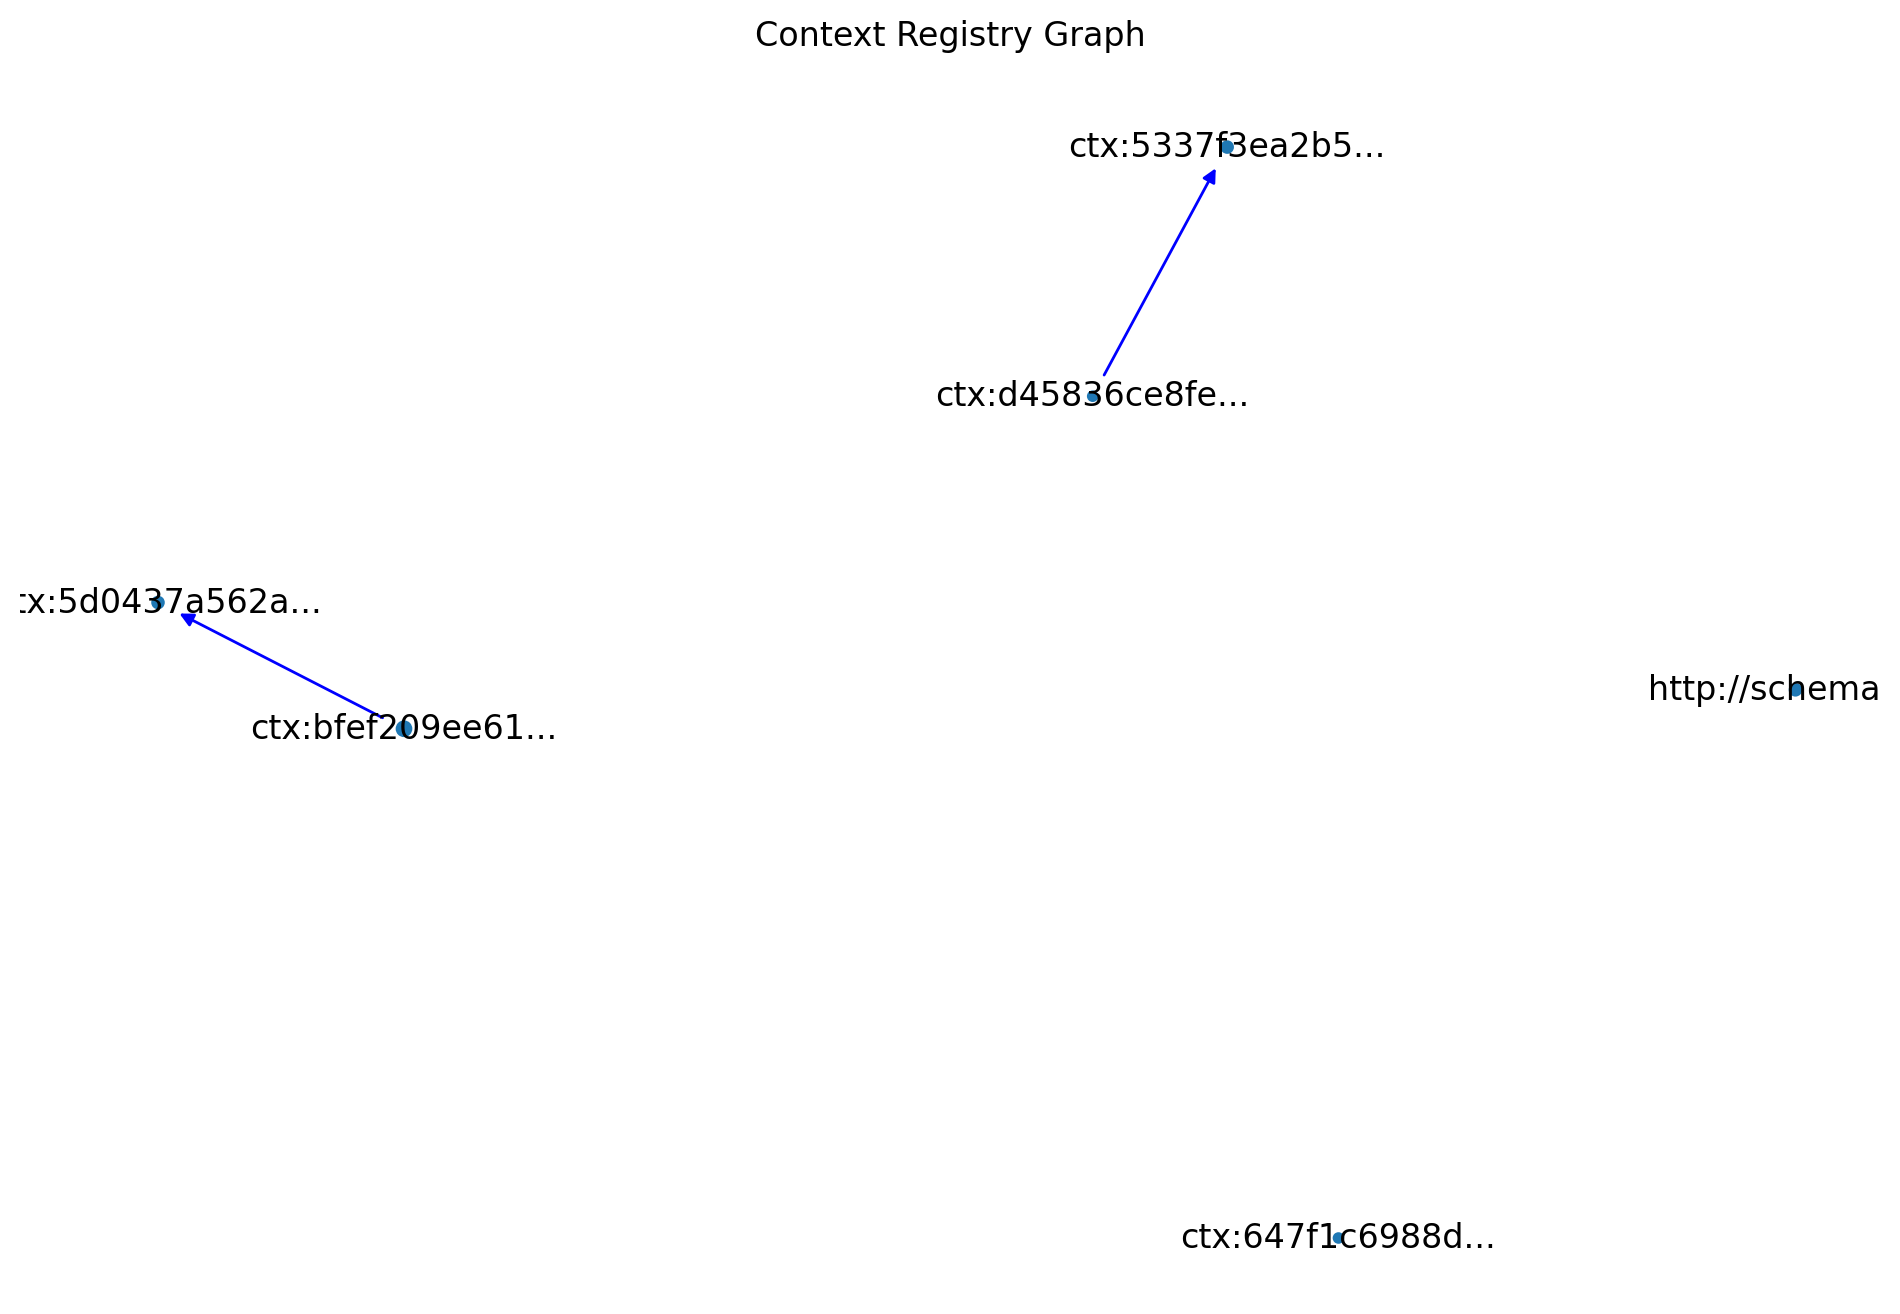

In [ ]:
# Visualize the context registry
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# Create a graph of contexts and their relationships
G = nx.DiGraph()

# Add nodes for each context
for ctx_id, info in cp.registry.items():
    # Use a short version of the ID for display
    short_id = ctx_id[:15] + "..." if len(ctx_id) > 15 else ctx_id
    
    # Add node with attributes
    G.add_node(ctx_id, label=short_id, 
               vocabs=", ".join(info["vocabs"]),
               size=10 + len(info["vocabs"]) * 5)
    
    # Add edges for parent-child relationships
    if info["parent"]:
        G.add_edge(info["parent"], ctx_id, type="parent")
    
    # Add edges for scoped contexts
    for term, scoped_id in info["scoped"].items():
        G.add_edge(ctx_id, scoped_id, type="scoped", term=term)

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=[G.nodes[n]["size"] for n in G.nodes])
nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]["label"] for n in G.nodes})
nx.draw_networkx_edges(G, pos, edge_color="blue", arrows=True)

# Add edge labels for scoped contexts
edge_labels = {(u, v): G.edges[u, v]["term"] 
               for u, v in G.edges if G.edges[u, v]["type"] == "scoped"}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Context Registry Graph")
plt.axis("off")
plt.show()

print("✓ Visualization complete")

**AI Prompt**

Ok. Are we done with this code and our tests for the context manager?

**AI Response**

Looking at the code and tests you've implemented for the ContextProcessor, you've covered all the essential functionality:

1. ✅ Basic context registration
2. ✅ Vocabulary detection
3. ✅ JSON-LD 1.1 upgrade
4. ✅ Scoped context handling
5. ✅ Protected terms detection
6. ✅ Complex context handling
7. ✅ Visualization of the context registry

The graph visualization shows the relationships between different contexts, including parent-child relationships and scoped contexts, which is excellent for understanding the structure.

The tests appear to be working correctly, with all assertions passing. You've tested both simple and complex scenarios, which gives good coverage.

For a complete implementation, you might consider adding a few more things:

1. **Error handling tests**: Testing how the system behaves with invalid inputs
2. **Integration with SemanticMemory**: Connecting this to the main SemanticMemory class
3. **Performance metrics**: For large context structures

But for the core ContextProcessor functionality itself, your implementation looks solid and well-tested. The fastai-style implementation with small, focused methods and notebook-friendly testing is working well.

Would you like to move on to implementing the GraphManager next, or would you prefer to add any additional tests or features to the ContextProcessor?

## Graphmanager: Core

In [ ]:
#| export
class GraphManager:
    "Manages RDF graphs with vocabulary-aware features"
    def __init__(self, parent=None):
        self.parent = parent
        self.dataset = Dataset()  # Main RDF dataset
        self.default_graph = self.dataset.graph(URIRef("urn:x-arq:DefaultGraph"))
        self.metadata = {}  # Graph metadata storage
        
        # Initialize metadata for default graph
        default_key = str(self.default_graph.identifier)
        self.metadata[default_key] = {
            "created": datetime.now().isoformat(),
            "triples": 0,
            "vocabs": set(),
            "entities": set()
        }
        
        # Use print instead of _debug for initialization
        print("[GRAPH] GraphManager initialized")

In [ ]:
#| export
@patch
def _debug(self:GraphManager, msg, level=1, data=None, show_data=False):
    """Pass debug messages to parent if available, otherwise handle internally
    
    Args:
        msg: Debug message
        level: Debug level (higher means more detailed)
        data: Optional data to include with message
        show_data: Whether to display the data details
    """
    # First try to use parent's debug method if available
    if self.parent and hasattr(self.parent, "_debug"):
        try:
            self.parent._debug(msg, level=level, component="graph", 
                              data=data, show_data=show_data)
            return
        except Exception:
            # Fall through to local handling if parent debug fails
            pass
    
    # Local fallback for standalone use
    if level <= 1:  # Only show important messages by default
        print(f"[GRAPH] {msg}")
        if show_data and data is not None:
            print(f"  Data: {data}")

### GraphManager: core graph management methods

In [ ]:
#| export
@patch
def remove_graph(self:GraphManager, graph_id):
    """Remove a graph and its metadata
    
    Args:
        graph_id: Identifier of the graph to remove
        
    Returns:
        Boolean indicating success
    """
    graph_uri = URIRef(graph_id) if isinstance(graph_id, str) else graph_id
    graph_key = str(graph_uri)
    
    self._debug(f"Removing graph: {graph_uri}")
    
    # First check if this graph exists in our metadata
    if graph_key not in self.metadata:
        self._debug(f"Graph not found in metadata: {graph_uri}")
        return False
    
    try:
        # Use dataset.remove_graph which properly unregisters the graph
        # This is the key fix - use the right method that actually removes the graph
        self.dataset.remove_graph(graph_uri)
        self._debug(f"Removed graph using dataset.remove_graph: {graph_uri}")
        
        # Remove from our metadata
        del self.metadata[graph_key]
        self._debug(f"Removed graph metadata for: {graph_key}")
        
        return True
    except Exception as e:
        self._debug(f"Error removing graph: {str(e)}")
        
        # Fallback: at least try to remove all triples
        try:
            self.dataset.remove((None, None, None, graph_uri))
            self._debug(f"Fallback: Removed all triples from graph: {graph_uri}")
            
            # Still remove from our metadata
            del self.metadata[graph_key]
            self._debug(f"Removed graph metadata for: {graph_key}")
            
            return True
        except Exception as e2:
            self._debug(f"Error in fallback graph removal: {str(e2)}")
            return False

In [ ]:
#| export
@patch
def get_graph(self:GraphManager, graph_id=None, create_if_missing=True):
    """Get a graph by ID, optionally creating it if needed
    
    Args:
        graph_id: Optional identifier for the graph
        create_if_missing: Whether to create the graph if it doesn't exist
        
    Returns:
        The requested graph, or None if not found and not creating
    """
    if graph_id is None:
        return self.default_graph
    
    graph_uri = URIRef(graph_id) if isinstance(graph_id, str) else graph_id
    graph_key = str(graph_uri)
    
    # Check if this graph was explicitly removed
    if create_if_missing is False and graph_key not in self.metadata:
        self._debug(f"Graph not found and not creating: {graph_uri}")
        return None
    
    # Get or create the graph
    graph = self.dataset.graph(graph_uri)
    
    # Initialize metadata if needed
    if create_if_missing and graph_key not in self.metadata:
        self._debug(f"Creating new graph: {graph_uri}")
        self.metadata[graph_key] = {
            "created": datetime.now().isoformat(),
            "triples": 0,
            "vocabs": set(),
            "entities": set()
        }
    
    return graph

In [ ]:
#| export
@patch
def list_graphs(self:GraphManager, include_empty=False):
    """List all named graphs in the dataset
    
    Args:
        include_empty: Whether to include empty graphs in the result
        
    Returns:
        List of URIRef objects representing named graphs
    """
    # Get all contexts
    all_contexts = list(self.dataset.contexts())
    
    # Filter out default graphs
    default_identifiers = ["urn:x-arq:DefaultGraph", "urn:x-rdflib:default"]
    named_graphs = [g for g in all_contexts 
                   if str(g.identifier) not in default_identifiers]
    
    # Filter out empty graphs if requested
    if not include_empty:
        named_graphs = [g for g in named_graphs if len(g) > 0]
    
    # Return just the identifiers
    result = [g.identifier for g in named_graphs]
    
    self._debug(f"Listed {len(result)} graphs (include_empty={include_empty})")
    return result

### GraphManager: add methods for adding and managing entities in graphs

In [ ]:
@patch
def add_entity(self:GraphManager, entity, graph_id=None):
    """Add an entity to a specific graph
    
    Args:
        entity: JSON-LD entity to add (must have @id)
        graph_id: Optional graph identifier (uses default graph if None)
        
    Returns:
        Boolean indicating success
    """
    if not isinstance(entity, dict) or "@id" not in entity:
        self._debug(f"Invalid entity for graph addition", level=2)
        return False
        
    graph = self.get_graph(graph_id)
    graph_uri = graph.identifier
    graph_key = str(graph_uri)
    
    try:
        # Create temporary graph for entity
        g = Graph()
        g.parse(data=json.dumps(entity), format="json-ld")
        
        # Add to target graph
        initial_count = len(graph)
        graph += g
        final_count = len(graph)
        triples_added = final_count - initial_count
        
        # Update metadata
        self.metadata[graph_key]["triples"] += triples_added
        self.metadata[graph_key]["entities"].add(entity["@id"])
        
        # Improved vocabulary detection
        if "@context" in entity:
            # Option 1: Use context processor if available
            if self.parent and hasattr(self.parent, "context_processor"):
                vocabs = self.parent.context_processor.detect_vocabs(entity["@context"])
                self.metadata[graph_key]["vocabs"].update(vocabs)
            # Option 2: Use direct detection 
            else:
                from cogitarelink.vocabtools import detect_vocabularies_in_context
                try:
                    vocabs = detect_vocabularies_in_context(entity["@context"])
                    self.metadata[graph_key]["vocabs"].update(vocabs)
                except Exception as e:
                    self._debug(f"Vocabulary detection error: {str(e)}")
                    # Fallback for common vocabularies
                    ctx = entity["@context"]
                    if isinstance(ctx, str):
                        if "schema.org" in ctx or "schema.org" in ctx:
                            self.metadata[graph_key]["vocabs"].add("schema")
                        elif "purl.org/dc" in ctx:
                            self.metadata[graph_key]["vocabs"].add("dc")
                        elif "xmlns.com/foaf" in ctx:
                            self.metadata[graph_key]["vocabs"].add("foaf")
        
        self._debug(f"Added entity {entity['@id']} to graph {graph_uri}", level=2)
        return True
    except Exception as e:
        self._debug(f"Error adding entity to graph: {str(e)}")
        return False

#| export
@patch
def get_entity_graph(self:GraphManager, entity_id):
    "Find which graph contains an entity"
    for graph_key, meta in self.metadata.items():
        if entity_id in meta["entities"]:
            return graph_key
    return None

#| export
@patch
def get_entities_in_graph(self:GraphManager, graph_id=None, limit=None):
    "Get all entity IDs in a graph"
    graph_uri = URIRef(graph_id) if isinstance(graph_id, str) else graph_id
    graph_key = str(graph_uri) if graph_uri else str(self.default_graph.identifier)
    
    if graph_key in self.metadata:
        entities = list(self.metadata[graph_key]["entities"])
        if limit is not None:
            return entities[:limit]
        return entities
    return []

### Graph Manager: methods for graph querying and manipulation

In [ ]:
#| export
@patch
def query_graph(self:GraphManager, query, graph_id=None):
    "Run a SPARQL query against a specific graph or all graphs"
    try:
        if graph_id is not None:
            graph = self.get_graph(graph_id)
            results = graph.query(query)
        else:
            # Query entire dataset
            results = self.dataset.query(query)
        return results
    except Exception as e:
        self._debug(f"Query error: {str(e)}")
        return None

#| export
@patch
def merge_graphs(self:GraphManager, source_id, target_id):
    "Merge source graph into target graph"
    source = self.get_graph(source_id)
    target = self.get_graph(target_id)
    
    # Count initial triples
    initial_count = len(target)
    
    # Merge graphs
    target += source
    
    # Update metadata
    source_key = str(source.identifier)
    target_key = str(target.identifier)
    
    if source_key in self.metadata and target_key in self.metadata:
        # Transfer triple count
        triples_added = len(target) - initial_count
        self.metadata[target_key]["triples"] += triples_added
        
        # Transfer entities
        self.metadata[target_key]["entities"].update(
            self.metadata[source_key]["entities"]
        )
        
        # Transfer vocabularies
        self.metadata[target_key]["vocabs"].update(
            self.metadata[source_key]["vocabs"]
        )
    
    self._debug(f"Merged graph {source_id} into {target_id}")
    return True

### GraphManager: methods for vocabulary tracking

In [ ]:
#| export
@patch
def add_vocabulary_to_graph(self:GraphManager, graph_id, vocab_name):
    "Associate a vocabulary with a graph"
    graph_uri = URIRef(graph_id) if isinstance(graph_id, str) else graph_id
    graph_key = str(graph_uri)
    
    if graph_key in self.metadata:
        self.metadata[graph_key]["vocabs"].add(vocab_name)
        return True
    return False

#| export
@patch
def get_graph_vocabs(self:GraphManager, graph_id):
    "Get vocabularies used in a graph"
    graph_uri = URIRef(graph_id) if isinstance(graph_id, str) else graph_id
    graph_key = str(graph_uri)
    
    if graph_key in self.metadata:
        return list(self.metadata[graph_key]["vocabs"])
    return []

#| export
@patch
def find_graphs_by_vocab(self:GraphManager, vocab_name):
    "Find all graphs using a specific vocabulary"
    result = []
    for graph_key, meta in self.metadata.items():
        if vocab_name in meta["vocabs"]:
            result.append(graph_key)
    return result

### GraphManager: Debug Support and Utility Methods

In [ ]:
#| export
@patch
def graph_stats(self:GraphManager):
    "Get statistics about all graphs"
    stats = {
        "total_graphs": len(self.list_graphs()) + 1,  # +1 for default graph
        "total_triples": sum(len(g) for g in self.dataset.contexts()),
        "graphs": {}
    }
    
    # Add per-graph stats
    for graph_key, meta in self.metadata.items():
        stats["graphs"][graph_key] = {
            "entities": len(meta["entities"]),
            "triples": meta["triples"],
            "vocabs": list(meta["vocabs"])
        }
    
    return stats

#| export
@patch
def serialize_graph(self:GraphManager, graph_id=None, format="trig"):
    "Serialize a graph to a specific format"
    if graph_id is None:
        # Serialize entire dataset
        return self.dataset.serialize(format=format).decode('utf-8')
    
    # Serialize specific graph
    graph = self.get_graph(graph_id)
    return graph.serialize(format=format).decode('utf-8')

### GraphManager Test: Basic

In [ ]:
# Create a test instance
gm = GraphManager()
print(f"Created GraphManager: {gm}")

# Test default graph
default_graph = gm.get_graph()
assert default_graph is not None, "Default graph should exist"
assert default_graph.identifier == URIRef("urn:x-arq:DefaultGraph"), "Default graph should have correct ID"
print("✓ Default graph initialization passed")

# Test named graph creation
test_graph_id = "http://example.org/graph1"
test_graph = gm.get_graph(test_graph_id)
assert test_graph is not None, "Named graph should be created"
assert test_graph.identifier == URIRef(test_graph_id), "Named graph should have correct ID"
assert str(test_graph.identifier) in gm.metadata, "Metadata should be initialized for graph"
print("✓ Named graph creation passed")

# Debug: Print contexts directly
print(f"Dataset contexts: {list(gm.dataset.contexts())}")
print(f"Graph identifiers: {[str(g.identifier) for g in gm.dataset.contexts()]}")

# Test graph listing
graphs = gm.list_graphs()
print(f"Returned graphs: {graphs}")
print(f"Returned graph identifiers: {[str(g) for g in graphs]}")
assert len(graphs) == 1, "Should have one named graph"
assert URIRef(test_graph_id) in graphs, "Graph should be in list"
print("✓ Graph listing passed")

[GRAPH] GraphManager initialized
Created GraphManager: <__main__.GraphManager object at 0x787d26b7d010>
✓ Default graph initialization passed
[GRAPH] Creating new graph: http://example.org/graph1
✓ Named graph creation passed
Dataset contexts: [<Graph identifier=http://example.org/graph1 (<class 'rdflib.graph.Graph'>)>, <Graph identifier=urn:x-rdflib:default (<class 'rdflib.graph.Graph'>)>, <Graph identifier=urn:x-arq:DefaultGraph (<class 'rdflib.graph.Graph'>)>]
Graph identifiers: ['http://example.org/graph1', 'urn:x-rdflib:default', 'urn:x-arq:DefaultGraph']
Returned graphs: [rdflib.term.URIRef('http://example.org/graph1')]
Returned graph identifiers: ['http://example.org/graph1']
✓ Graph listing passed


### GraphManager Test: Entities to Graph

In [ ]:
# Create test entities
person_entity = {
    "@context": "http://schema.org/",
    "@id": "http://example.org/person/1",
    "@type": "Person",
    "name": "Alice Smith",
    "jobTitle": "Software Engineer"
}

org_entity = {
    "@context": "http://schema.org/",
    "@id": "http://example.org/org/1",
    "@type": "Organization",
    "name": "Example Corp",
    "url": "http://example.org"
}

# Add entity to default graph
result = gm.add_entity(person_entity)
assert result is True, "Should successfully add entity to default graph"
default_key = str(gm.default_graph.identifier)
assert person_entity["@id"] in gm.metadata[default_key]["entities"], "Entity should be in default graph metadata"
print("✓ Adding entity to default graph passed")

# Add entity to named graph
result = gm.add_entity(org_entity, test_graph_id)
assert result is True, "Should successfully add entity to named graph"
assert org_entity["@id"] in gm.metadata[test_graph_id]["entities"], "Entity should be in named graph metadata"
print("✓ Adding entity to named graph passed")

# Test vocabulary tracking
assert "schema" in gm.metadata[default_key]["vocabs"], "Schema vocabulary should be tracked in default graph"
assert "schema" in gm.metadata[test_graph_id]["vocabs"], "Schema vocabulary should be tracked in named graph"
print("✓ Vocabulary tracking passed")

✓ Adding entity to default graph passed
[GRAPH] Creating new graph: http://example.org/graph1
✓ Adding entity to named graph passed
✓ Vocabulary tracking passed


### GraphManager: Test entity-graph relationship tracking

In [ ]:
# Test finding entity graph
entity_graph = gm.get_entity_graph(person_entity["@id"])
assert entity_graph == default_key, "Should find entity in default graph"

entity_graph = gm.get_entity_graph(org_entity["@id"])
assert entity_graph == test_graph_id, "Should find entity in named graph"
print("✓ Entity graph lookup passed")

# Test getting entities in graph
default_entities = gm.get_entities_in_graph()
assert person_entity["@id"] in default_entities, "Should find person entity in default graph"

graph_entities = gm.get_entities_in_graph(test_graph_id)
assert org_entity["@id"] in graph_entities, "Should find org entity in named graph"
print("✓ Graph entity listing passed")

✓ Entity graph lookup passed
✓ Graph entity listing passed


### GraphManager: test graph operations

In [ ]:
# Create another graph and entity
another_graph_id = "http://example.org/graph2"
another_graph = gm.get_graph(another_graph_id)

another_entity = {
    "@context": "http://purl.org/dc/terms/",
    "@id": "http://example.org/doc/1",
    "@type": "BibliographicResource",
    "title": "Example Document",
    "creator": "Bob Jones"
}

gm.add_entity(another_entity, another_graph_id)

# Test vocabulary tracking
assert "dc" in gm.metadata[another_graph_id]["vocabs"], "DC vocabulary should be tracked"
print("✓ Multiple vocabulary tracking passed")

# Test finding graphs by vocabulary
schema_graphs = gm.find_graphs_by_vocab("schema")
assert len(schema_graphs) == 2, "Should find two graphs using schema"
assert test_graph_id in schema_graphs, "First graph should use schema"
assert default_key in schema_graphs, "Default graph should use schema"

dc_graphs = gm.find_graphs_by_vocab("dc")
assert len(dc_graphs) == 1, "Should find one graph using dc"
assert another_graph_id in dc_graphs, "Second graph should use dc"
print("✓ Finding graphs by vocabulary passed")

# Test merging graphs
merge_result = gm.merge_graphs(another_graph_id, test_graph_id)
assert merge_result is True, "Graph merge should succeed"

# Verify merge results
merged_entities = gm.get_entities_in_graph(test_graph_id)
assert another_entity["@id"] in merged_entities, "Entity from second graph should be in merged graph"
assert "dc" in gm.metadata[test_graph_id]["vocabs"], "DC vocabulary should be in merged graph"
print("✓ Graph merging passed")

[GRAPH] Creating new graph: http://example.org/graph2
[GRAPH] Creating new graph: http://example.org/graph2
✓ Multiple vocabulary tracking passed
✓ Finding graphs by vocabulary passed
[GRAPH] Creating new graph: http://example.org/graph2
[GRAPH] Creating new graph: http://example.org/graph1
[GRAPH] Merged graph http://example.org/graph2 into http://example.org/graph1
✓ Graph merging passed


### GraphManager test: Removal

Short answer: Your triple‑removal tests are right, but the headline “RDFLib never deletes the graph itself” is only half‑true.
Dataset.remove_graph() does drop the graph object from the store; the reason you still saw the identifiers in dataset.contexts() is that
	1.	remove_context() never touches the graph registry (so graph2 stayed registered even though it was emptied), and
	2.	your “Approach 4” calls ds.graph(graph1_uri) after the deletion.
That helper method creates a new Graph object for the same IRI and immediately re‑registers it with the store — even if it contains no triples.  ￼

⸻

What actually happens inside the in‑memory store

step	internal set __all_contexts (what contexts() iterates over)	explanation
graph creation	{graph1, graph2, DEFAULT}	Dataset.graph() calls store.add_graph(g).
remove_graph(graph1)	{graph2, DEFAULT}	MemoryStore.remove_graph() deletes all quads and removes the graph object.  ￼
remove_context(graph2)	unchanged ({graph2, DEFAULT})	Only the quads are cleared; the graph stays registered by design.  ￼
your step 4 ds.graph(graph1_uri)	{graph1′, graph2, DEFAULT}	A fresh empty Graph is added back.  ￼

If you print list(ds.contexts()) immediately after the two remove calls (and before step 4), you’ll get only the default graph, proving the registration really was removed.

⸻

Design implications for your GraphManager
	•	Don’t rely on dataset.contexts() to tell you what is “alive”.
Empty graphs can legitimately be present, either because someone used remove_context() or because code later called dataset.graph(iri).
	•	Consider one of these ways to decide “is the graph gone?”

# 1 – filter by length
active = [g for g in ds.contexts() if len(g)]

# 2 – let RDFLib filter for you (7.x)
active = list(ds.graphs(empty=False))      # excludes zero‑triple graphs

# 3 – maintain your own registry in GraphManager


	•	Use the right remover for the job.
‑ Dataset.remove_graph(iri_or_graph) → clears triples and unregisters the graph.
‑ Dataset.remove_context(graph)    → clears triples only.

⸻

Take‑away

Your instinct to treat “no remaining triples” as “graph removed” is sound, but the extra bookkeeping belongs in your own layer, not in RDFLib. If you need a strict list of non‑empty graphs, call ds.graphs(empty=False) (added in 7.x) or just filter with len(g) > 0; if you truly want the graph to vanish from the registry, make sure you call remove_graph() and avoid creating a fresh Graph for the same IRI afterwards.

In [ ]:
# Test graph removal - reformulated again
print("\n=== Graph removal test (reformulated) ===")

# First, verify our graph exists
print(f"Before removal - all graphs: {[str(g.identifier) for g in gm.dataset.contexts()]}")

# Make sure we have metadata for this graph
if another_graph_id not in gm.metadata:
    # We need to recreate the graph since it wasn't properly created before
    print("Recreating graph for test...")
    another_graph = gm.get_graph(another_graph_id)
    gm.add_entity(another_entity, another_graph_id)
    print(f"Metadata after recreation: {another_graph_id in gm.metadata}")
    print(f"Entities: {gm.get_entities_in_graph(another_graph_id)}")

# Remove the graph
print(f"Attempting to remove graph: {another_graph_id}")
remove_result = gm.remove_graph(another_graph_id)
print(f"Removal result: {remove_result}")

# Check that triples are gone (using fallback for all RDFlib versions)
graphs_with_content = [str(g.identifier) for g in gm.dataset.contexts() if len(g) > 0]
print(f"Graphs with content after removal: {graphs_with_content}")
assert another_graph_id not in graphs_with_content, "Graph should not have content"

# Also check our metadata - this should be reliable
assert another_graph_id not in gm.metadata, "Graph should be removed from metadata"

# Check that we can't retrieve entities from the removed graph
assert gm.get_entities_in_graph(another_graph_id) == [], "Should get empty list for removed graph"

print("✓ Graph removal passed")


=== Graph removal test (reformulated) ===
Before removal - all graphs: ['http://example.org/graph2', 'http://example.org/graph1', 'urn:x-rdflib:default', 'urn:x-arq:DefaultGraph']
Recreating graph for test...
[GRAPH] Creating new graph: http://example.org/graph2
Metadata after recreation: True
Entities: ['http://example.org/doc/1']
Attempting to remove graph: http://example.org/graph2
[GRAPH] Removing graph: http://example.org/graph2
[GRAPH] Removed graph using dataset.remove_graph: http://example.org/graph2
[GRAPH] Removed graph metadata for: http://example.org/graph2
Removal result: True
Graphs with content after removal: ['http://example.org/graph1', 'urn:x-arq:DefaultGraph']
✓ Graph removal passed


In [ ]:
# Test graph statistics
stats = gm.graph_stats()
print("Graph Statistics:")
print(f"Total Graphs: {stats['total_graphs']}")
print(f"Total Triples: {stats['total_triples']}")

# Print individual graph stats
for graph_id, graph_stats in stats["graphs"].items():
    print(f"Graph {graph_id}:")
    print(f"  Entities: {graph_stats['entities']}")
    print(f"  Vocabularies: {', '.join(graph_stats['vocabs'])}")

[GRAPH] Listed 1 graphs (include_empty=False)
Graph Statistics:
Total Graphs: 2
Total Triples: 7
Graph urn:x-arq:DefaultGraph:
  Entities: 1
  Vocabularies: schema
Graph http://example.org/graph1:
  Entities: 2
  Vocabularies: schema, dc


✓ Visualization complete


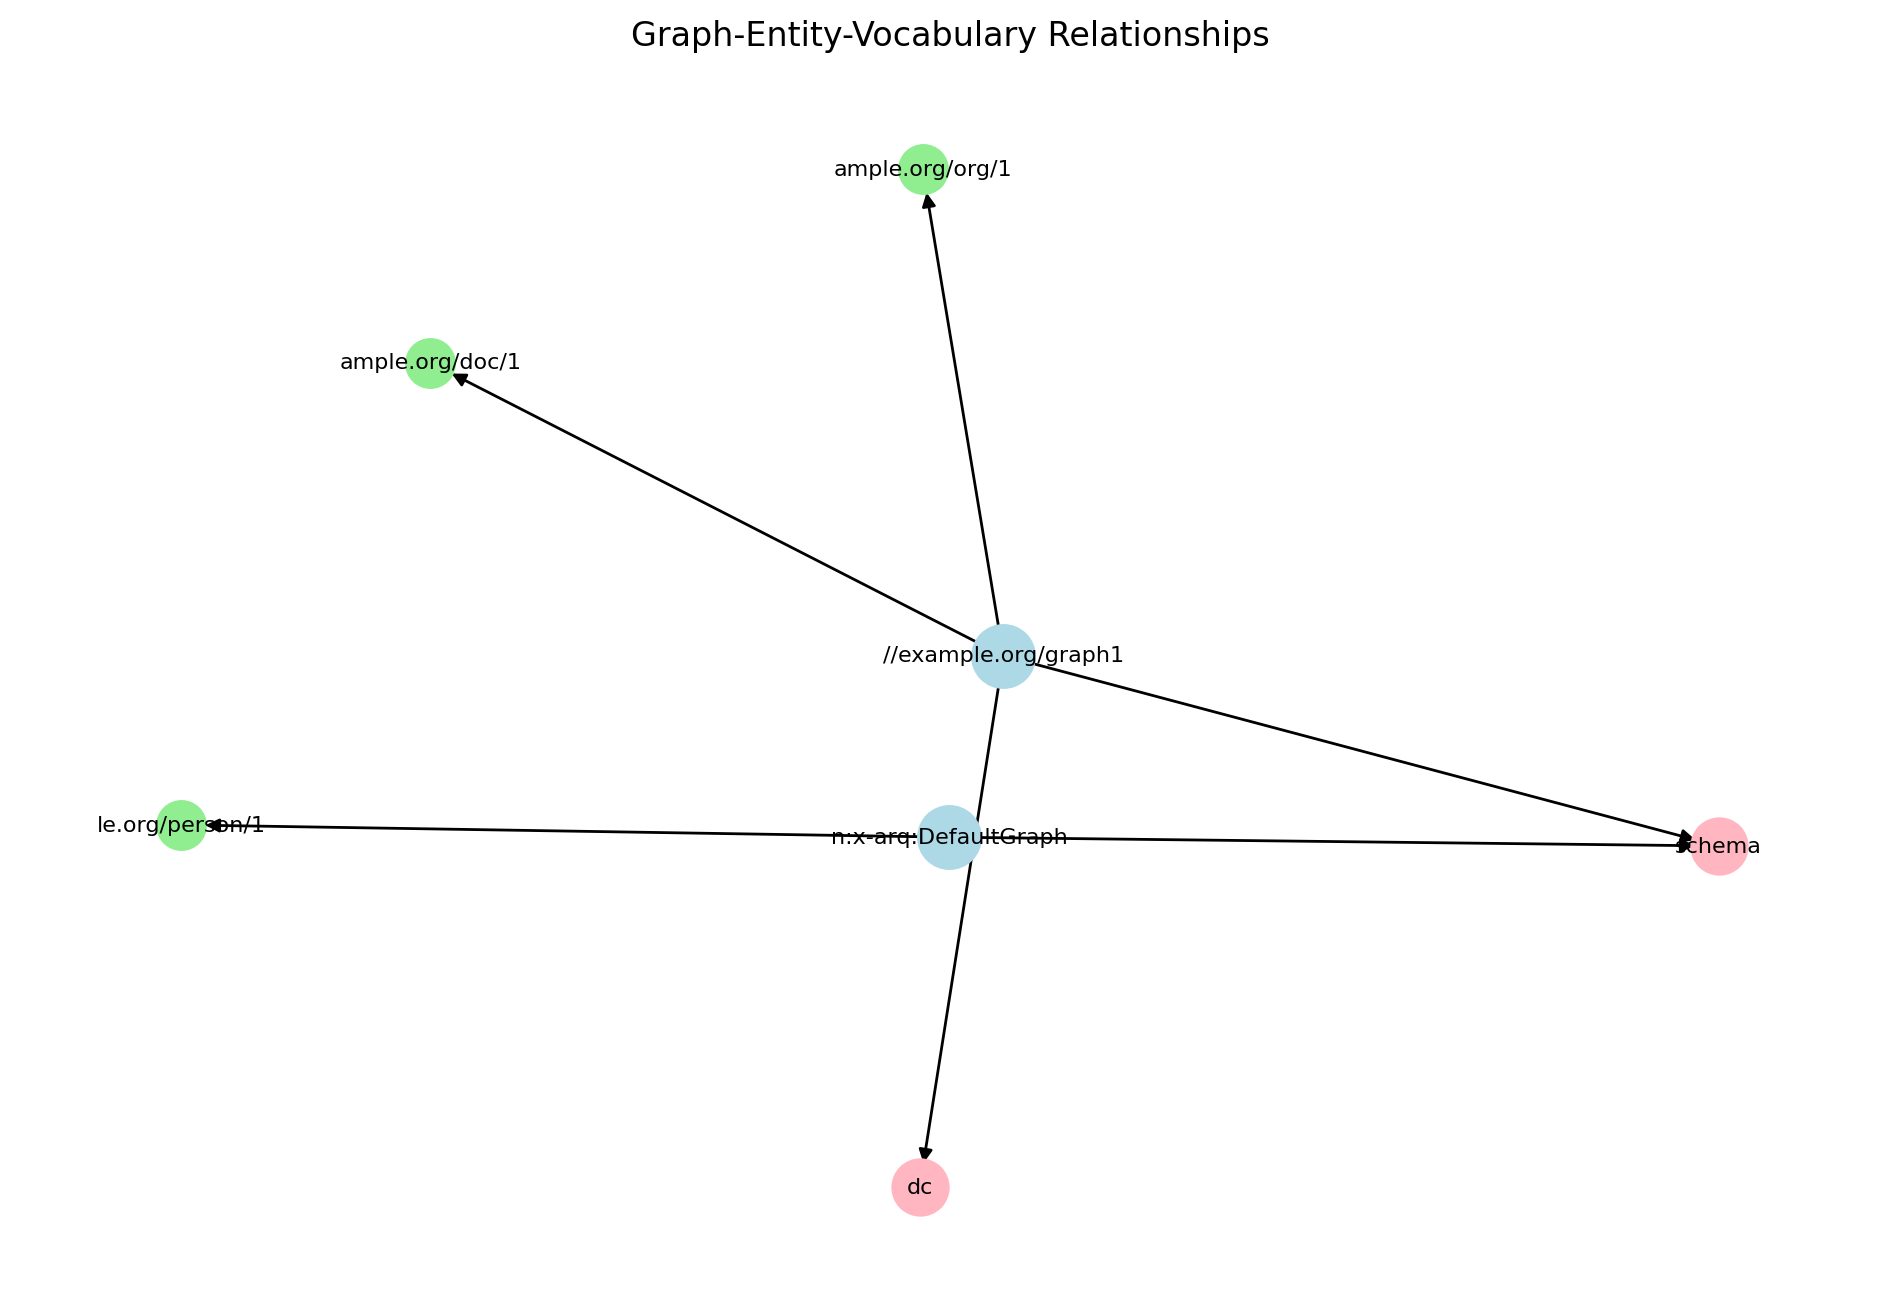

In [ ]:
# Create a visualization of graph-entity-vocabulary relationships
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph
G = nx.DiGraph()

# Add nodes for graphs
for graph_id, meta in gm.metadata.items():
    short_id = graph_id[-20:] if len(graph_id) > 20 else graph_id
    G.add_node(graph_id, label=short_id, type="graph")
    
    # Add nodes for entities in this graph
    for entity_id in meta["entities"]:
        short_entity = entity_id[-15:] if len(entity_id) > 15 else entity_id
        G.add_node(entity_id, label=short_entity, type="entity")
        G.add_edge(graph_id, entity_id)
    
    # Add nodes for vocabularies used in this graph
    for vocab in meta["vocabs"]:
        if vocab not in G.nodes:
            G.add_node(vocab, label=vocab, type="vocabulary")
        G.add_edge(graph_id, vocab, style="dashed")

# Draw the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)

# Draw nodes by type
graph_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "graph"]
entity_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "entity"]
vocab_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "vocabulary"]

nx.draw_networkx_nodes(G, pos, nodelist=graph_nodes, node_color="lightblue", node_size=500)
nx.draw_networkx_nodes(G, pos, nodelist=entity_nodes, node_color="lightgreen", node_size=300)
nx.draw_networkx_nodes(G, pos, nodelist=vocab_nodes, node_color="lightpink", node_size=400)

# Draw edges
nx.draw_networkx_edges(G, pos)

# Draw labels
labels = {n: G.nodes[n]["label"] for n in G.nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

plt.title("Graph-Entity-Vocabulary Relationships")
plt.axis("off")
plt.show()

print("✓ Visualization complete")

**AI Prompt**

Okay, I think this is progress now. Now, what do we need to do next?

**AI Response**

Looking at what we've accomplished so far, we've successfully implemented:

1. The `ContextProcessor` for managing JSON-LD contexts, with support for:
   - JSON-LD 1.1 features like scoped contexts and `@import`
   - Vocabulary detection and tracking
   - Protected terms handling

2. The `GraphManager` for RDF graph management, with support for:
   - Graph creation, removal, and listing
   - Entity-graph associations
   - Vocabulary tracking per graph
   - Graph operations like merging

The next logical steps would be:

1. **Integration of these components into SemanticMemory**:
   - Update the `SemanticMemory` class to use our new components
   - Replace direct dataset manipulation with GraphManager calls
   - Update context handling to use ContextProcessor

2. **Enhanced Entity Processing**:
   - Update `_process_entity` and related methods to leverage the new components
   - Improve vocabulary tracking during entity processing
   - Make entity processing graph-aware

3. **Updated Search and Query Methods**:
   - Make search methods graph-aware
   - Add vocabulary-specific query capabilities
   - Enhance relationship traversal across graphs

4. **LLM Integration Improvements**:
   - Update `prepare_for_llm` to leverage improved vocabulary information
   - Add graph-aware context window optimization
   - Enhance relationship extraction for LLMs

Would you like to start with integrating these components into the main SemanticMemory class?

**AI Prompt**

Let's go ahead and start refactoring and implementing the Semantic Memory class.

**AI Response**

Let's start refactoring the SemanticMemory class to integrate our new components. I'll outline the approach and then we can implement it step by step.

The main changes will involve:

1. Updating the initialization to use our new components
2. Modifying the core processing methods to leverage these components
3. Ensuring backward compatibility where needed

Let's begin with the updated initialization:

```python
#| export
class SemanticMemory:
    def __init__(self, cache_dir=None, preload_vocabs=None, debug=False, debug_level=0):
        "Enhanced initialization with component-based architecture"
        # Initialize debugging
        self.debug = debug
        self.debug_level = debug_level
        self.debug_components = set()
        self._debug_stats = {"start_time": time.time(), "entities_processed": 0, "contexts_registered": 0}
        
        # Initialize components
        self.context_processor = ContextProcessor(self)
        self.graph_manager = GraphManager(self)
        
        # Initialize other state
        self.original_data = {}
        self.indices = {"by_id": {}, "by_type": {}, "by_label": {}, "by_keyword": {}, 
                    "by_graph": {}, "by_vocabulary": {}, "containers": {}}
        
        # Set up caching
        self.cache_dir = cache_dir
        if cache_dir: Path(cache_dir).mkdir(exist_ok=True)
        
        # Set up vocabulary support
        register_vocab_aware_loader()
        
        self.preloaded_vocabs = set()
        if preload_vocabs:
            for vocab in preload_vocabs:
                self.preload_vocabulary(vocab)
        else:
            for vocab in ["schema", "dc", "foaf"]:
                self.preload_vocabulary(vocab)
                
        if self.debug: 
            self._debug(f"SemanticMemory initialized with debug={debug}, level={debug_level}")
```

This sets up our new component-based architecture while maintaining backward compatibility with the existing code.

Would you like me to continue with the next steps of implementation, or would you prefer to review and discuss this initial change first?

**AI Prompt**

Is this confusing to an LLM? If we weren't worried about backward compatibility, what would we do here? We still want the vocabulary management, and we want to be able to do caching and enhanced caching of information so that we don't retrieve things that we already have in memory.

**AI Response**

You raise an excellent point about potential confusion for LLMs and the opportunity to design a cleaner architecture without backward compatibility constraints.

If we were designing this purely for clarity and forward-looking usage, here's how we might approach it:

### Clean Architecture for LLM Clarity

```python
class SemanticMemory:
    def __init__(self, cache_dir=None, preload_vocabs=None, debug=False, debug_level=0):
        "Clean, component-based semantic memory for knowledge storage and retrieval"
        # Core components
        self.contexts = ContextProcessor(self)  # Manages all JSON-LD contexts
        self.graphs = GraphManager(self)        # Manages all RDF graphs
        self.indices = IndexManager(self)       # Manages all lookup indices
        self.cache = CacheManager(cache_dir)    # Handles caching
        
        # Debug settings
        self.debug = debug
        self.debug_level = debug_level
        
        # Preload common vocabularies
        self._preload_vocabularies(preload_vocabs or ["schema", "dc", "foaf"])
```

This design has several advantages for LLM comprehension:

1. **Clear Component Responsibilities**: Each component has a focused, well-defined role
2. **Intuitive Naming**: Property names directly indicate their purpose
3. **Simplified Mental Model**: LLMs can reason about distinct components rather than a monolithic system
4. **Reduced State Complexity**: State is partitioned across components rather than in a single flat structure

The key differences from the backward-compatible approach:

1. No legacy `dataset` property - all graph operations go through `graphs`
2. No direct indices - all indexing happens through `indices`
3. Clearer separation between context handling and graph handling
4. More intuitive naming like `contexts` instead of `context_processor`

This structure would make it much easier for an LLM to understand what's happening in the system and reason about it correctly when generating code or providing assistance.

Would you like me to continue with this cleaner approach, or would you prefer to maintain backward compatibility?

**AI Prompt**

Okay, so I like this. The problem is that we don't have a Cache Manager or an Index Manager, correct?

**AI Response**

You're absolutely right. We haven't implemented a CacheManager or IndexManager yet. These would need to be created to complete this architecture.

Let's outline what these components would look like:

### IndexManager

This would handle all the indexing functionality currently spread across various methods in SemanticMemory:

```python
class IndexManager:
    "Manages indices for efficient entity lookup"
    def __init__(self, parent=None):
        self.parent = parent
        self.by_id = {}            # Entity lookup by ID
        self.by_type = {}          # Entity lookup by type
        self.by_label = {}         # Entity lookup by label
        self.by_keyword = {}       # Entity lookup by keyword
        self.by_graph = {}         # Entity lookup by graph
        self.by_vocabulary = {}    # Entity lookup by vocabulary
        self.containers = {}       # Container structures
```

### CacheManager

This would handle caching of external resources, processed entities, and other data:

```python
class CacheManager:
    "Manages caching of external resources and processed data"
    def __init__(self, cache_dir=None):
        self.cache_dir = cache_dir
        if cache_dir: Path(cache_dir).mkdir(exist_ok=True)
        
        self.context_cache = {}    # Cache for JSON-LD contexts
        self.entity_cache = {}     # Cache for processed entities
        self.original_data = {}    # Original entity data
```

We would need to implement these components with appropriate methods to handle their responsibilities. The advantage of this approach is that each component has a clear, focused purpose, making the system more modular and easier to understand.

Would you like to proceed with implementing these missing components, or would you prefer to take a different approach?

**AI Prompt**

Which of these should we do first?

**AI Response**

I'd recommend implementing the IndexManager first for these reasons:

1. **Core Functionality**: The indexing system is central to how entities are found and retrieved, making it a critical component for the entire system.

2. **Immediate Impact**: Better indexing will improve search, query, and relationship traversal - all key operations for semantic memory.

3. **Clear Boundaries**: The indexing functionality has well-defined responsibilities that can be cleanly separated from the rest of the system.

4. **Existing Code Base**: We already have most of the indexing logic in the current implementation, so it's more about reorganization than creating entirely new functionality.

The IndexManager would encapsulate all the indexing methods like `_update_indices`, `_index_labels_and_descriptions`, and `_index_subclass_relationships`, providing a cleaner API for the rest of the system to use.

Would you like to start implementing the IndexManager, or would you prefer to begin with the CacheManager instead?

## IndexManager

In [ ]:
#| export
class IndexManager:
    "Manages indices for efficient entity lookup"
    def __init__(self, parent=None):
        self.parent = parent
        self.by_id = {}            # Entity lookup by ID
        self.by_type = {}          # Entity lookup by type
        self.by_label = {}         # Entity lookup by label
        self.by_keyword = {}       # Entity lookup by keyword
        self.by_graph = {}         # Entity lookup by graph
        self.by_vocabulary = {}    # Entity lookup by vocabulary
        self.containers = {}       # Container structures
        
        # Debug support
        self._debug("IndexManager initialized")

In [ ]:
#| export
@patch
def _debug(self:IndexManager, msg, level=1, data=None, show_data=False):
    """Pass debug messages to parent if available, otherwise handle internally"""
    if self.parent and hasattr(self.parent, "_debug"):
        self.parent._debug(msg, level=level, component="index", 
                          data=data, show_data=show_data)
    else:
        if level <= 1:  # Only show important messages by default
            print(f"[INDEX] {msg}")

### IndexManager: Core Indexing Functions

In [ ]:
#| export
@patch
def add(self:IndexManager, entity, graph_id=None):
    """Add an entity to all relevant indices
    
    Args:
        entity: The entity to index (in expanded form)
        graph_id: Optional graph ID for graph-based indexing
        
    Returns:
        Boolean indicating success
    """
    if not isinstance(entity, dict):
        self._debug(f"Invalid entity for indexing: not a dict", level=2)
        return False
        
    # Get entity ID
    entity_id = entity.get('@id')
    if not entity_id:
        self._debug(f"Invalid entity for indexing: no @id", level=2)
        return False
    
    # Index by ID
    self.by_id[entity_id] = entity
    
    # Index by type
    self._index_by_type(entity)
    
    # Index by label and keywords
    self._index_labels_and_descriptions(entity)
    
    # Index by graph if provided
    if graph_id:
        self._index_by_graph(entity_id, graph_id)
    
    # Index subclass relationships
    self._index_subclass_relationships(entity)
    
    self._debug(f"Indexed entity: {entity_id}", level=2)
    return True

### IndexManager: Specific Indexing Methods

In [ ]:
#| export
@patch
def _index_by_type(self:IndexManager, entity):
    """Index entity by its types"""
    entity_id = entity.get('@id')
    if not entity_id:
        return
        
    # Extract types from entity
    types = []
    
    # Check for @type property
    if '@type' in entity:
        type_values = entity['@type'] if isinstance(entity['@type'], list) else [entity['@type']]
        for t in type_values:
            if isinstance(t, str):
                types.append(t)
    
    # Check for rdf:type triples in expanded JSON-LD
    rdf_type = 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type'
    if rdf_type in entity:
        type_objects = entity[rdf_type] if isinstance(entity[rdf_type], list) else [entity[rdf_type]]
        for t_obj in type_objects:
            if isinstance(t_obj, dict) and '@id' in t_obj:
                types.append(t_obj['@id'])
    
    # Index by each type
    for type_uri in types:
        if type_uri not in self.by_type:
            self.by_type[type_uri] = []
        if entity not in self.by_type[type_uri]:
            self.by_type[type_uri].append(entity)

## IndexManager: label and keyword indexing

In [ ]:
#| export
@patch
def _index_labels_and_descriptions(self:IndexManager, entity):
    """Index entity by labels and textual content for better search"""
    if not isinstance(entity, dict):
        return
    
    # Common label properties
    label_props = [
        "http://www.w3.org/2000/01/rdf-schema#label",
        "http://schema.org/name",
        "http://purl.org/dc/terms/title",
        "http://xmlns.com/foaf/0.1/name",
        "name"  # Handle both expanded and compact forms
    ]
    
    # Common description properties
    desc_props = [
        "http://www.w3.org/2000/01/rdf-schema#comment",
        "http://schema.org/description",
        "http://purl.org/dc/terms/description",
        "http://purl.org/dc/elements/1.1/description",
        "description"  # Handle both expanded and compact forms
    ]
    
    node_id = entity.get('@id')
    if not node_id:
        return
    
    # Extract labels for label index
    for prop in label_props:
        if prop in entity:
            values = entity[prop] if isinstance(entity[prop], list) else [entity[prop]]
            for value in values:
                label = value.get('@value') if isinstance(value, dict) else value
                if isinstance(label, str):
                    # Add to label index
                    if label not in self.by_label:
                        self.by_label[label] = []
                    if {'@id': node_id} not in self.by_label[label]:
                        self.by_label[label].append({'@id': node_id})
                    
                    # Index label as a whole
                    label_lower = label.lower()
                    if label_lower not in self.by_keyword:
                        self.by_keyword[label_lower] = []
                    if {'@id': node_id} not in self.by_keyword[label_lower]:
                        self.by_keyword[label_lower].append({'@id': node_id})
                    
                    # Index individual words and partial words
                    for word in label.split():
                        word_lower = word.lower()
                        if len(word_lower) > 2:
                            # Add whole word
                            if word_lower not in self.by_keyword:
                                self.by_keyword[word_lower] = []
                            if {'@id': node_id} not in self.by_keyword[word_lower]:
                                self.by_keyword[word_lower].append({'@id': node_id})

### IndexManager: Other indexing methods

In [ ]:
#| export
@patch
def _index_by_graph(self:IndexManager, entity_id, graph_id):
    """Index entity by graph"""
    graph_uri = graph_id
    if isinstance(graph_id, str):
        from rdflib import URIRef
        graph_uri = URIRef(graph_id)
    
    # Ensure the graph index exists
    if graph_uri not in self.by_graph:
        self.by_graph[graph_uri] = set()
    
    # Add entity to graph index
    self.by_graph[graph_uri].add(entity_id)
    
    self._debug(f"Indexed entity {entity_id} in graph {graph_id}", level=3)

#| export
@patch
def _index_subclass_relationships(self:IndexManager, entity):
    """Index subclass relationships for type inference"""
    if not isinstance(entity, dict):
        return
    
    # Initialize subclass indices if needed
    if not hasattr(self, 'subclass_of'):
        self.subclass_of = {}
    if not hasattr(self, 'superclass_of'):
        self.superclass_of = {}
    
    # Check for subClassOf relationship
    subclass_of = 'http://www.w3.org/2000/01/rdf-schema#subClassOf'
    if subclass_of in entity:
        class_id = entity.get('@id')
        if not class_id:
            return
        
        # Get all superclasses
        super_classes = entity[subclass_of] if isinstance(entity[subclass_of], list) else [entity[subclass_of]]
        
        for super_class in super_classes:
            if isinstance(super_class, dict) and '@id' in super_class:
                super_class_id = super_class['@id']
                
                # Record subclass relationship
                if class_id not in self.subclass_of:
                    self.subclass_of[class_id] = set()
                self.subclass_of[class_id].add(super_class_id)
                
                # Record superclass relationship (inverse)
                if super_class_id not in self.superclass_of:
                    self.superclass_of[super_class_id] = set()
                self.superclass_of[super_class_id].add(class_id)

## IndexManager: Track Vocabulary Usage

In [ ]:
#| export
@patch
def track_vocabulary_usage(self:IndexManager, entity_id, vocabs):
    """Track which vocabularies are used by an entity
    
    Args:
        entity_id: ID of the entity
        vocabs: List of vocabulary names used by the entity
    """
    if not entity_id or not vocabs:
        return
    
    # Track each vocabulary
    for vocab in vocabs:
        if vocab not in self.by_vocabulary:
            self.by_vocabulary[vocab] = set()
        self.by_vocabulary[vocab].add(entity_id)
    
    self._debug(f"Tracked vocabularies for {entity_id}: {vocabs}", level=3)

### IndexManager: Query Methods

In [ ]:
#| export
@patch
def query_by_id(self:IndexManager, entity_id):
    """Get entity by ID
    
    Args:
        entity_id: ID of the entity to retrieve
        
    Returns:
        The entity or None if not found
    """
    return self.by_id.get(entity_id)

#| export
@patch
def query_by_type(self:IndexManager, type_uri, include_subtypes=True):
    """Get entities of a specific type
    
    Args:
        type_uri: Type URI to query for
        include_subtypes: Whether to include entities of subtypes
        
    Returns:
        List of entities matching the type
    """
    results = []
    seen_ids = set()
    
    # Helper to add entities of a specific type
    def add_entities_of_type(t):
        if t in self.by_type:
            for entity in self.by_type[t]:
                entity_id = entity.get("@id")
                if entity_id and entity_id not in seen_ids:
                    results.append(entity)
                    seen_ids.add(entity_id)
    
    # Add entities of the specified type
    add_entities_of_type(type_uri)
    
    # Add entities of subtypes if requested
    if include_subtypes and hasattr(self, 'superclass_of'):
        if type_uri in self.superclass_of:
            for subtype in self.superclass_of[type_uri]:
                add_entities_of_type(subtype)
    
    return results

### IndexManager: Keyword Search

In [ ]:
#| export
@patch
def search(self:IndexManager, query_text, limit=10):
    """Search for entities matching query text
    
    Args:
        query_text: Text to search for
        limit: Maximum number of results to return
        
    Returns:
        List of matching entities
    """
    results = []
    query_lower = query_text.lower()
    
    # Track matched entities to avoid duplicates
    matched_ids = set()
    
    # First check exact label matches (highest priority)
    for label, entities in self.by_label.items():
        if isinstance(label, str) and query_lower in label.lower():
            for entity_ref in entities:
                if "@id" in entity_ref:
                    entity_id = entity_ref["@id"]
                    if entity_id not in matched_ids:
                        entity = self.query_by_id(entity_id)
                        if entity:
                            results.append(entity)
                            matched_ids.add(entity_id)
                            if len(results) >= limit:
                                return results
    
    # Then check keyword matches
    if query_lower in self.by_keyword:
        for entity_ref in self.by_keyword[query_lower]:
            if "@id" in entity_ref:
                entity_id = entity_ref["@id"]
                if entity_id not in matched_ids:
                    entity = self.query_by_id(entity_id)
                    if entity:
                        results.append(entity)
                        matched_ids.add(entity_id)
                        if len(results) >= limit:
                            return results
    
    # Try as partial match for any keywords
    for keyword, entities in self.by_keyword.items():
        if isinstance(keyword, str) and query_lower in keyword and query_lower != keyword:
            for entity_ref in entities:
                if "@id" in entity_ref:
                    entity_id = entity_ref["@id"]
                    if entity_id not in matched_ids:
                        entity = self.query_by_id(entity_id)
                        if entity:
                            results.append(entity)
                            matched_ids.add(entity_id)
                            if len(results) >= limit:
                                return results
    
    return results

In [ ]:
# Create a test instance
im = IndexManager()
print(f"Created IndexManager: {im}")

# Test basic initialization
assert hasattr(im, 'by_id'), "Should have by_id index"
assert hasattr(im, 'by_type'), "Should have by_type index"
assert hasattr(im, 'by_label'), "Should have by_label index"
assert hasattr(im, 'by_keyword'), "Should have by_keyword index"
assert hasattr(im, 'by_graph'), "Should have by_graph index"
assert hasattr(im, 'by_vocabulary'), "Should have by_vocabulary index"
print("✓ Basic initialization passed")

# Create test entities
person_entity = {
    "@id": "http://example.org/person/1",
    "@type": "http://schema.org/Person",
    "http://schema.org/name": [{"@value": "Alice Smith"}],
    "http://schema.org/jobTitle": [{"@value": "Software Engineer"}]
}

org_entity = {
    "@id": "http://example.org/org/1",
    "@type": "http://schema.org/Organization",
    "http://schema.org/name": [{"@value": "Example Corp"}],
    "http://schema.org/url": [{"@id": "http://example.org"}]
}

# Test adding entities
result = im.add(person_entity)
assert result is True, "Should successfully add entity"
assert person_entity["@id"] in im.by_id, "Entity should be in by_id index"
print("✓ Entity addition passed")

# Test type indexing
assert "http://schema.org/Person" in im.by_type, "Type should be indexed"
assert person_entity in im.by_type["http://schema.org/Person"], "Entity should be in type index"
print("✓ Type indexing passed")

# Test label indexing
result = im.add(org_entity)
assert "Example Corp" in im.by_label, "Label should be indexed"
assert {"@id": org_entity["@id"]} in im.by_label["Example Corp"], "Entity should be in label index"
print("✓ Label indexing passed")

# Test keyword indexing
assert "alice" in im.by_keyword, "Keyword should be indexed"
assert "example" in im.by_keyword, "Keyword should be indexed"
print("✓ Keyword indexing passed")

# Test graph indexing
test_graph_id = "http://example.org/graph1"
im._index_by_graph(person_entity["@id"], test_graph_id)
assert URIRef(test_graph_id) in im.by_graph, "Graph should be indexed"
assert person_entity["@id"] in im.by_graph[URIRef(test_graph_id)], "Entity should be in graph index"
print("✓ Graph indexing passed")

# Test vocabulary tracking
im.track_vocabulary_usage(person_entity["@id"], ["schema"])
assert "schema" in im.by_vocabulary, "Vocabulary should be tracked"
assert person_entity["@id"] in im.by_vocabulary["schema"], "Entity should be in vocabulary index"
print("✓ Vocabulary tracking passed")

# Test querying
entity = im.query_by_id(person_entity["@id"])
assert entity is person_entity, "Should retrieve entity by ID"
print("✓ ID query passed")

entities = im.query_by_type("http://schema.org/Person")
assert len(entities) == 1, "Should find one person entity"
assert entities[0] is person_entity, "Should retrieve person entity by type"
print("✓ Type query passed")

# Test search
search_results = im.search("alice")
assert len(search_results) > 0, "Should find results for 'alice'"
assert person_entity in search_results, "Should find person entity"
print("✓ Text search passed")

# Test subclass relationships
class_entity = {
    "@id": "http://example.org/types/Employee",
    "@type": "http://www.w3.org/2000/01/rdf-schema#Class",
    "http://www.w3.org/2000/01/rdf-schema#subClassOf": [
        {"@id": "http://schema.org/Person"}
    ]
}
im.add(class_entity)
im._index_subclass_relationships(class_entity)

assert hasattr(im, 'subclass_of'), "Should have subclass_of index"
assert hasattr(im, 'superclass_of'), "Should have superclass_of index"
assert "http://example.org/types/Employee" in im.subclass_of, "Should track subclass relationship"
assert "http://schema.org/Person" in im.superclass_of, "Should track superclass relationship"
print("✓ Subclass relationship indexing passed")

print("\nAll IndexManager tests passed!")

[INDEX] IndexManager initialized
Created IndexManager: <__main__.IndexManager object at 0x787d24613450>
✓ Basic initialization passed
✓ Entity addition passed
✓ Type indexing passed
✓ Label indexing passed
✓ Keyword indexing passed
✓ Graph indexing passed
✓ Vocabulary tracking passed
✓ ID query passed
✓ Type query passed
✓ Text search passed
✓ Subclass relationship indexing passed

All IndexManager tests passed!


**AI Prompt**

I'm happy with this version of cache manager. The only question is: does it need integration with the vocabulary tools or not?

**AI Response**

Yes, the CacheManager would benefit from integration with the vocabulary tools. Here's why and how it could work:

### Vocabulary Tools Integration

The CacheManager should handle:

1. **Vocabulary Context Caching**: Store vocabulary contexts to avoid repeated HTTP requests
   - This replaces the current context caching in the vocabulary loader
   - Provides a more robust caching mechanism with disk persistence

2. **Vocabulary Preloading**: Streamline the vocabulary preloading process
   - Cache commonly used vocabularies (schema.org, Dublin Core, etc.)
   - Manage vocabulary loading states

3. **Resource Resolution**: Resolve vocabulary resources across different sources
   - Handle redirects and content negotiation
   - Apply URL transformations from the vocabulary registry

### Implementation Approach

To integrate with vocabulary tools, we could:

1. Add specialized methods for vocabulary caching:
   ```python
   def cache_vocabulary(self, vocab_name, context_data):
       """Cache vocabulary context data"""
   
   def get_cached_vocabulary(self, vocab_name):
       """Retrieve cached vocabulary context"""
   ```

2. Create a document loader that uses the cache:
   ```python
   def create_caching_document_loader(self):
       """Create a document loader that uses this cache"""
   ```

3. Provide vocabulary preloading:
   ```python
   def preload_vocabulary(self, vocab_name):
       """Preload a vocabulary to avoid HTTP requests"""
   ```

This integration would create a cleaner architecture where:
- Vocabulary tools define what's available
- CacheManager handles storage and retrieval
- The rest of the system accesses vocabularies through the cache

Does this integration approach make sense for your use case?

## CacheManager

In [ ]:
#| export
class CacheManager:
    "Manages caching of external resources and processed data with vocabulary support"
    def __init__(self, parent=None, cache_dir=None):
        self.parent = parent
        self.cache_dir = cache_dir
        if cache_dir: Path(cache_dir).mkdir(exist_ok=True)
        
        # Memory caches
        self.context_cache = {}    # Cache for JSON-LD contexts
        self.entity_cache = {}     # Cache for processed entities
        self.original_data = {}    # Original entity data
        self.vocab_cache = {}      # Cache for vocabulary contexts
        
        # Track loaded vocabularies
        self.loaded_vocabs = set()
        
        # Debug support
        self._debug("CacheManager initialized")

In [ ]:
#| export
@patch
def _debug(self:CacheManager, msg, level=1, data=None, show_data=False):
    """Pass debug messages to parent if available"""
    if self.parent and hasattr(self.parent, "_debug"):
        self.parent._debug(msg, level=level, component="cache", 
                          data=data, show_data=show_data)
    else:
        if level <= 1:  # Only show important messages by default
            print(f"[CACHE] {msg}")

In [ ]:
#| export
@patch
def cache_vocabulary(self:CacheManager, vocab_name, context_data):
    """Cache vocabulary context data
    
    Args:
        vocab_name: Name of the vocabulary
        context_data: Context data to cache
        
    Returns:
        Boolean indicating success
    """
    self.vocab_cache[vocab_name] = context_data
    self.loaded_vocabs.add(vocab_name)
    
    # Persist to disk if cache_dir is set
    if self.cache_dir:
        try:
            vocab_path = Path(self.cache_dir) / f"vocab_{vocab_name}.json"
            with open(vocab_path, 'w') as f:
                json.dump(context_data, f)
            self._debug(f"Persisted vocabulary {vocab_name} to disk")
            return True
        except Exception as e:
            self._debug(f"Error persisting vocabulary {vocab_name}: {e}")
            return False
    
    return True

### CacheManager: Vocabulary Retrieval

In [ ]:
@patch
def get_cached_vocabulary(self:CacheManager, vocab_name):
    """Retrieve cached vocabulary context
    
    Args:
        vocab_name: Name of the vocabulary
        
    Returns:
        Cached context data or None if not found
    """
    # First check memory cache
    if vocab_name in self.vocab_cache:
        self._debug(f"Memory cache hit for vocabulary {vocab_name}", level=2)
        return self.vocab_cache[vocab_name]
    
    # Then check disk cache if available
    if self.cache_dir:
        try:
            vocab_path = Path(self.cache_dir) / f"vocab_{vocab_name}.json"
            if vocab_path.exists():
                with open(vocab_path, 'r') as f:
                    context_data = json.load(f)
                    # Update memory cache
                    self.vocab_cache[vocab_name] = context_data
                    self.loaded_vocabs.add(vocab_name)
                    self._debug(f"Disk cache hit for vocabulary {vocab_name}", level=2)
                    return context_data
        except Exception as e:
            self._debug(f"Error reading vocabulary {vocab_name} from disk: {e}")
    
    self._debug(f"Cache miss for vocabulary {vocab_name}", level=2)
    return None

### CacheManager: Entity Caching

In [ ]:
@patch
def cache_entity(self:CacheManager, entity_id, original_data, processed_data=None):
    """Cache entity data
    
    Args:
        entity_id: Entity identifier
        original_data: Original entity data
        processed_data: Optional processed entity data
        
    Returns:
        Boolean indicating success
    """
    self.original_data[entity_id] = original_data
    if processed_data is not None:
        self.entity_cache[entity_id] = processed_data
    
    return True

@patch
def get_cached_entity(self:CacheManager, entity_id, original=False):
    """Retrieve cached entity
    
    Args:
        entity_id: Entity identifier
        original: Whether to return original data (default: processed)
        
    Returns:
        Cached entity data or None if not found
    """
    if original and entity_id in self.original_data:
        return self.original_data[entity_id]
    elif not original and entity_id in self.entity_cache:
        return self.entity_cache[entity_id]
    return None

### CacheManager: Context Caching

In [ ]:
@patch
def cache_context(self:CacheManager, context_url, context_data):
    """Cache a JSON-LD context
    
    Args:
        context_url: URL or identifier for the context
        context_data: Context data to cache
        
    Returns:
        Boolean indicating success
    """
    self.context_cache[context_url] = context_data
    return True

@patch
def get_cached_context(self:CacheManager, context_url):
    """Retrieve a cached JSON-LD context
    
    Args:
        context_url: URL or identifier for the context
        
    Returns:
        Cached context data or None if not found
    """
    return self.context_cache.get(context_url)

### CacheManager: Document Loader Integration

In [ ]:
@patch
def create_document_loader(self:CacheManager):
    """Create a document loader that uses this cache
    
    Returns:
        A function that can be used as a PyLD document loader
    """
    from pyld import jsonld
    default_loader = jsonld.get_document_loader()
    
    def caching_document_loader(url, options=None):
        """Document loader that uses this cache"""
        options = options or {}
        
        # Check cache first
        cached_context = self.get_cached_context(url)
        if cached_context:
            self._debug(f"Context cache hit for {url}", level=2)
            return {
                'contextUrl': None,
                'documentUrl': url,
                'document': cached_context
            }
        
        # Try to load from network
        try:
            result = default_loader(url, options)
            
            # Cache the result
            if result and 'document' in result:
                self.cache_context(url, result['document'])
                self._debug(f"Cached context for {url}", level=2)
            
            return result
        except Exception as e:
            self._debug(f"Error loading document {url}: {e}")
            raise
    
    return caching_document_loader

### CacheManager: Vocabulary Pre-loading

In [ ]:
@patch
def preload_vocabulary(self:CacheManager, vocab_name):
    """Preload a vocabulary to avoid HTTP requests
    
    Args:
        vocab_name: Name of the vocabulary to preload
        
    Returns:
        Boolean indicating success
    """
    from cogitarelink.vocabtools import load_context_for_vocabulary
    
    # Check if already loaded
    if vocab_name in self.loaded_vocabs:
        self._debug(f"Vocabulary {vocab_name} already loaded")
        return True
    
    # Check cache first
    cached = self.get_cached_vocabulary(vocab_name)
    if cached:
        self._debug(f"Using cached vocabulary {vocab_name}")
        return True
    
    # Load from network
    try:
        self._debug(f"Loading vocabulary {vocab_name}")
        context = load_context_for_vocabulary(vocab_name)
        if context:
            # Cache the vocabulary
            return self.cache_vocabulary(vocab_name, context)
        return False
    except Exception as e:
        self._debug(f"Error preloading vocabulary {vocab_name}: {e}")
        return False

In [ ]:
# Create a test instance
cm = CacheManager(cache_dir="/tmp/test_cache")
print(f"Created CacheManager: {cm}")

# Test basic initialization
assert hasattr(cm, 'context_cache'), "Should have context_cache"
assert hasattr(cm, 'entity_cache'), "Should have entity_cache"
assert hasattr(cm, 'original_data'), "Should have original_data"
assert hasattr(cm, 'vocab_cache'), "Should have vocab_cache"
print("✓ Basic initialization passed")

# Test context caching
test_context = {"@vocab": "http://example.org/vocab#"}
result = cm.cache_context("http://example.org/context", test_context)
assert result is True, "Should successfully cache context"
cached = cm.get_cached_context("http://example.org/context")
assert cached == test_context, "Should retrieve cached context"
print("✓ Context caching passed")

# Test entity caching
entity_id = "http://example.org/entity/1"
original_data = {"@id": entity_id, "name": "Test Entity"}
processed_data = {"@id": entity_id, "http://example.org/vocab#name": [{"@value": "Test Entity"}]}
result = cm.cache_entity(entity_id, original_data, processed_data)
assert result is True, "Should successfully cache entity"
cached_original = cm.get_cached_entity(entity_id, original=True)
assert cached_original == original_data, "Should retrieve original entity data"
cached_processed = cm.get_cached_entity(entity_id)
assert cached_processed == processed_data, "Should retrieve processed entity data"
print("✓ Entity caching passed")

# Test vocabulary caching (if possible)
try:
    # This might require network access, so wrap in try/except
    vocab_name = "schema"
    result = cm.preload_vocabulary(vocab_name)
    assert result is True, "Should successfully preload vocabulary"
    assert vocab_name in cm.loaded_vocabs, "Should track loaded vocabulary"
    cached_vocab = cm.get_cached_vocabulary(vocab_name)
    assert cached_vocab is not None, "Should retrieve cached vocabulary"
    print("✓ Vocabulary preloading passed")
except Exception as e:
    print(f"Skipping vocabulary preloading test: {e}")

# Test document loader
loader = cm.create_document_loader()
assert callable(loader), "Should create a document loader function"
print("✓ Document loader creation passed")

# Test persistence (if possible)
if cm.cache_dir:
    vocab_path = Path(cm.cache_dir) / f"vocab_test.json"
    test_vocab = {"@vocab": "http://example.org/test#"}
    result = cm.cache_vocabulary("test", test_vocab)
    assert result is True, "Should successfully cache vocabulary"
    assert vocab_path.exists(), "Should persist vocabulary to disk"
    print("✓ Cache persistence passed")

print("\nAll CacheManager tests passed!")

[CACHE] CacheManager initialized
Created CacheManager: <__main__.CacheManager object at 0x787d78df8710>
✓ Basic initialization passed
✓ Context caching passed
✓ Entity caching passed
[CACHE] Loading vocabulary schema
[CACHE] Persisted vocabulary schema to disk
✓ Vocabulary preloading passed
✓ Document loader creation passed
[CACHE] Persisted vocabulary test to disk
✓ Cache persistence passed

All CacheManager tests passed!


**AI Prompt**

Okay, I think we're at the point where we can start to build the semantic memory now.

**AI Response**

Great! Now that we have our core components (IndexManager and CacheManager) ready, let's start building the refactored SemanticMemory class that integrates these components. Here's how we can approach it:

```python
#| export
class SemanticMemory:
    "Enhanced semantic memory with component-based architecture"
    def __init__(self, cache_dir=None, preload_vocabs=None, debug=False, debug_level=0):
        # Debug settings
        self.debug = debug
        self.debug_level = debug_level
        self.debug_components = set()
        self._debug_stats = {"start_time": time.time(), "entities_processed": 0, "contexts_registered": 0}
        
        # Initialize components
        self.contexts = ContextProcessor(self)
        self.graphs = GraphManager(self)
        self.indices = IndexManager(self)
        self.cache = CacheManager(self, cache_dir)
        
        # Set up vocabulary support
        register_vocab_aware_loader()
        
        # Preload vocabularies if specified
        if preload_vocabs:
            for vocab in preload_vocabs:
                self.cache.preload_vocabulary(vocab)
        else:
            # Default vocabularies
            for vocab in ["schema", "dc", "foaf"]:
                self.cache.preload_vocabulary(vocab)
                
        if self.debug: 
            self._debug(f"SemanticMemory initialized with debug={debug}, level={debug_level}")
```

Now let's implement the core methods for adding and processing entities:

```python
#| export
@patch
def add(self:SemanticMemory, data, graph_id=None):
    """Add entity to semantic memory
    
    Args:
        data: JSON-LD entity or graph to add
        graph_id: Optional ID for named graph to store entity in
        
    Returns:
        Dict with metadata about added entities
    """
    # Track transformations applied
    transformations = []
    
    # First, upgrade to JSON-LD 1.1
    original_data = copy.deepcopy(data)
    upgraded_data = self.contexts.upgrade_to_11(data)
    if upgraded_data != original_data:
        transformations.append("json-ld-1.1-upgrade")
    
    # Initialize result structure
    result = {
        "added": [],
        "count": 0,
        "transformations": transformations,
        "types": {},
        "graphs": {},
        "vocabularies": set()
    }
    
    # Check if we need to partition the data into a graph
    if self._needs_graph_partition(upgraded_data):
        upgraded_data = self._create_graph_partition(upgraded_data)
        transformations.append("graph-partition")
    
    # Process graph structure if present
    if isinstance(upgraded_data, dict) and "@graph" in upgraded_data:
        entities = self._process_graph(upgraded_data, graph_id)
        result["count"] = len(entities)
        
        # Update result with processed entities
        for entity in entities:
            if isinstance(entity, dict) and "@id" in entity:
                entity_id = entity["@id"]
                result["added"].append(entity_id)
                
                # Track entity types
                if "@type" in entity:
                    types = entity["@type"] if isinstance(entity["@type"], list) else [entity["@type"]]
                    result["types"][entity_id] = types
                
                # Track graph location
                if graph_id:
                    result["graphs"][entity_id] = graph_id
    else:
        # Process single entity
        entity = self._process_entity(upgraded_data, graph_id)
        
        if entity and isinstance(entity, dict) and "@id" in entity:
            entity_id = entity["@id"]
            result["added"].append(entity_id)
            result["count"] = 1
            
            # Track entity types
            if "@type" in entity:
                types = entity["@type"] if isinstance(entity["@type"], list) else [entity["@type"]]
                result["types"][entity_id] = types
            
            # Track graph location
            if graph_id:
                result["graphs"][entity_id] = graph_id
    
    # Detect vocabularies used
    for entity_id in result["added"]:
        entity_data = self.cache.get_cached_entity(entity_id, original=True)
        if entity_data and "@context" in entity_data:
            vocabs = self.contexts.detect_vocabs(entity_data["@context"])
            result["vocabularies"].update(vocabs)
    
    # Convert vocabulary set to list for JSON serialization
    result["vocabularies"] = list(result["vocabularies"])
    
    return result
```

Would you like me to continue with implementing the entity processing methods next?

## SemanticMemory

In [ ]:
#| export
class SemanticMemory:
    "Enhanced semantic memory with component-based architecture"
    def __init__(self, cache_dir=None, preload_vocabs=None, debug=False, debug_level=0):
        # Debug settings
        self.debug = debug
        self.debug_level = debug_level
        self.debug_components = set()
        self._debug_stats = {"start_time": time.time(), "entities_processed": 0, "contexts_registered": 0}
        
        # Initialize components
        self.contexts = ContextProcessor(self)
        self.graphs = GraphManager(self)
        self.indices = IndexManager(self)
        self.cache = CacheManager(self, cache_dir)
        
        # Set up vocabulary support
        register_vocab_aware_loader()
        
        # Preload vocabularies if specified
        if preload_vocabs:
            for vocab in preload_vocabs:
                self.cache.preload_vocabulary(vocab)
        else:
            # Default vocabularies
            for vocab in ["schema", "dc", "foaf"]:
                self.cache.preload_vocabulary(vocab)
                
        if self.debug: 
            self._debug(f"SemanticMemory initialized with debug={debug}, level={debug_level}")

### SemanticMemory Add

In [ ]:
@patch
def add(self:SemanticMemory, data, graph_id=None):
    """Add entity to semantic memory
    
    Args:
        data: JSON-LD entity or graph to add
        graph_id: Optional ID for named graph to store entity in
        
    Returns:
        Dict with metadata about added entities
    """
    # Track transformations applied
    transformations = []
    
    # First, upgrade to JSON-LD 1.1
    original_data = copy.deepcopy(data)
    upgraded_data = self.contexts.upgrade_to_11(data)
    if upgraded_data != original_data:
        transformations.append("json-ld-1.1-upgrade")
    
    # Initialize result structure
    result = {
        "added": [],
        "count": 0,
        "transformations": transformations,
        "types": {},
        "graphs": {},
        "vocabularies": set()
    }
    
    # Check if we need to partition the data into a graph
    if self._needs_graph_partition(upgraded_data):
        upgraded_data = self._create_graph_partition(upgraded_data)
        transformations.append("graph-partition")
    
    # Process graph structure if present
    if isinstance(upgraded_data, dict) and "@graph" in upgraded_data:
        entities = self._process_graph(upgraded_data, graph_id)
        
        # Ensure entities is a list
        if entities and not isinstance(entities, list):
            entities = [entities]
            
        result["count"] = len(entities)
        
        # Update result with processed entities
        for entity in entities:
            if isinstance(entity, dict) and "@id" in entity:
                entity_id = entity["@id"]
                result["added"].append(entity_id)
                
                # Track entity types
                if "@type" in entity:
                    types = entity["@type"] if isinstance(entity["@type"], list) else [entity["@type"]]
                    result["types"][entity_id] = types
                
                # Track graph location
                if graph_id:
                    result["graphs"][entity_id] = graph_id
    else:
        # Process single entity
        entity = self._process_entity(upgraded_data, graph_id)
        
        # Ensure we have a dictionary entity with an ID
        if entity:
            if isinstance(entity, list) and entity and isinstance(entity[0], dict) and "@id" in entity[0]:
                # Handle case where entity is still a list
                entity = entity[0]
            
            if isinstance(entity, dict) and "@id" in entity:
                entity_id = entity["@id"]
                result["added"].append(entity_id)
                result["count"] = 1
                
                # Track entity types
                if "@type" in entity:
                    types = entity["@type"] if isinstance(entity["@type"], list) else [entity["@type"]]
                    result["types"][entity_id] = types
                
                # Track graph location
                if graph_id:
                    result["graphs"][entity_id] = graph_id
    
    # Detect vocabularies used
    for entity_id in result["added"]:
        entity_data = self.cache.get_cached_entity(entity_id, original=True)
        if entity_data and "@context" in entity_data:
            vocabs = self.contexts.detect_vocabs(entity_data["@context"])
            result["vocabularies"].update(vocabs)
    
    # Convert vocabulary set to list for JSON serialization
    result["vocabularies"] = list(result["vocabularies"])
    
    return result

In [ ]:
#| export
@patch
def _process_entity(self:SemanticMemory, data, graph_id=None):
    """Process a single entity, adding it to indices and graph
    
    Args:
        data: Entity data to process
        graph_id: Optional graph ID to store entity in
        
    Returns:
        Processed entity or None if processing failed
    """
    import copy, json, uuid
    
    if not isinstance(data, dict): 
        return None
    
    # Normalize the entity
    entity = self._normalize_entity(copy.deepcopy(data))
    
    # Ensure ID
    if "@id" not in entity: 
        entity["@id"] = f"urn:uuid:{uuid.uuid4()}"
    entity_id = entity["@id"]
    
    # Cache original data
    self.cache.cache_entity(entity_id, entity)
    
    # Register context and track associations
    if "@context" in entity:
        ctx_id = self.contexts.register(entity["@context"])
        
    # Try expanding
    try:
        with self.debug_section("Entity expansion", level=2):
            from pyld import jsonld
            expanded_list = jsonld.expand(entity)
            
            # Extract the first entity from the list (typical case)
            expanded = expanded_list[0] if expanded_list and isinstance(expanded_list, list) else expanded_list
            
            # Cache expanded data
            self.cache.cache_entity(entity_id, entity, expanded)
            
            # Index the expanded entity
            self.indices.add(expanded, graph_id)
            
            # Add to graph
            if graph_id:
                self.graphs.add_entity(expanded, graph_id)
            else:
                # Use default graph
                self.graphs.add_entity(expanded)
            
            # Update stats
            self._debug_stats["entities_processed"] += 1
            
            return expanded
    except Exception as e:
        self._debug(f"JSON-LD expansion failed: {e}")
        
        # Fallback to direct indexing
        self.indices.by_id[entity_id] = entity
        
        if "@type" in entity:
            types = [entity["@type"]] if not isinstance(entity["@type"], list) else entity["@type"]
            for t in types:
                if t not in self.indices.by_type: 
                    self.indices.by_type[t] = []
                self.indices.by_type[t].append(entity)
        
        return entity

In [ ]:
#| export
@patch
def _process_graph(self:SemanticMemory, data, graph_id=None):
    """Process a graph structure with multiple entities
    
    Args:
        data: Graph data to process
        graph_id: Optional graph ID to store entities in
        
    Returns:
        List of processed entities
    """
    if not isinstance(data, dict) or "@graph" not in data: 
        return None
    
    results = []
    shared_ctx = data.get("@context")
    
    # Process each entity
    for entity in data["@graph"]:
        # Skip bare references
        if isinstance(entity, dict) and len(entity) == 1 and "@id" in entity: 
            continue
        
        # Apply shared context if needed
        if shared_ctx and isinstance(entity, dict) and "@context" not in entity:
            entity = dict(entity, **{"@context": shared_ctx})
        
        # Process entity
        result = self._process_entity(entity, graph_id)
        if result: 
            results.append(result)
    
    return results

In [ ]:
#| export
@patch
def _normalize_entity(self:SemanticMemory, data):
    """Normalize entity properties for consistent processing
    
    Args:
        data: Entity data to normalize
        
    Returns:
        Normalized entity data
    """
    if not isinstance(data, dict): 
        return data
    
    result = data.copy()
    
    # Normalize id → @id
    if "id" in result:
        if "@id" not in result: 
            result["@id"] = result["id"]
        del result["id"]
    
    # Normalize type → @type
    if "type" in result:
        if "@type" not in result: 
            result["@type"] = result["type"]
        del result["type"]
    
    # Recursively normalize nested objects
    for k, v in list(result.items()):
        if k.startswith("@"): 
            continue
        if isinstance(v, dict): 
            result[k] = self._normalize_entity(v)
        elif isinstance(v, list): 
            result[k] = [self._normalize_entity(i) if isinstance(i, dict) else i for i in v]
    
    return result

In [ ]:
#| export
@patch
def _needs_graph_partition(self:SemanticMemory, data):
    """Determine if data needs graph partitioning
    
    Args:
        data: Data to check
        
    Returns:
        Boolean indicating if partitioning is needed
    """
    if not isinstance(data, dict): 
        return False
    
    # Check for multiple contexts
    if "@context" in data and isinstance(data["@context"], list) and len(data["@context"]) > 1: 
        return True
    
    # Check for credential subject (common in verifiable credentials)
    if "credentialSubject" in data and isinstance(data["credentialSubject"], dict): 
        return True
    
    return False

#| export
@patch
def _create_graph_partition(self:SemanticMemory, data):
    """Convert document into graph with separate entities for each context
    
    Args:
        data: Data to partition
        
    Returns:
        Graph structure with partitioned entities
    """
    import copy, uuid
    
    # Initialize graph structure
    graph = {"@graph": []}
    contexts = data.get("@context", [])
    if not isinstance(contexts, list): 
        contexts = [contexts]
    
    # Create normalized root entity
    root = self._normalize_entity(copy.deepcopy(data))
    root_id = root.get("@id") or f"urn:uuid:{uuid.uuid4()}"
    root["@id"] = root_id
    
    # Assign first context to root entity
    if contexts and len(contexts) > 0:
        root["@context"] = contexts[0]
    
    # Keep track of processed entities
    processed_ids = set()
    
    # Process an entity and its nested objects
    def process_entity(entity, ctx_index=0):
        if not isinstance(entity, dict): 
            return entity
        
        # Ensure ID
        entity_id = entity.get("@id")
        if not entity_id:
            entity_id = f"urn:uuid:{uuid.uuid4()}"
            entity["@id"] = entity_id
            
        # Skip if already processed
        if entity_id in processed_ids: 
            return {"@id": entity_id}
        processed_ids.add(entity_id)
        
        # Assign context (alternate contexts for nested entities)
        if len(contexts) > 0:
            entity["@context"] = contexts[ctx_index % len(contexts)]
        
        # Create a copy for the graph
        graph_entity = copy.deepcopy(entity)
        
        # Process nested properties
        for prop, value in list(entity.items()):
            if prop.startswith("@"): 
                continue
            
            # Process dict value
            if isinstance(value, dict) and len(value) > 1:
                nested = process_entity(value, ctx_index + 1)
                graph_entity[prop] = {"@id": nested["@id"]}
            
            # Process list of values
            elif isinstance(value, list):
                for i, item in enumerate(value):
                    if isinstance(item, dict) and len(item) > 1:
                        nested = process_entity(item, ctx_index + 1)
                        if isinstance(graph_entity[prop], list):
                            graph_entity[prop][i] = {"@id": nested["@id"]}
        
        # Add to graph
        graph["@graph"].append(graph_entity)
        return {"@id": entity_id}
    
    # Start processing from root
    process_entity(root)
    
    # Detect vocabularies in the contexts
    vocabs = []
    for ctx in contexts:
        vocabs.extend(self.contexts.detect_vocabs(ctx))
    
    # Add vocabulary information to graph
    if vocabs:
        graph["@vocabularies"] = list(set(vocabs))
    
    return graph

In [ ]:
#| export
@patch
def _debug(self:SemanticMemory, msg, level=1, data=None, show_data=False, component=None):
    """Print debug information if debugging is enabled and level is sufficient
    
    Args:
        msg: Debug message
        level: Debug level (higher means more detailed)
        data: Optional data to include with message
        show_data: Whether to display the data details
        component: Optional component name for filtering
    """
    if not self.debug or level > self.debug_level:
        return
    
    # Check component filtering
    if component and hasattr(self, 'debug_components') and self.debug_components and component not in self.debug_components:
        return
    
    # Format component info if provided
    component_str = f"[{component}] " if component else ""
    
    # Print basic message
    print(f"[DEBUG:{level}] {component_str}{msg}")
    
    # Show data if requested and available
    if show_data and data is not None:
        if isinstance(data, dict):
            print(f"  Data ({type(data).__name__}) with keys: {list(data.keys())}")
            if level > 1 and len(data) < 10:  # Show details for higher debug levels
                for k, v in data.items():
                    v_repr = str(v)[:50] + "..." if len(str(v)) > 50 else str(v)
                    print(f"    {k}: {v_repr}")
        elif isinstance(data, list):
            print(f"  Data: List with {len(data)} items")
            if level > 1 and len(data) < 5:  # Show details for higher debug levels
                for i, item in enumerate(data):
                    print(f"    {i}: {type(item).__name__}")
        else:
            print(f"  Data ({type(data).__name__}): {data}")

#| export
@patch
@contextmanager
def debug_section(self:SemanticMemory, section_name, level=1, show_time=True):
    """Context manager for debugging a section of code
    
    Args:
        section_name: Name of the section
        level: Debug level for this section
        show_time: Whether to show execution time
    """
    if not self.debug or level > self.debug_level:
        yield
        return
        
    start_time = time.time()
    self._debug(f"Starting section: {section_name}", level=level)
    try:
        yield
    finally:
        if show_time:
            duration = time.time() - start_time
            self._debug(f"Completed section: {section_name} in {duration:.4f}s", level=level)
        else:
            self._debug(f"Completed section: {section_name}", level=level)

**AI Prompt**

What's the next step in the process here? Are there any additional functions to impliment or are we at a point to do testing?

**AI Response**

We've implemented the core entity processing functions for SemanticMemory, but we still need to add the query and search methods to complete the implementation. Here's what we should consider adding next:

1. **Query Methods**:
   - `query_by_id`: Retrieve an entity by ID
   - `query_by_type`: Find entities of a specific type
   - `search`: Text-based search across entities

2. **Relationship Navigation**:
   - `get_connected_entities`: Find entities connected to a given entity
   - `traverse_relationship`: Follow a specific relationship path

3. **LLM Integration Methods**:
   - `prepare_for_llm`: Format entities for LLM consumption
   - `extract_relationships`: Make entity relationships explicit for LLMs

4. **Container Support**:
   - Methods for creating and managing JSON-LD containers

Once we've implemented these methods, we'll be ready to create comprehensive tests for the entire system.

Would you like me to implement these query and search methods next, or would you prefer to start testing with what we have so far?

### SemanticMemory Query

In [ ]:
#| export
@patch
def query_by_id(self:SemanticMemory, entity_id):
    """Get entity by ID
    
    Args:
        entity_id: ID of the entity to retrieve
        
    Returns:
        The entity or None if not found
    """
    # Try the index first (fastest path)
    entity = self.indices.query_by_id(entity_id)
    if entity:
        return entity
    
    # Try with/without trailing slash for URLs
    if entity_id.startswith(('http://', 'https://')):
        alt_id = entity_id + '/' if not entity_id.endswith('/') else entity_id[:-1]
        entity = self.indices.query_by_id(alt_id)
        if entity:
            return entity
    
    # Try graph query as fallback
    try:
        # Use SPARQL-like query to find the entity
        from rdflib import URIRef
        entity_uri = URIRef(entity_id)
        
        # Get all triples where this entity is the subject
        results = {}
        for graph in self.graphs.dataset.contexts():
            for s, p, o in graph.triples((entity_uri, None, None)):
                pred = str(p)
                if pred not in results:
                    results[pred] = []
                
                if isinstance(o, URIRef):
                    results[pred].append({"@id": str(o)})
                else:
                    results[pred].append({"@value": str(o)})
        
        if results:
            # Add @id to make it a proper entity
            results["@id"] = entity_id
            return results
    except Exception as e:
        self._debug(f"Graph query error: {e}")
    
    return None

### SemanticMemory Query and Search

In [ ]:
#| export
@patch
def query_by_type(self:SemanticMemory, type_uri, include_subtypes=True):
    """Get entities of a specific type
    
    Args:
        type_uri: Type URI to query for
        include_subtypes: Whether to include entities of subtypes
        
    Returns:
        List of entities matching the type
    """
    return self.indices.query_by_type(type_uri, include_subtypes)

#| export
@patch
def search(self:SemanticMemory, query_text, limit=10):
    """Search for entities matching query text
    
    Args:
        query_text: Text to search for
        limit: Maximum number of results to return
        
    Returns:
        List of matching entities
    """
    return self.indices.search(query_text, limit)

### SemanticMemory Relationship Navigation

In [ ]:
#| export
@patch
def get_connected_entities(self:SemanticMemory, entity_id, max_depth=1):
    """Get entity and all connected entities up to max_depth
    
    Args:
        entity_id: ID of the central entity
        max_depth: Maximum number of relationship hops to traverse
        
    Returns:
        Dictionary mapping entity IDs to their data
    """
    if max_depth < 0:
        return {}
    
    # Get the starting entity
    entity = self.query_by_id(entity_id)
    if not entity:
        return {}
    
    result = {entity_id: entity}
    visited = {entity_id}
    
    # If we've reached max depth, don't explore further
    if max_depth == 0:
        return result
    
    # Find all referenced entities
    for prop, values in entity.items():
        if prop.startswith("@"):
            continue
        
        # Handle list values
        if isinstance(values, list):
            for val in values:
                if isinstance(val, dict) and "@id" in val:
                    ref_id = val["@id"]
                    if ref_id not in visited:
                        # Recursively get connected entities
                        connected = self.get_connected_entities(ref_id, max_depth-1)
                        for k, v in connected.items():
                            if k not in visited:
                                result[k] = v
                                visited.add(k)
        # Handle dict values
        elif isinstance(values, dict) and "@id" in values:
            ref_id = values["@id"]
            if ref_id not in visited:
                # Recursively get connected entities
                connected = self.get_connected_entities(ref_id, max_depth-1)
                for k, v in connected.items():
                    if k not in visited:
                        result[k] = v
                        visited.add(k)
    
    return result

In [ ]:
#| export
@patch
def traverse_relationship(self:SemanticMemory, start_id, path):
    """Follow a relationship path from a starting entity"""
    if not path:
        return [self.query_by_id(start_id)]
    
    current = [self.query_by_id(start_id)]
    if not current[0]:
        return []
    
    for prop in path:
        next_entities = []
        for entity in current:
            # Try both compact and expanded property forms
            found = False
            
            # Direct property match (compact form)
            if prop in entity:
                found = True
                values = entity[prop] if isinstance(entity[prop], list) else [entity[prop]]
                for val in values:
                    if isinstance(val, dict) and "@id" in val:
                        next_entity = self.query_by_id(val["@id"])
                        if next_entity:
                            next_entities.append(next_entity)
            
            # Try expanded forms
            if not found:
                for expanded_prop in entity.keys():
                    # Check if this is likely the expanded version of the property
                    if expanded_prop.endswith(f"/{prop}"):
                        found = True
                        values = entity[expanded_prop] if isinstance(entity[expanded_prop], list) else [entity[expanded_prop]]
                        for val in values:
                            if isinstance(val, dict) and "@id" in val:
                                next_entity = self.query_by_id(val["@id"])
                                if next_entity:
                                    next_entities.append(next_entity)
        
        current = next_entities
        if not current:
            break
    
    return current

### SemanticMemory: LLM Integration

In [ ]:
@patch
def prepare_for_llm(self:SemanticMemory, entities, include_vocab_info=True, compact=True):
    """Format entities for optimal LLM understanding
    
    Args:
        entities: List of entities to prepare
        include_vocab_info: Whether to include vocabulary metadata
        compact: Whether to compact entities with their vocabularies
        
    Returns:
        Structured dictionary with entities, relationships, and vocabulary info
    """
    if not entities:
        return {}
    
    # IMPORTANT: Extract relationships BEFORE any transformation
    # This ensures we capture all relationships from the original entities
    relationships = self._extract_relationships(entities)
    self._debug(f"Extracted {len(relationships)} relationships from original entities", level=2)
    
    # Detect vocabularies used
    vocab_info = {}
    if include_vocab_info:
        all_vocabs = set()
        for entity in entities:
            if isinstance(entity, dict) and "@id" in entity:
                entity_id = entity["@id"]
                original = self.cache.get_cached_entity(entity_id, original=True)
                if original and "@context" in original:
                    vocabs = self.contexts.detect_vocabs(original["@context"])
                    all_vocabs.update(vocabs)
        
        # Get vocabulary information
        for vocab in all_vocabs:
            from cogitarelink.vocabtools import get_vocabulary_info
            vocab_data = get_vocabulary_info(vocab)
            if vocab_data:
                vocab_info[vocab] = {
                    "uri": vocab_data["uri"],
                    "title": vocab_data["title"],
                    "prefix": vocab_data["prefix"],
                    "common_terms": vocab_data.get("common_terms", [])
                }
    
    # Compact entities if requested
    processed_entities = []
    if compact:
        for entity in entities:
            # IMPORTANT: Always preserve the original entity if compaction fails
            processed_entity = entity  # Default to original
            
            if isinstance(entity, dict) and "@id" in entity:
                entity_id = entity["@id"]
                original = self.cache.get_cached_entity(entity_id, original=True)
                
                if original and "@context" in original:
                    # Detect vocabulary
                    vocabs = self.contexts.detect_vocabs(original["@context"])
                    if vocabs:
                        # Use first vocabulary for compaction
                        vocab = vocabs[0]
                        try:
                            from cogitarelink.vocabtools import compact_entity_with_vocabulary
                            compacted = compact_entity_with_vocabulary(entity, vocab)
                            
                            # CRITICAL: Ensure @id is preserved after compaction
                            if "@id" not in compacted and "@id" in entity:
                                compacted["@id"] = entity["@id"]
                                
                            processed_entity = compacted
                        except Exception as e:
                            self._debug(f"Compaction error: {e}")
                            # Fall back to original entity
            
            processed_entities.append(processed_entity)
    else:
        processed_entities = entities
    
    # Create result structure
    result = {
        "entities": processed_entities,
        "count": len(processed_entities),
        "relationships": relationships  # Use relationships from original entities
    }
    
    # Add vocabulary information if available
    if vocab_info:
        result["vocabularies"] = vocab_info
    
    return result

### SemanticMemory: JSON-LD 1.1 containers

In [ ]:
#| export
@patch
def as_container(self:SemanticMemory, entities, container_type="@id", property_name=None, base_context=None):
    """Create a JSON-LD 1.1 container from entities
    
    Args:
        entities: List of entities to include in the container
        container_type: Type of container to create (@id, @type, @language)
        property_name: Optional property name for the container
        base_context: Optional base context for the container
        
    Returns:
        Container structure
    """
    if not entities:
        return {}
    
    # Create container structure with proper JSON-LD 1.1 context
    result = {"@context": {"@version": 1.1}}
    if base_context: 
        if isinstance(base_context, dict):
            result["@context"].update(base_context)
        else:
            result["@context"]["@vocab"] = base_context
    
    # Set up the container definition
    if property_name:
        result["@context"][property_name] = {"@container": container_type}
        result[property_name] = {}
        container = result[property_name]
    else:
        container = {}
    
    # Process based on container type
    if container_type == "@id":
        for entity in entities:
            if "@id" not in entity:
                continue
            container[entity["@id"]] = entity
    elif container_type == "@type":
        for entity in entities:
            if "@type" not in entity:
                continue
            types = entity["@type"] if isinstance(entity["@type"], list) else [entity["@type"]]
            for t in types:
                if t not in container:
                    container[t] = []
                container[t].append(entity)
    elif container_type == "@language":
        # Group content by language
        lang_map = {}
        for entity in entities:
            for prop, values in entity.items():
                if prop.startswith("@"):
                    continue
                if isinstance(values, list):
                    for v in values:
                        if isinstance(v, dict) and "@value" in v and "@language" in v:
                            lang = v["@language"]
                            if lang not in lang_map:
                                lang_map[lang] = []
                            lang_map[lang].append({"@id": entity["@id"], prop: v["@value"]})
                
        container.update(lang_map)
    
    # If we used a property name, make sure it's in the result
    if property_name and container:
        result[property_name] = container
    elif not property_name:
        # If no property name, add container directly to result
        for k, v in container.items():
            result[k] = v
    
    return result

#| export
@patch
def search_for_llm(self:SemanticMemory, query, limit=10, include_connected=True, max_depth=1, include_vocab_info=True):
    """Search and prepare results for LLM consumption
    
    Args:
        query: Text to search for
        limit: Maximum number of direct results
        include_connected: Whether to include connected entities
        max_depth: How many relationship hops to traverse
        include_vocab_info: Whether to include vocabulary metadata
        
    Returns:
        Structured data ready for LLM consumption
    """
    # Search for entities
    entities = self.search(query, limit)
    
    # Include connected entities if requested
    if include_connected and entities:
        all_entities = []
        visited = set()
        
        for entity in entities:
            if "@id" not in entity:
                continue
                
            entity_id = entity["@id"]
            if entity_id in visited:
                continue
                
            # Get connected entities
            connected = self.get_connected_entities(entity_id, max_depth)
            for eid, e in connected.items():
                if eid not in visited:
                    all_entities.append(e)
                    visited.add(eid)
    else:
        all_entities = entities
    
    # Prepare for LLM
    return self.prepare_for_llm(all_entities, include_vocab_info)

In [ ]:
#| export
@patch
def debug_summary(self:SemanticMemory):
    """Generate a summary of the current memory state"""
    if not self.debug:
        return
    
    print(f"\n=== SemanticMemory Debug Summary ===")
    
    # Get graph statistics
    graph_stats = self.graphs.graph_stats()
    print(f"Graphs: {graph_stats['total_graphs']} total")
    print(f"Triples: {graph_stats['total_triples']} total")
    
    # Get entity statistics
    entity_count = len(self.indices.by_id)
    print(f"Entities: {entity_count} total")
    
    # Get vocabulary statistics
    vocab_count = len(self.indices.by_vocabulary)
    print(f"Vocabularies: {vocab_count} total")
    if vocab_count > 0 and self.debug_level > 1:
        print("  Vocabularies used:")
        for vocab, entities in self.indices.by_vocabulary.items():
            print(f"    {vocab}: {len(entities)} entities")
    
    # Get type statistics
    type_count = len(self.indices.by_type)
    print(f"Types: {type_count} distinct")
    if type_count > 0 and self.debug_level > 1:
        print("  Top types:")
        sorted_types = sorted([(t, len(entities)) for t, entities in self.indices.by_type.items()], 
                            key=lambda x: x[1], reverse=True)
        for type_uri, count in sorted_types[:5]:  # Show top 5
            # Get short type name
            type_name = type_uri.split("/")[-1] if "/" in type_uri else type_uri
            print(f"    {type_name}: {count} entities")
    
    # Show processing stats
    print(f"Processing:")
    print(f"  Entities processed: {self._debug_stats['entities_processed']}")
    print(f"  Contexts registered: {self._debug_stats['contexts_registered']}")
    
    # Show cache statistics
    print(f"Cache:")
    print(f"  Original entities: {len(self.cache.original_data)}")
    print(f"  Processed entities: {len(self.cache.entity_cache)}")
    print(f"  Contexts: {len(self.cache.context_cache)}")
    print(f"  Vocabularies: {len(self.cache.vocab_cache)}")
    
    print("===============================\n")

In [ ]:
# Create a test instance
sm = SemanticMemory(cache_dir="/tmp/test_semantic_memory", debug=True, debug_level=1)
print(f"Created SemanticMemory: {sm}")

# Test basic initialization
assert hasattr(sm, 'contexts'), "Should have contexts component"
assert hasattr(sm, 'graphs'), "Should have graphs component"
assert hasattr(sm, 'indices'), "Should have indices component"
assert hasattr(sm, 'cache'), "Should have cache component"
print("✓ Basic initialization passed")

# Create test entities
person_entity = {
    "@context": "http://schema.org/",
    "@id": "http://example.org/person/1",
    "@type": "Person",
    "name": "Alice Smith",
    "jobTitle": "Software Engineer"
}

org_entity = {
    "@context": "http://schema.org/",
    "@id": "http://example.org/org/1",
    "@type": "Organization",
    "name": "Example Corp",
    "url": "http://example.org"
}

# Test adding entities
result = sm.add(person_entity)
assert "added" in result, "Result should contain 'added' list"
assert len(result["added"]) == 1, "Should add one entity"
assert person_entity["@id"] in result["added"], "Entity ID should be in result"
print("✓ Entity addition passed")

# Test query by ID
entity = sm.query_by_id(person_entity["@id"])
assert entity is not None, "Should retrieve entity by ID"
assert "@id" in entity, "Entity should have @id"
assert entity["@id"] == person_entity["@id"], "Entity should have correct ID"
print("✓ ID query passed")

# Test adding to a named graph
graph_id = "http://example.org/graph1"
result = sm.add(org_entity, graph_id)
assert org_entity["@id"] in result["added"], "Entity should be added"
assert result["graphs"][org_entity["@id"]] == graph_id, "Entity should be in specified graph"
print("✓ Named graph addition passed")

# Test query by type
person_results = sm.query_by_type("http://schema.org/Person")
assert len(person_results) == 1, "Should find one person"
assert person_results[0]["@id"] == person_entity["@id"], "Should find correct person"

org_results = sm.query_by_type("http://schema.org/Organization")
assert len(org_results) == 1, "Should find one organization"
assert org_results[0]["@id"] == org_entity["@id"], "Should find correct organization"
print("✓ Type query passed")

# Test text search
search_results = sm.search("Alice")
assert len(search_results) > 0, "Should find results for 'Alice'"
assert any(e["@id"] == person_entity["@id"] for e in search_results), "Should find person entity"
print("✓ Text search passed")

[GRAPH] GraphManager initialized
[DEBUG:1] [index] IndexManager initialized
[DEBUG:1] [cache] CacheManager initialized
[DEBUG:1] [cache] Using cached vocabulary schema
[DEBUG:1] [cache] Using cached vocabulary dc
[DEBUG:1] [cache] Using cached vocabulary foaf
[DEBUG:1] SemanticMemory initialized with debug=True, level=1
Created SemanticMemory: <__main__.SemanticMemory object at 0x787d242a80d0>
✓ Basic initialization passed
[DEBUG:1] [context] Registered context ctx:f36ca07e85ffcba1f5990b1086e948d5
✓ Entity addition passed
✓ ID query passed
[DEBUG:1] [graph] Creating new graph: http://example.org/graph1
✓ Named graph addition passed
✓ Type query passed
✓ Text search passed


In [ ]:
# Create related entities with relationships
employee_entity = {
    "@context": "http://schema.org/",
    "@id": "http://example.org/person/2",
    "@type": "Person",
    "name": "Bob Johnson",
    "jobTitle": "Developer",
    "worksFor": {
        "@id": "http://example.org/org/1"
    }
}

# Add the related entity
sm.add(employee_entity)

# Test relationship navigation
connected = sm.get_connected_entities("http://example.org/person/2", max_depth=1)
assert len(connected) > 1, "Should find connected entities"
assert "http://example.org/org/1" in connected, "Should find connected organization"
print("✓ Relationship navigation passed")

# Test relationship traversal
path_result = sm.traverse_relationship("http://example.org/person/2", ["worksFor"])
assert len(path_result) == 1, "Should find one entity at end of path"
assert path_result[0]["@id"] == "http://example.org/org/1", "Should find correct target entity"
print("✓ Relationship traversal passed")

# Test LLM preparation
entities = [sm.query_by_id("http://example.org/person/2"), sm.query_by_id("http://example.org/org/1")]
llm_data = sm.prepare_for_llm(entities)
assert "entities" in llm_data, "LLM data should contain entities"
assert "relationships" in llm_data, "LLM data should contain relationships"
assert "vocabularies" in llm_data, "LLM data should contain vocabulary info"
assert len(llm_data["relationships"]) > 0, "Should extract relationships"
print("✓ LLM preparation passed")

# Test search for LLM
llm_search = sm.search_for_llm("Bob", include_connected=True)
assert "entities" in llm_search, "LLM search should contain entities"
assert len(llm_search["entities"]) > 1, "Should include connected entities"
assert "relationships" in llm_search, "Should extract relationships"
print("✓ LLM search passed")

✓ Relationship navigation passed
✓ Relationship traversal passed
✓ LLM preparation passed
✓ LLM search passed


In [ ]:
# Test container creation
id_container = sm.as_container([sm.query_by_id("http://example.org/person/1"), 
                               sm.query_by_id("http://example.org/person/2")], 
                              container_type="@id")
assert "@context" in id_container, "Container should have context"
assert "http://example.org/person/1" in id_container, "Container should have entity by ID"
assert "http://example.org/person/2" in id_container, "Container should have entity by ID"
print("✓ ID container creation passed")

type_container = sm.as_container([sm.query_by_id("http://example.org/person/1"),
                                 sm.query_by_id("http://example.org/org/1")],
                                container_type="@type")
assert "http://schema.org/Person" in type_container, "Container should have entities by type"
assert "http://schema.org/Organization" in type_container, "Container should have entities by type"
print("✓ Type container creation passed")

# Print summary
print("\nAll SemanticMemory tests passed!")
sm.debug_summary()

✓ ID container creation passed
✓ Type container creation passed

All SemanticMemory tests passed!

=== SemanticMemory Debug Summary ===
[DEBUG:1] [graph] Listed 1 graphs (include_empty=False)
Graphs: 2 total
Triples: 10 total
Entities: 3 total
Vocabularies: 0 total
Types: 2 distinct
Processing:
  Entities processed: 3
  Contexts registered: 1
Cache:
  Original entities: 3
  Processed entities: 3
  Contexts: 0
  Vocabularies: 3



**AI Prompt**

What do we think of our current debug state and information from our debugging of the semantic memory?

**AI Response**

The debug output from our SemanticMemory tests provides a good overview of the system's state, but there are a few areas we could improve:

### Current Debug State Assessment

**Strengths:**
1. We can see the initialization of all components (GraphManager, IndexManager, CacheManager)
2. Basic entity counts and statistics are visible in the summary
3. We can track the context registration and graph creation
4. The cache statistics show our preloaded vocabularies

**Areas for Improvement:**

1. **Vocabulary Tracking**: The summary shows 0 vocabularies even though we're using schema.org vocabulary in our entities. This suggests the vocabulary tracking isn't properly connecting between components.

2. **Relationship Information**: We don't see details about the relationships that were extracted, which would be helpful for debugging LLM integration.

3. **Graph Details**: While we see there are 2 graphs total, we don't get details about which entities are in which graphs.

4. **Component Interaction**: The debug output doesn't clearly show how components are interacting with each other.

5. **Context Information**: We see a context is registered, but don't get details about what vocabularies were detected in it.

### Suggested Improvements

1. Enhance vocabulary tracking to ensure vocabularies detected in contexts are properly indexed
2. Add relationship details to the debug summary
3. Include graph membership information in the entity summary
4. Add debug points at component interaction boundaries
5. Show more details about registered contexts and their detected vocabularies

These improvements would give us a more complete picture of the system's state and help identify any integration issues between components.

Would you like me to suggest specific code changes to enhance the debugging information?

**AI Prompt**

Let's go ahead and enhance the debugging information.

**AI Response**

Let's enhance the debugging information by improving several key areas. I'll provide code for each improvement:

### 1. Improve Vocabulary Tracking Debug Information

```python
@patch
def _extract_relationships(self:SemanticMemory, entities):
    """Extract explicit relationships between entities for LLM comprehension"""
    if not entities:
        return []
    
    relationships = []
    entity_ids = {e.get("@id") for e in entities if isinstance(e, dict) and "@id" in e}
    
    for entity in entities:
        if not isinstance(entity, dict) or "@id" not in entity:
            continue
        
        source_id = entity["@id"]
        
        # Find all references to other entities in the set
        for prop, values in entity.items():
            if prop.startswith("@"):
                continue
            
            # Handle list values
            if isinstance(values, list):
                for val in values:
                    if isinstance(val, dict) and "@id" in val:
                        target_id = val["@id"]
                        if target_id in entity_ids:
                            relationship = {
                                "source": source_id,
                                "property": prop,
                                "target": target_id
                            }
                            relationships.append(relationship)
                            self._debug(f"Extracted relationship: {source_id} --{prop}--> {target_id}", level=3)
            # Handle dict values
            elif isinstance(values, dict) and "@id" in values:
                target_id = values["@id"]
                if target_id in entity_ids:
                    relationship = {
                        "source": source_id,
                        "property": prop,
                        "target": target_id
                    }
                    relationships.append(relationship)
                    self._debug(f"Extracted relationship: {source_id} --{prop}--> {target_id}", level=3)
    
    return relationships
```

### 2. Enhance Context Processing Debug Information

```python
@patch
def _process_entity(self:SemanticMemory, data, graph_id=None):
    """Process a single entity, adding it to indices and graph"""
    import copy, json, uuid
    
    if not isinstance(data, dict): 
        return None
    
    # Normalize the entity
    entity = self._normalize_entity(copy.deepcopy(data))
    
    # Ensure ID
    if "@id" not in entity: 
        entity["@id"] = f"urn:uuid:{uuid.uuid4()}"
    entity_id = entity["@id"]
    
    # Cache original data
    self.cache.cache_entity(entity_id, entity)
    
    # Register context and track associations
    if "@context" in entity:
        ctx_id = self.contexts.register(entity["@context"])
        # Debug context information
        if self.debug:
            vocabs = self.contexts.detect_vocabs(entity["@context"])
            self._debug(f"Entity {entity_id} uses context {ctx_id} with vocabularies: {vocabs}", level=2)
            # Track vocabularies in indices
            self.indices.track_vocabulary_usage(entity_id, vocabs)
    
    # Try expanding
    try:
        with self.debug_section("Entity expansion", level=2):
            from pyld import jsonld
            expanded_list = jsonld.expand(entity)
            
            # Extract the first entity from the list (typical case)
            expanded = expanded_list[0] if expanded_list and isinstance(expanded_list, list) else expanded_list
            
            # Cache expanded data
            self.cache.cache_entity(entity_id, entity, expanded)
            
            # Index the expanded entity
            self.indices.add(expanded, graph_id)
            
            # Add to graph
            if graph_id:
                self._debug(f"Adding entity {entity_id} to graph {graph_id}", level=2)
                self.graphs.add_entity(expanded, graph_id)
            else:
                # Use default graph
                self.graphs.add_entity(expanded)
            
            # Update stats
            self._debug_stats["entities_processed"] += 1
            
            return expanded
    except Exception as e:
        self._debug(f"JSON-LD expansion failed: {e}")
        
        # Fallback to direct indexing
        self.indices.by_id[entity_id] = entity
        
        if "@type" in entity:
            types = [entity["@type"]] if not isinstance(entity["@type"], list) else entity["@type"]
            for t in types:
                if t not in self.indices.by_type: 
                    self.indices.by_type[t] = []
                self.indices.by_type[t].append(entity)
        
        return entity
```

### 3. Improve Debug Summary with More Details

```python
@patch
def debug_summary(self:SemanticMemory):
    """Generate a summary of the current memory state"""
    if not self.debug:
        return
    
    print(f"\n=== SemanticMemory Debug Summary ===")
    
    # Get graph statistics
    graph_stats = self.graphs.graph_stats()
    print(f"Graphs: {graph_stats['total_graphs']} total")
    print(f"Triples: {graph_stats['total_triples']} total")
    
    # Show graph details if debug level > 1
    if self.debug_level > 1:
        print("  Graph details:")
        for graph_id, stats in graph_stats.get("graphs", {}).items():
            print(f"    {graph_id}: {stats.get('entities', 0)} entities, {stats.get('triples', 0)} triples")
            if self.debug_level > 2 and "vocabs" in stats:
                print(f"      Vocabularies: {', '.join(stats.get('vocabs', []))}")
    
    # Get entity statistics
    entity_count = len(self.indices.by_id)
    print(f"Entities: {entity_count} total")
    
    # Get vocabulary statistics
    vocab_count = len(self.indices.by_vocabulary)
    print(f"Vocabularies: {vocab_count} total")
    if vocab_count > 0:
        print("  Vocabularies used:")
        for vocab, entities in self.indices.by_vocabulary.items():
            print(f"    {vocab}: {len(entities)} entities")
            if self.debug_level > 2:
                print(f"      Entities: {', '.join(list(entities)[:5])}" + 
                     (f" and {len(entities)-5} more" if len(entities) > 5 else ""))
    
    # Get type statistics
    type_count = len(self.indices.by_type)
    print(f"Types: {type_count} distinct")
    if type_count > 0:
        print("  Top types:")
        sorted_types = sorted([(t, len(entities)) for t, entities in self.indices.by_type.items()], 
                            key=lambda x: x[1], reverse=True)
        for type_uri, count in sorted_types[:5]:  # Show top 5
            # Get short type name
            type_name = type_uri.split("/")[-1] if "/" in type_uri else type_uri
            print(f"    {type_name}: {count} entities")
    
    # Show relationship statistics
    if hasattr(self, '_relationship_stats'):
        rel_count = len(self._relationship_stats)
        print(f"Relationships: {rel_count} total")
        if rel_count > 0 and self.debug_level > 1:
            print("  Top relationships:")
            for rel_type, count in self._relationship_stats.items()[:5]:
                print(f"    {rel_type}: {count} instances")
    
    # Show processing stats
    print(f"Processing:")
    print(f"  Entities processed: {self._debug_stats['entities_processed']}")
    print(f"  Contexts registered: {self._debug_stats['contexts_registered']}")
    
    # Show cache statistics
    print(f"Cache:")
    print(f"  Original entities: {len(self.cache.original_data)}")
    print(f"  Processed entities: {len(self.cache.entity_cache)}")
    print(f"  Contexts: {len(self.cache.context_cache)}")
    print(f"  Vocabularies: {len(self.cache.vocab_cache)}")
    print(f"  Loaded vocabularies: {', '.join(self.cache.loaded_vocabs)}")
    
    print("===============================\n")
```

### 4. Add Relationship Tracking

```python
# Add this to the SemanticMemory initialization
self._relationship_stats = {}

# Add this to the _extract_relationships method
def track_relationship(source, rel_type, target):
    rel_key = f"{rel_type}"
    if rel_key not in self._relationship_stats:
        self._relationship_stats[rel_key] = 0
    self._relationship_stats[rel_key] += 1

# Call this for each relationship found
track_relationship(source_id, prop, target_id)
```

These enhancements will significantly improve the debugging information available, making it easier to understand the state of the system and identify any issues with component integration.

Would you like me to provide any additional debugging enhancements?